# Turbulence synthesis: MGD and MGD regularised (Guth method) 

This notebook runs the 1D turbulence synthesis experiment and compares MGD theta trajectories with the regularised trajectories. 


In [1]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [2]:
def split_periodize_reshape(Data, n1):
    """
    Splits Data into non-overlapping subseries of length n1 along the last axis,
    discards the end if not divisible, periodizes each subseries, and reshapes
    the output to [batch * num_subseries, channels, n1].
    """
    num_subseries = Data.size(-1) // n1
    Data_sub = Data[:, :, :num_subseries * n1]
    Data_sub = Data_sub.unfold(-1, n1, n1)

    first = Data_sub[..., 0:1]
    last = Data_sub[..., -1:]
    a = (last - first) / (n1 - 1)
    b = first
    x = torch.arange(n1, device=Data.device, dtype=Data.dtype)
    linear = a * x + b 
    Data_periodized = Data_sub - linear 
    Data_periodized = Data_periodized + first 

    batch, channels, _, _ = Data_periodized.shape
    return Data_periodized.reshape(batch * num_subseries, channels, n1)

## Data preprocessing

## Data preprocessing to have 20k particles 

In [3]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
print(Data.shape) 

B, C, L = Data.shape
Data = Data.view(B * 2, C, L // 2)
print(Data.shape) 

n1 = 512
Data = split_periodize_reshape(Data, n1)


print(Data.shape) 

# Same preprocessing as in the original notebook.
for j in range(1):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:]).to(device) # choose here if you want less data 
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800])
torch.Size([20000, 1, 900])
torch.Size([20000, 1, 512])
Data shape after preprocessing: torch.Size([20000, 1, 256])
x1 shape: torch.Size([20000, 1, 256])


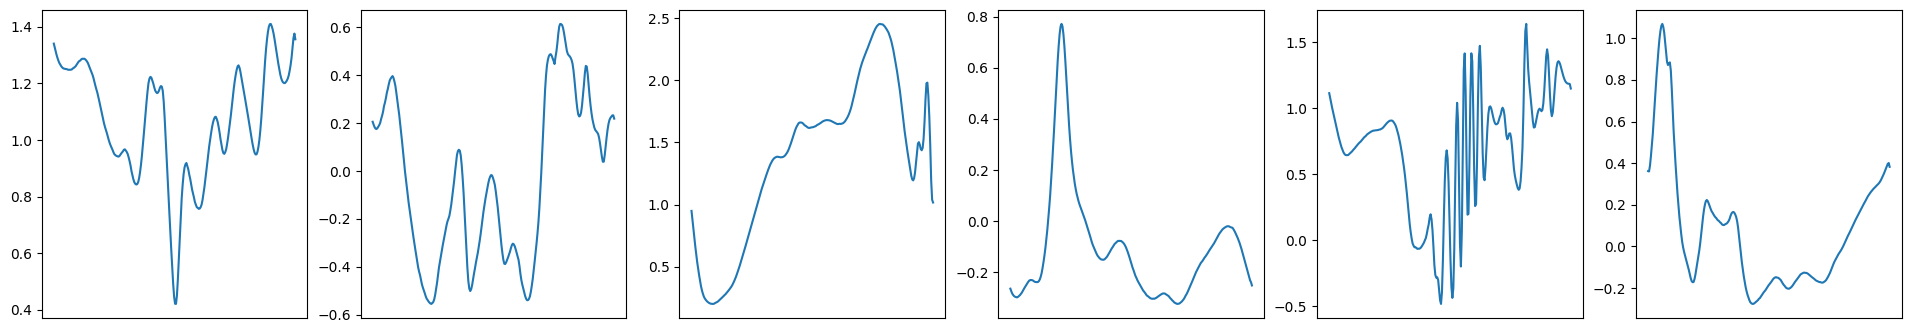

In [6]:
plot_time_series_row(x1, 6)


## Shared model/SDE parameters

In [12]:
B, channels, M = x1.shape
print(f'(B, C, T) = ({B}, {channels}, {M}).')

J = 8  
Q = 3

filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)

interpolant = 'Cos'
nt = 6000

# originally 50000
t = 1 - (1 - torch.linspace(0, 1, nt + 1))**2  # LINEAR SCHEDULE 
sigma = 1

nb_workers = x1.shape[0]
nb_interpolants = x1.shape[0]
batch_size = x1.shape[0] // 2
regularization = 1e-1

base_config = f'turbulence_synthesis_{M}_J_{J}_Q_{Q}_sigma_{sigma}'
print('base_config:', base_config)


(B, C, T) = (20000, 1, 256).
base_config: turbulence_synthesis_256_J_8_Q_3_sigma_1


## Run or load an experiment

Set `FORCE_RERUN = True` if you want to recompute samples even when saved results already exist.

The standard outputs are saved with your existing `save_results(...)`. In addition, this notebook saves a small auxiliary `.pt` file containing `barphi_e` and `barphi_p`, because these are useful for plotting moment matching after reloading.


In [13]:
FORCE_RERUN = False
SAVE_AUX_MOMENTS = True

def aux_path(config):
    return root.parent / f'{config}_aux_moments.pt'


def try_load_experiment(config):
    """Try loading saved SDE outputs and auxiliary moment-matching data."""
    try:
        loaded = load_results(root.parent, config)
        # Fixed: Correctly unpack the 5 values returned by load_results
        xt, theta_t, dH_t_bound, t_loaded, Theta_reg = loaded
        
        out = {
            'xt': xt.to(device) if torch.is_tensor(xt) else xt,
            'theta_t': theta_t,
            'dH_t_bound': dH_t_bound,
            't': t_loaded.to(device) if torch.is_tensor(t_loaded) else t_loaded,
            'Theta_reg': Theta_reg,
            'loaded': True,
        }
        ap = aux_path(config)
        if ap.exists():
            aux = torch.load(ap, map_location=device)
            out.update(aux)
        else:
            out['barphi_e'] = None
            out['barphi_p'] = None
        return out
    except Exception as e:
        print(f'Could not load {config}: {e}')
        return None


def run_experiment(exp, force_rerun=False, lam=1.0, t=None, n_subsample=100):
    config = exp['config']
    terms = exp['terms']

    if not force_rerun:
        loaded = try_load_experiment(config)
        if loaded is not None:
            print(f'Loaded existing results for {config}')
            return loaded

    print(f'Running experiment: {config}')
    print('terms:', terms)

    potentials = get_1d_potentials(
        terms,
        J,
        filters,
        Q,
        filters_Q,
        filters_Phi,
        scalar_param=None,
        parallel=False,
    )

    Solver = SDE(
        x1,
        nb_workers,
        nb_interpolants,
        t,
        sigma,
        potentials,
        batch_size,
        device=device,
        regularization=regularization,
        interpolant=interpolant,
    )

    xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound, Theta_reg = Solver.forward_regularised(lam=lam,n_subsample=n_subsample) 
    # xt, barphi_e, barphi_p, eta_t, theta_t, dH_t_bound = Solver()

    # --- save ---
    save_results_theta_reg(
        xt,
        theta_t,
        dH_t_bound,
        t,
        root.parent,
        config,
        Theta_reg=Theta_reg, # Removed the duplicate t=None here
    )

    if SAVE_AUX_MOMENTS:
        torch.save(
            {
                'barphi_e': barphi_e.detach().cpu(),
                'barphi_p': barphi_p.detach().cpu(),
            },
            aux_path(config),
        )

    return {
        'xt': xt,
        'theta_t': theta_t,
        'Theta_reg': Theta_reg,
        't': t,
        'dH_t_bound': dH_t_bound,
        'barphi_e': barphi_e,
        'barphi_p': barphi_p,
        'loaded': False,
    }


## Define and run experiments 

In [16]:
results = {}

n_subsample = 100
lam = 5e-8

experiments = {
    'coshgt_psi': {
        'label': 'CoshGt ψ',
        'suffix': f'_nt{nt}_n1_{x1.shape[0]}_2GG+PL_lam_{lam}',
        'terms': [
            'L_2_lowpass',
            'Scattering_Fourth_Order_Mod2_Real_Q1',
            'Scalar_psi_',
            'Scalar_morlet_windows',
        ],
    },

}

for key, exp in experiments.items():
    exp['config'] = base_config + exp['suffix']
    print(key, '->', exp['config'])


coshgt_psi -> turbulence_synthesis_256_J_8_Q_3_sigma_1_nt6000_n1_20000_2GG+PL_lam_5e-08


In [17]:
for key, exp in experiments.items():
    results[key] = run_experiment(exp, force_rerun=FORCE_RERUN, lam=lam, t=t, n_subsample=n_subsample)
    print('-' * 80)

Could not load turbulence_synthesis_256_J_8_Q_3_sigma_1_nt6000_n1_20000_2GG+PL_lam_5e-08: [Errno 2] No such file or directory: '/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/saved_results/samples/turbulence_synthesis_256_J_8_Q_3_sigma_1_nt6000_n1_20000_2GG+PL_lam_5e-08'
Running experiment: turbulence_synthesis_256_J_8_Q_3_sigma_1_nt6000_n1_20000_2GG+PL_lam_5e-08
terms: ['L_2_lowpass', 'Scattering_Fourth_Order_Mod2_Real_Q1', 'Scalar_psi_', 'Scalar_morlet_windows']
Signal detected as 1D: (B, C, T) = (10000, 1, 256).
The model has 112 potentials.
[GGD/GGD/Pow][ch 0]  c1=0.0009(E[|x|])  c2=0.0089(99pct) | N_bulk=3920093(76.56%)  N_mid=1148706(22.44%)  N_tail=51201(1.00%)
True
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
[1.49999998e+00 5.77021530e-04]
-25269795.50430733
True
CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
[2.00000000e-01 1.82039115e-08]
-5750240.4194009155
[GGD/GGD/Pow][ch 0]  bulk(alpha=1.500, scale=0.0006) | mid(alpha=0.200, scale=0

6000it [1:25:05,  1.18it/s]


--------------------------------------------------------------------------------


## Analyze results 

In [18]:
for key, exp in experiments.items():
    res = results[key]
    theta_t = res['theta_t']
    theta_reg_t = res['Theta_reg']

In [19]:
theta_reg_t

tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], device='cuda:0')

5999 58


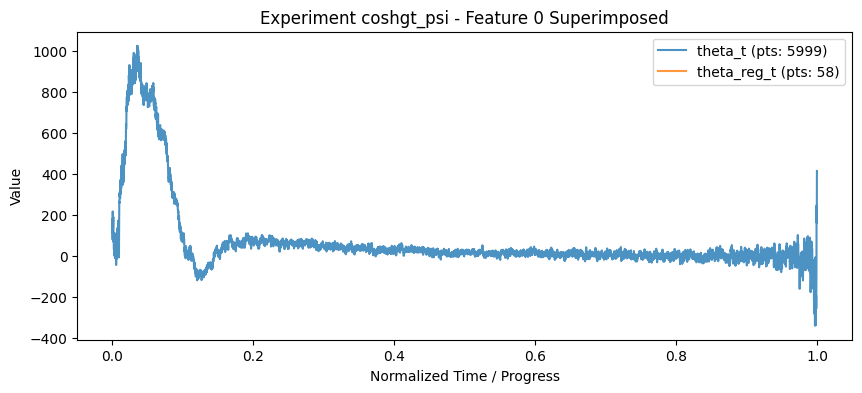

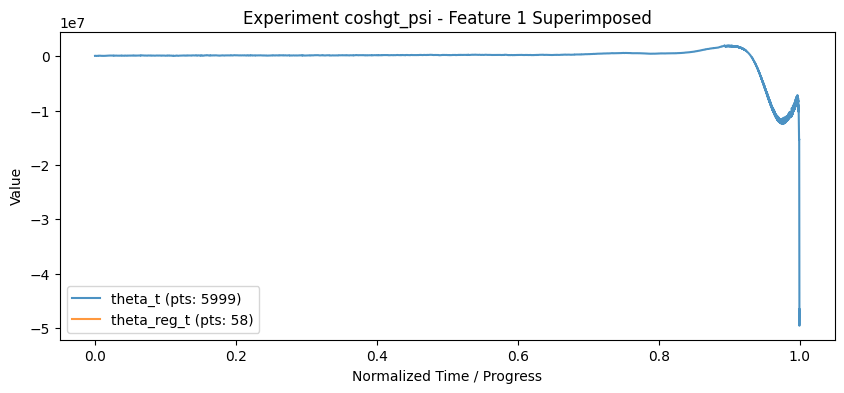

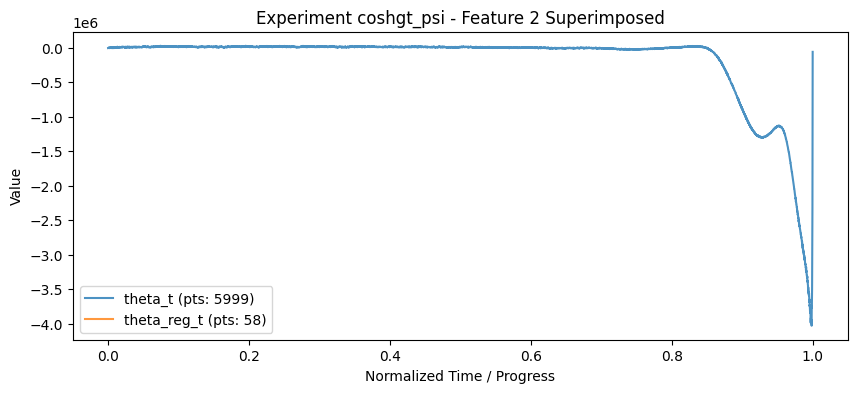

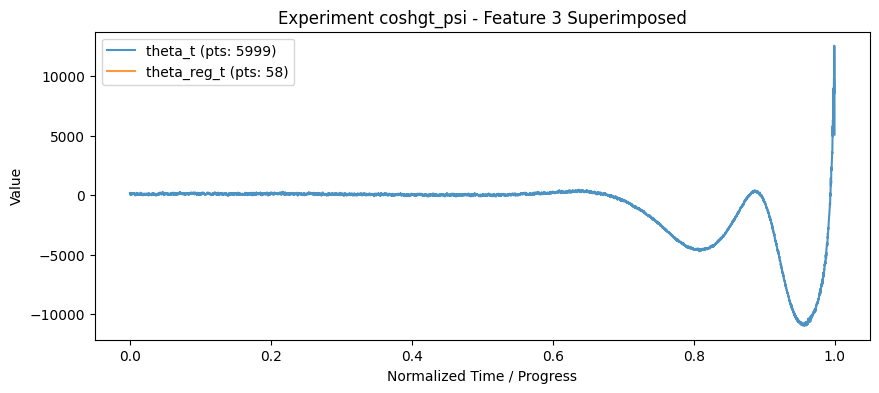

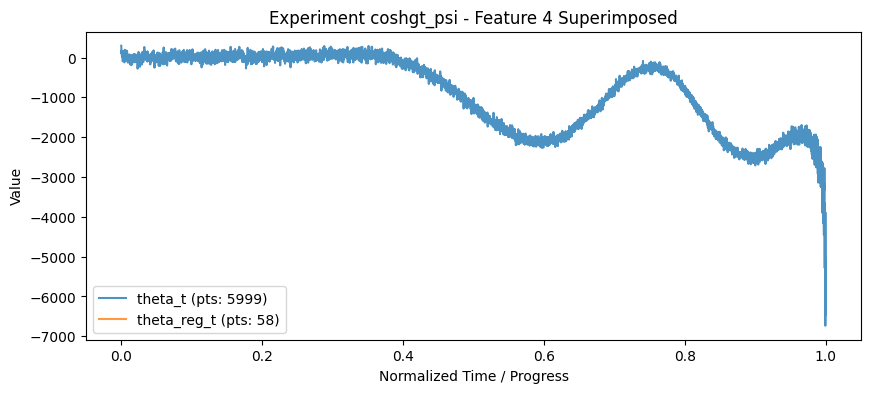

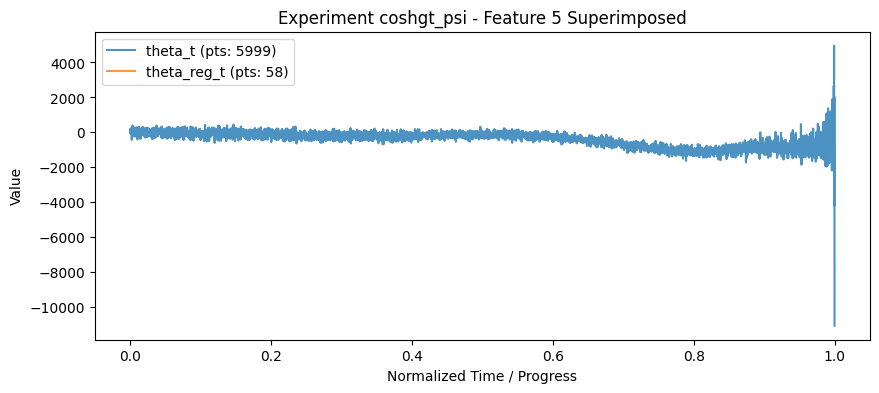

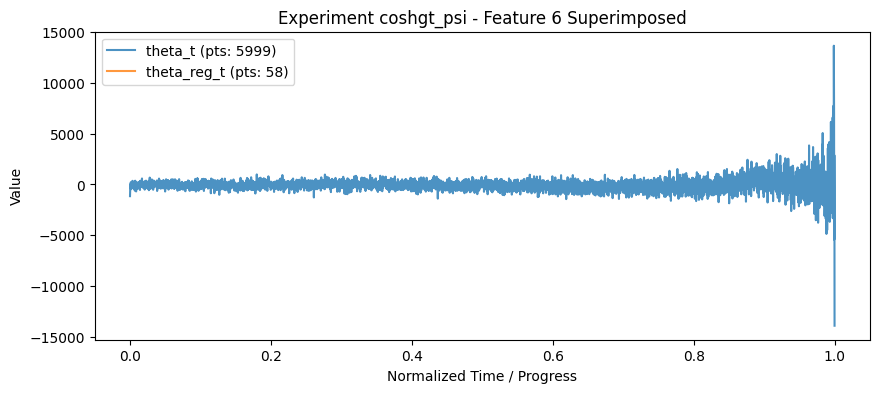

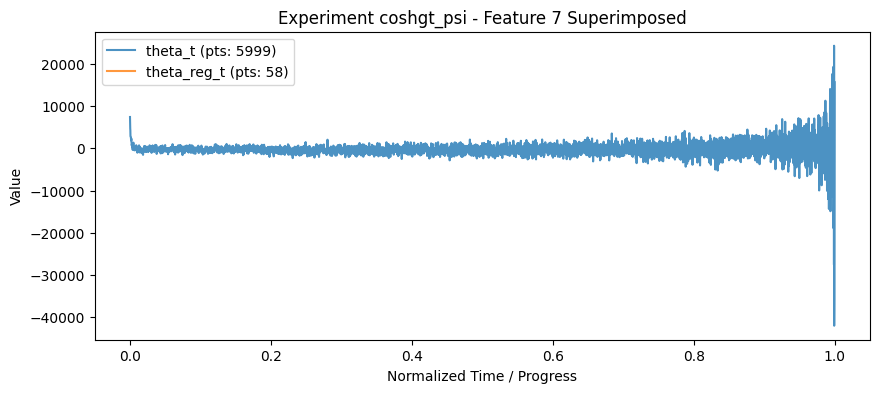

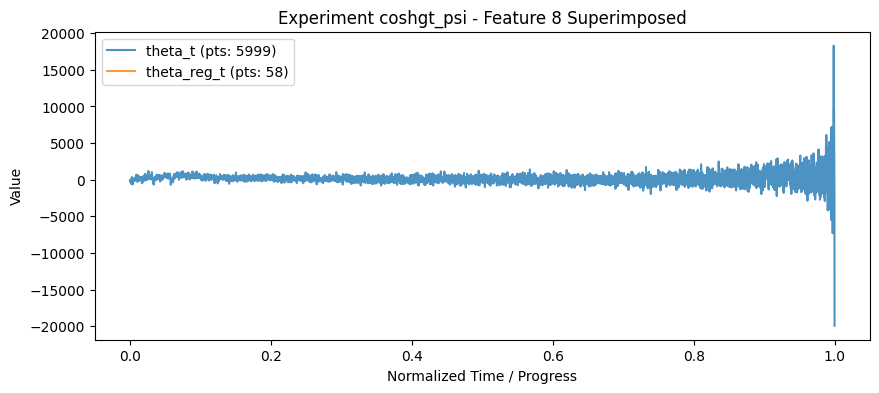

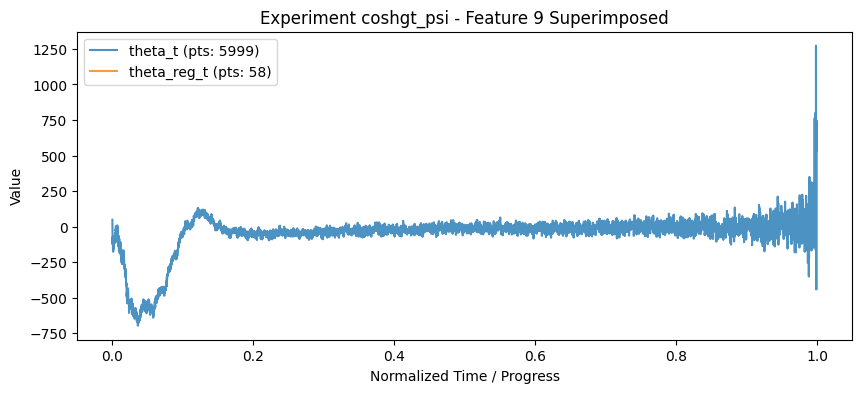

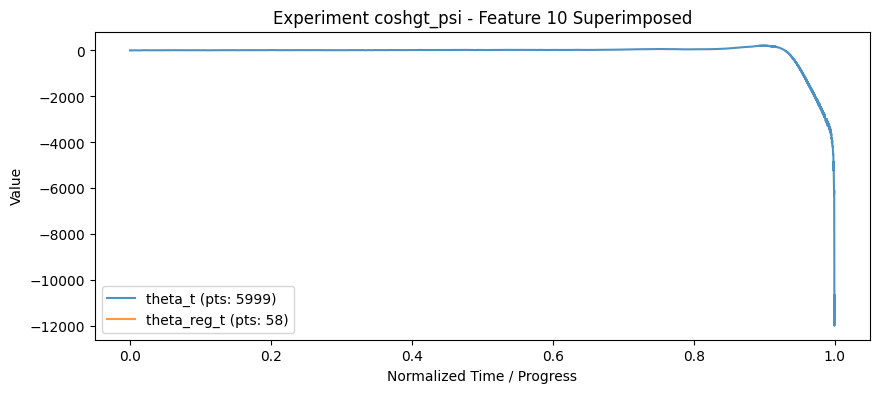

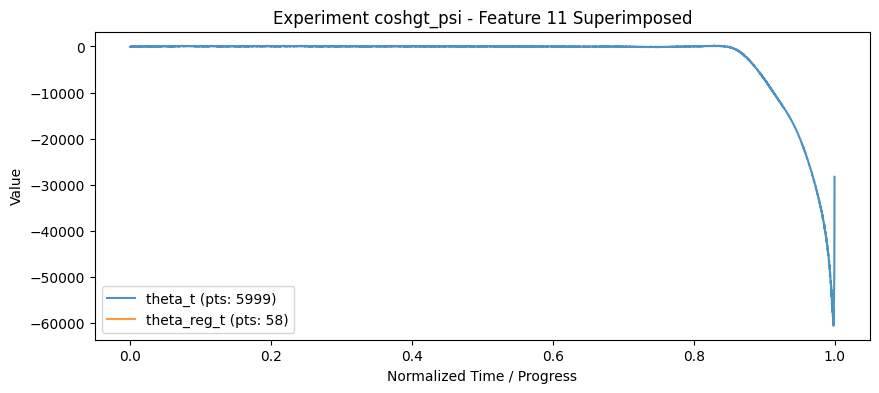

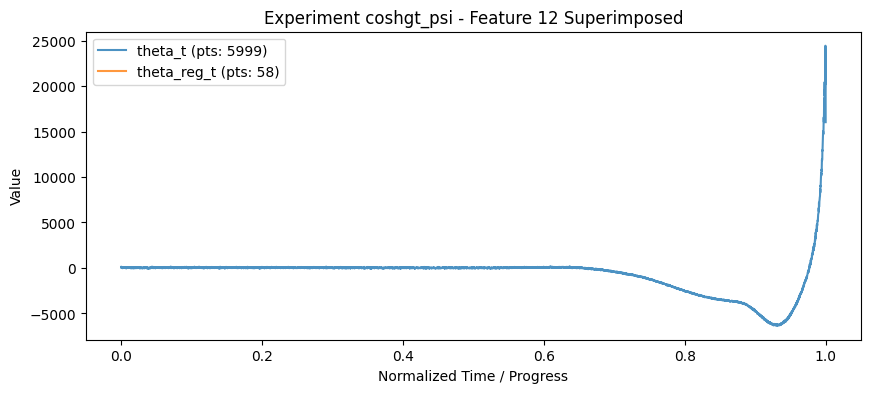

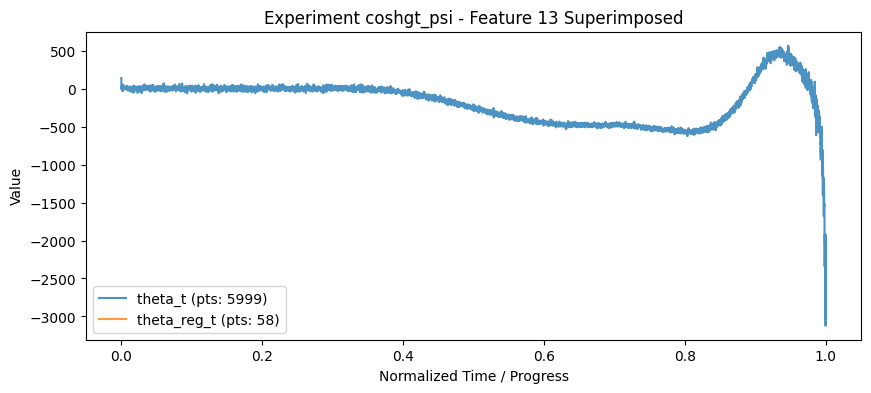

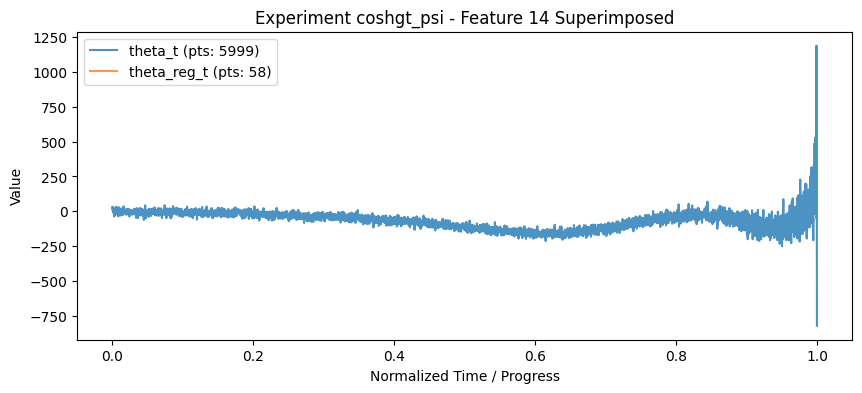

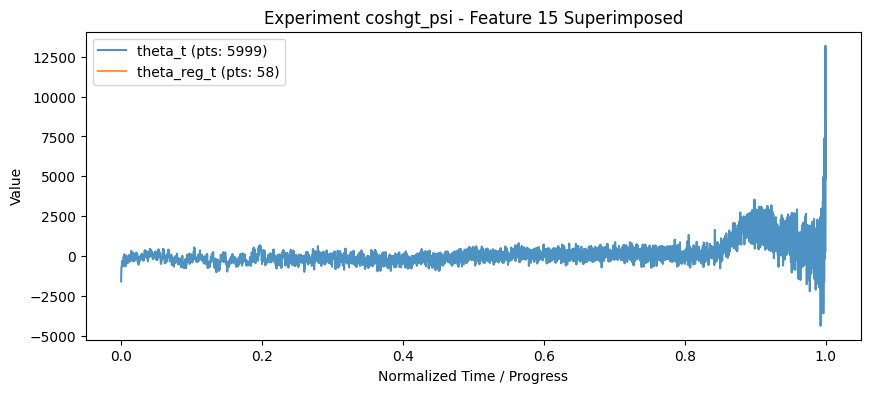

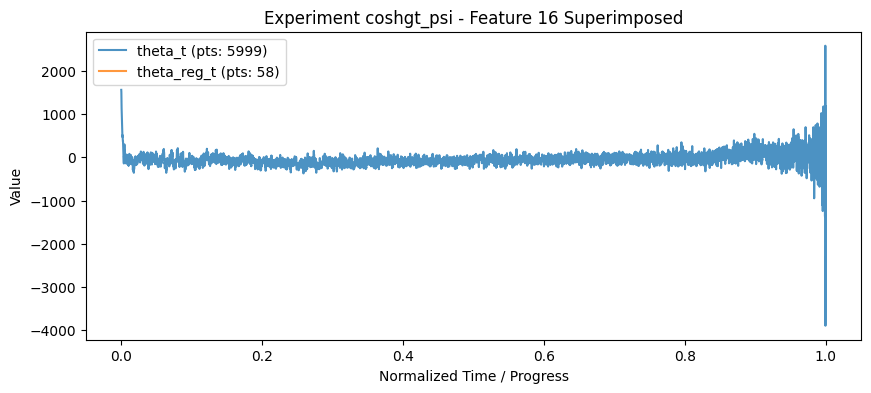

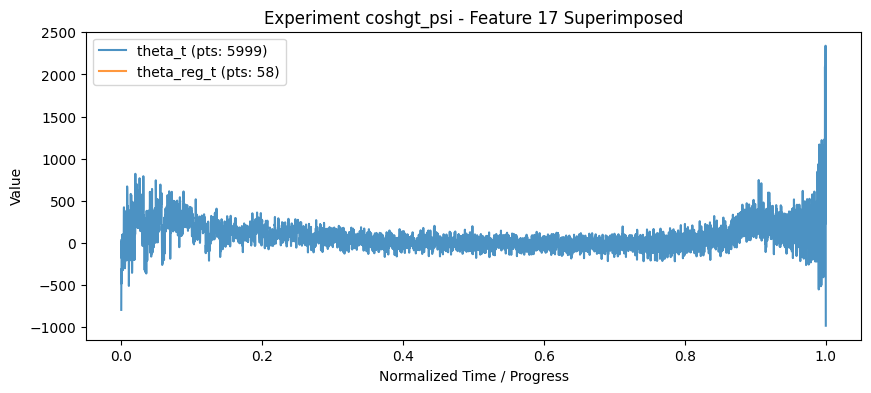

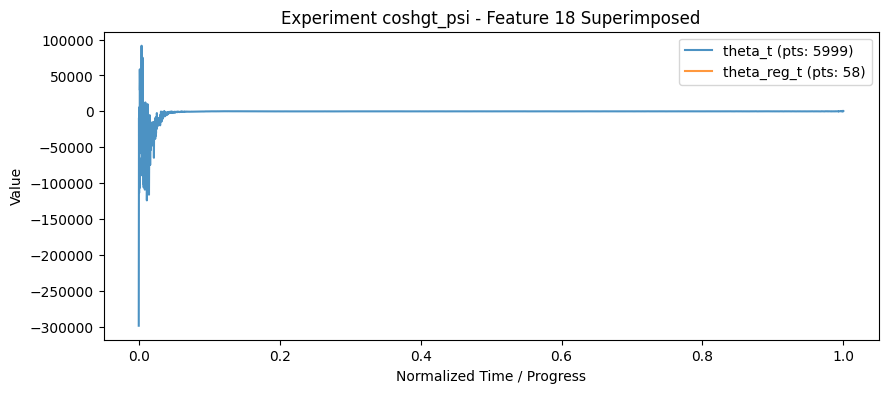

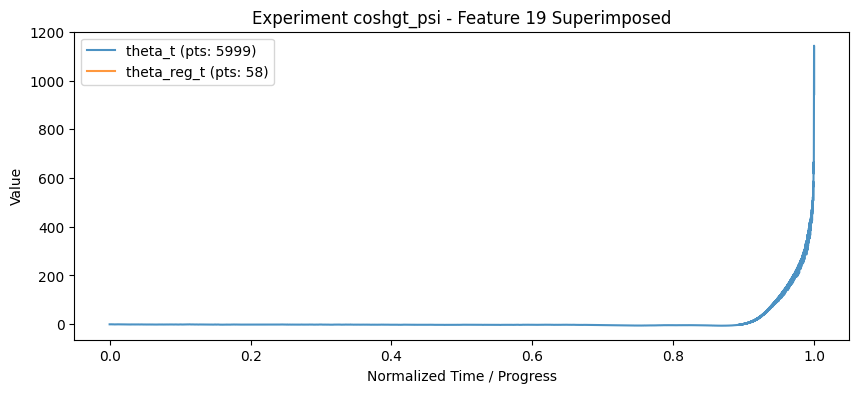

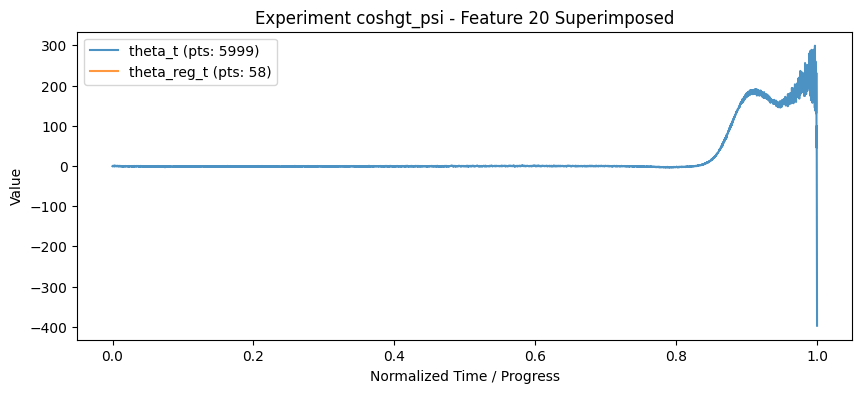

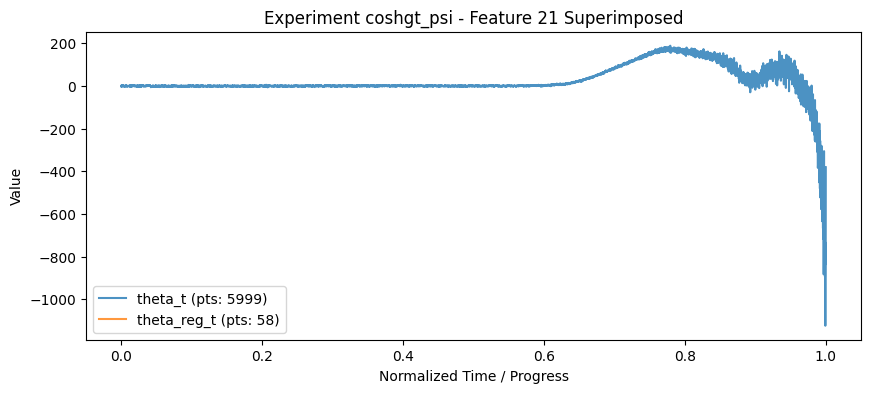

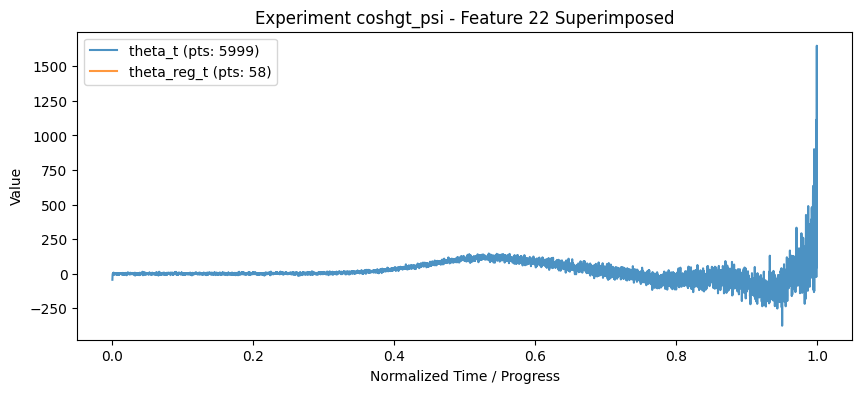

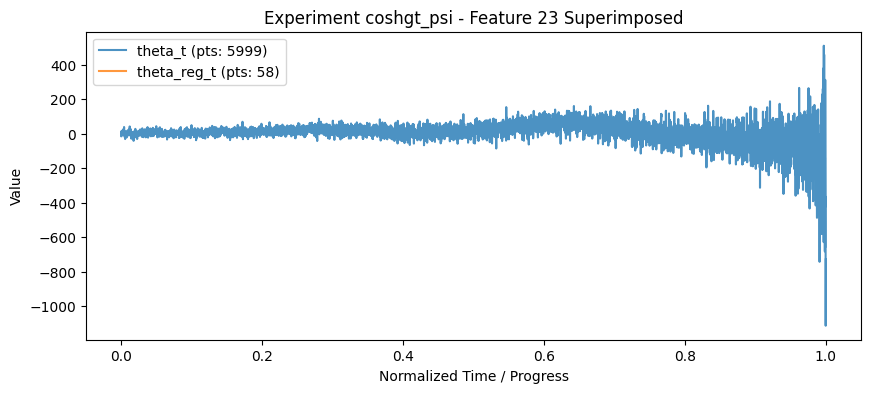

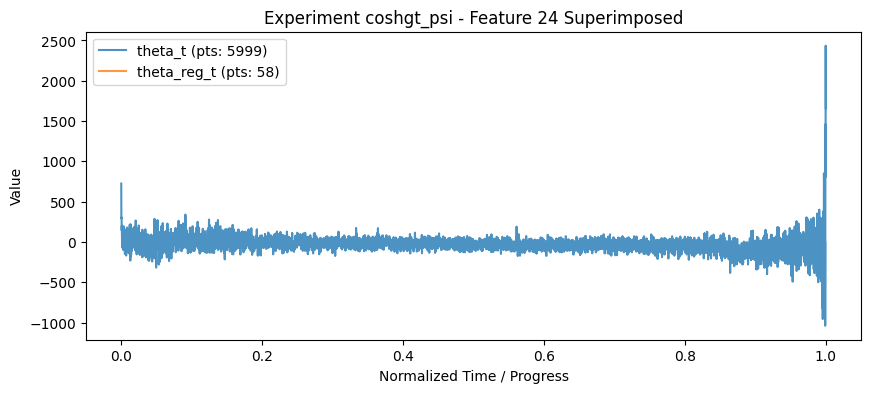

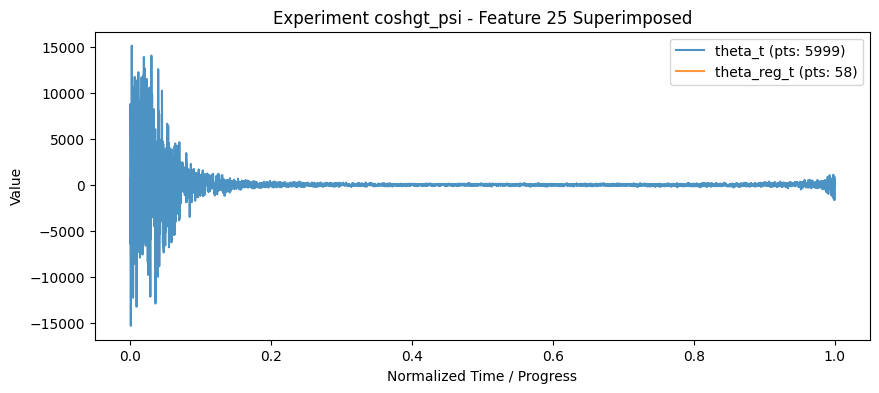

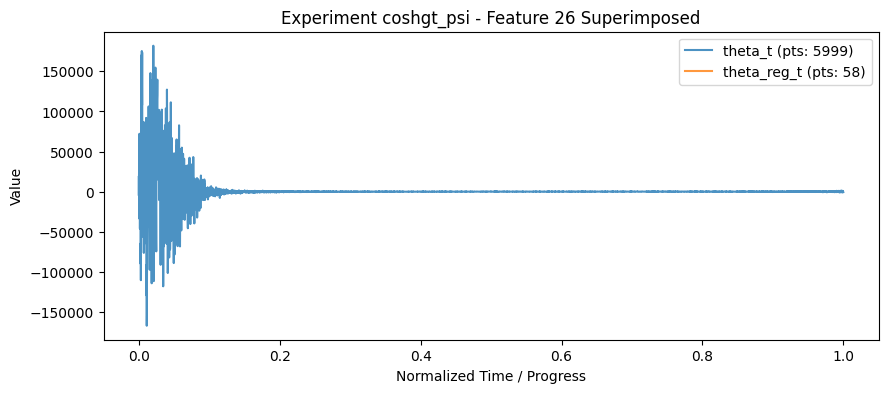

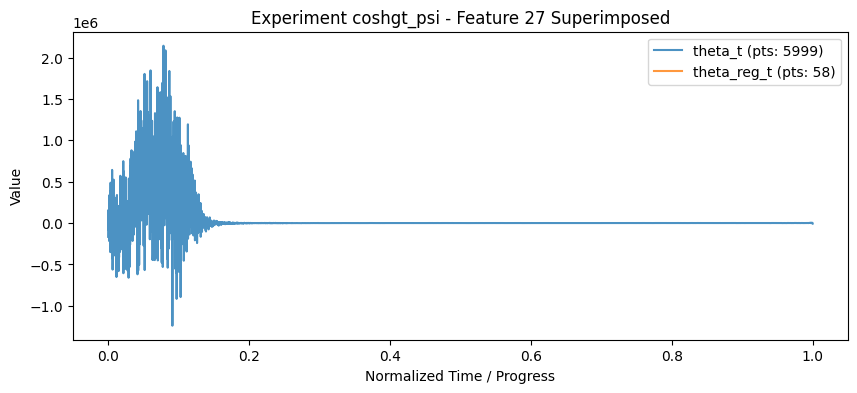

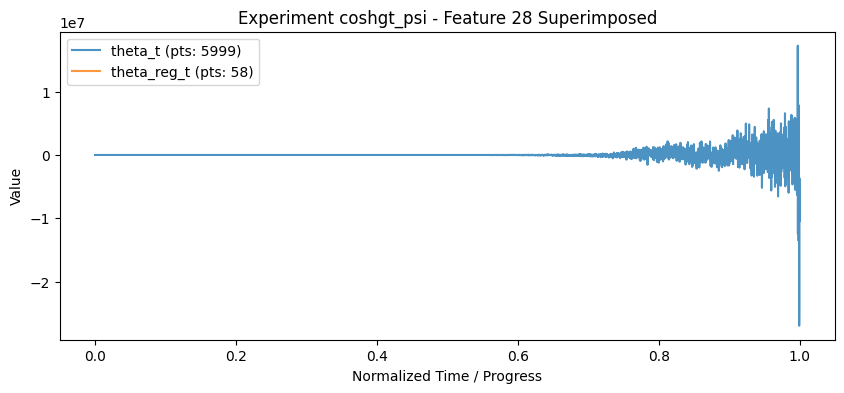

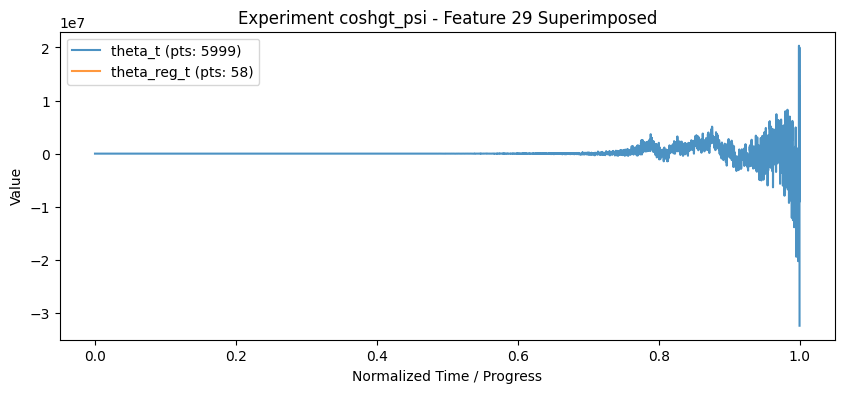

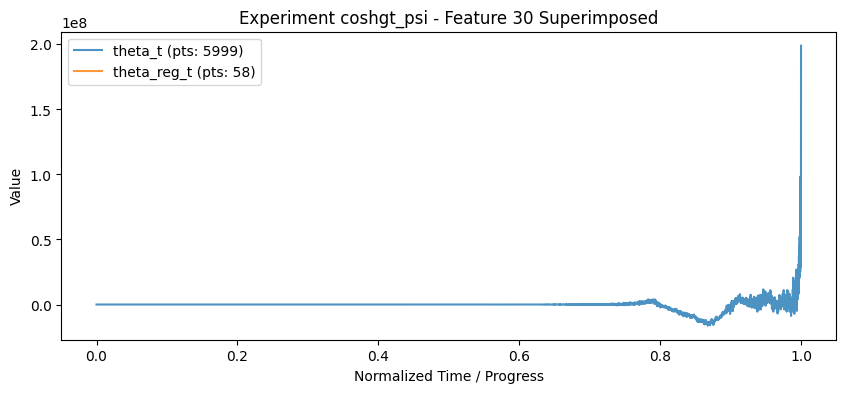

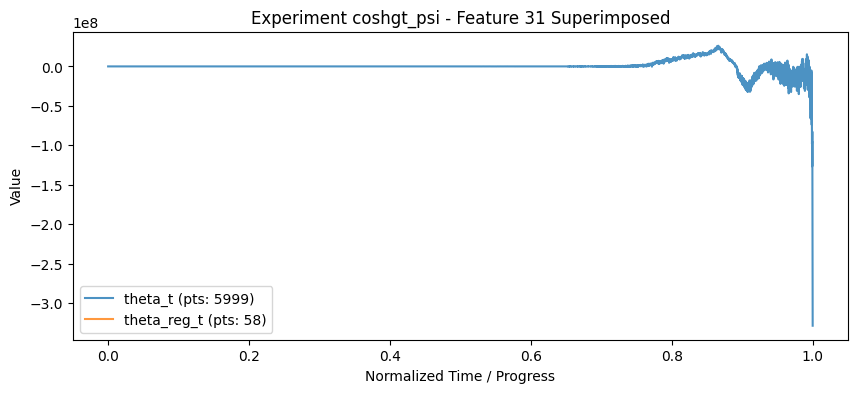

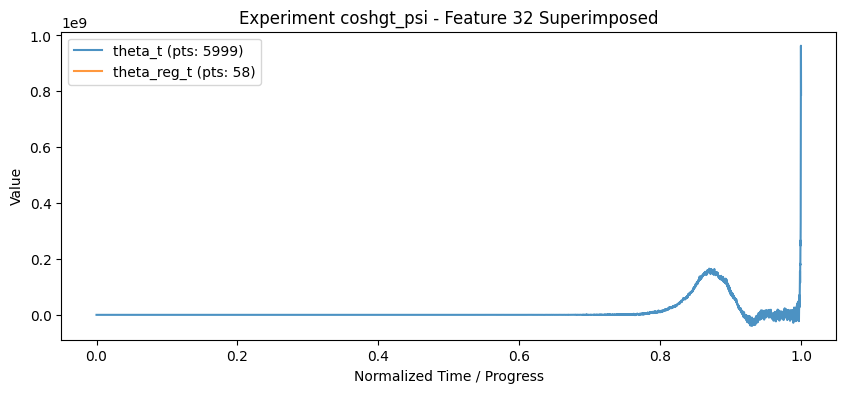

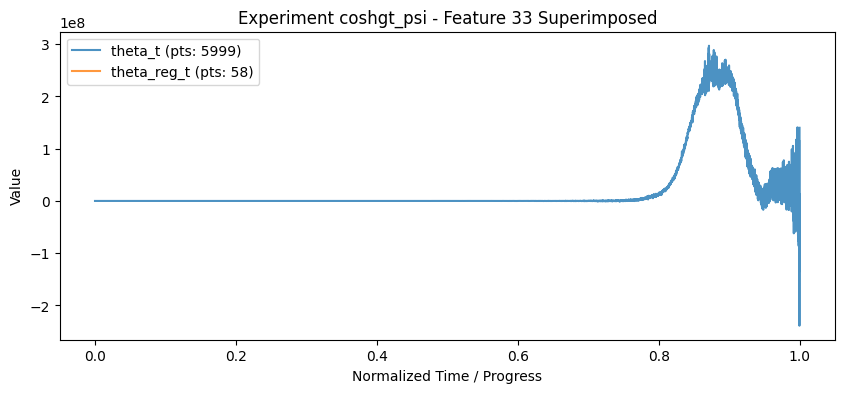

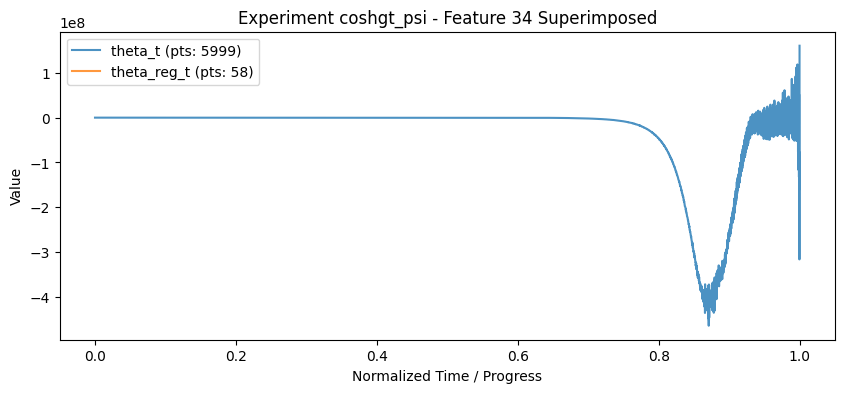

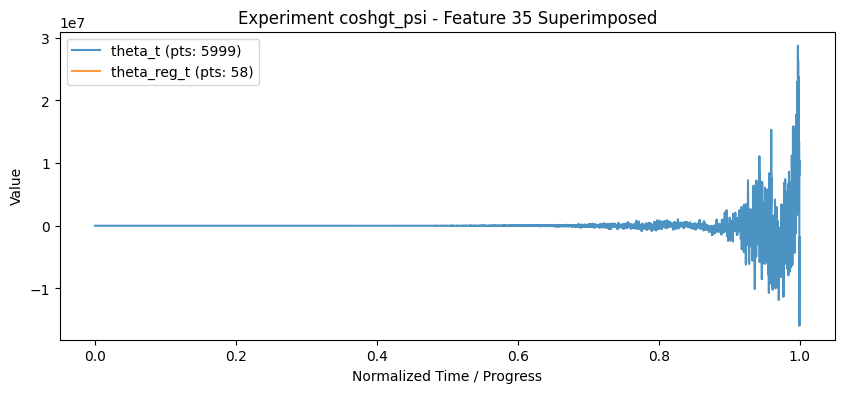

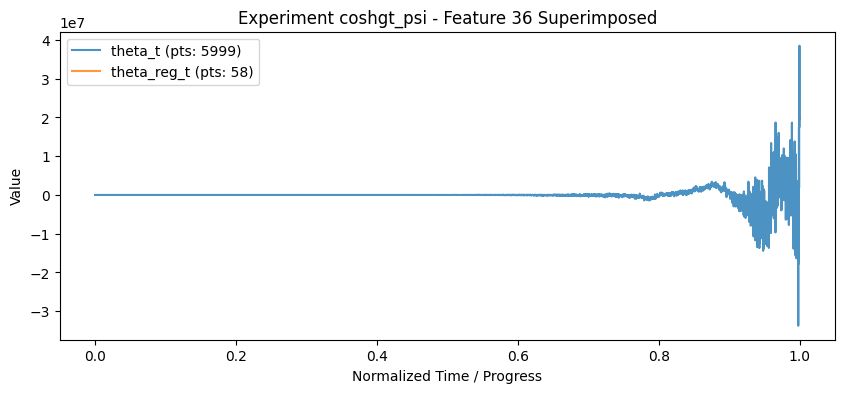

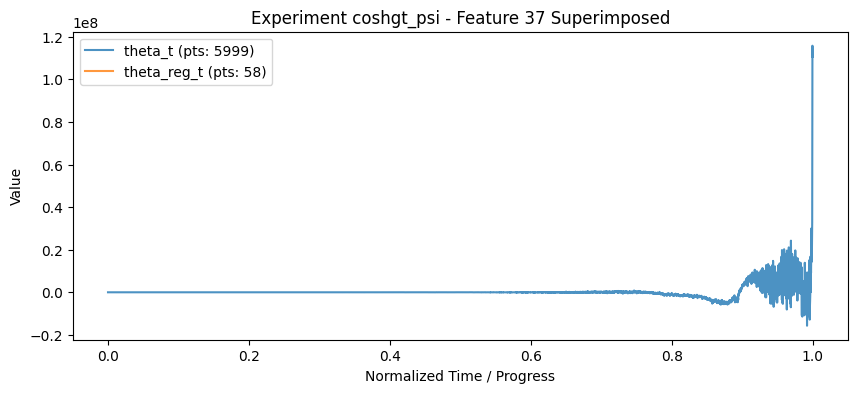

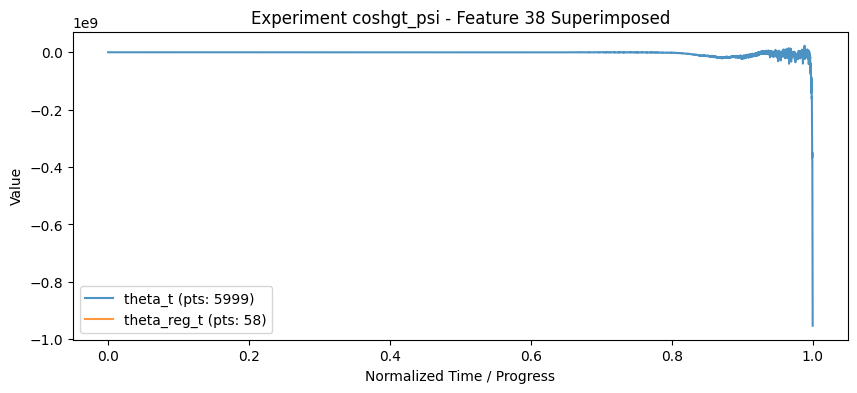

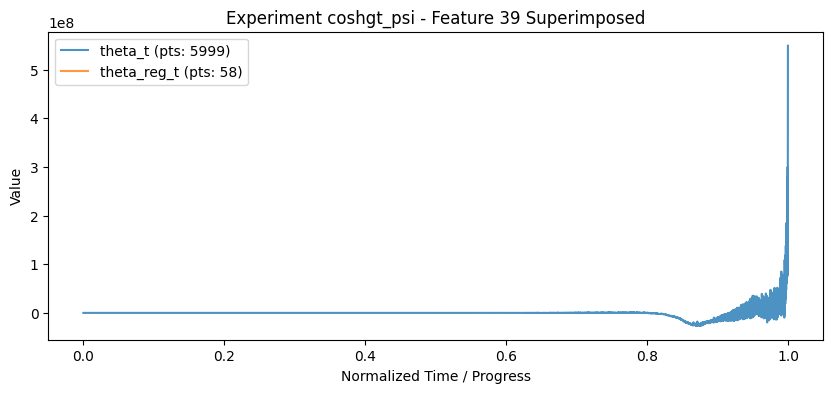

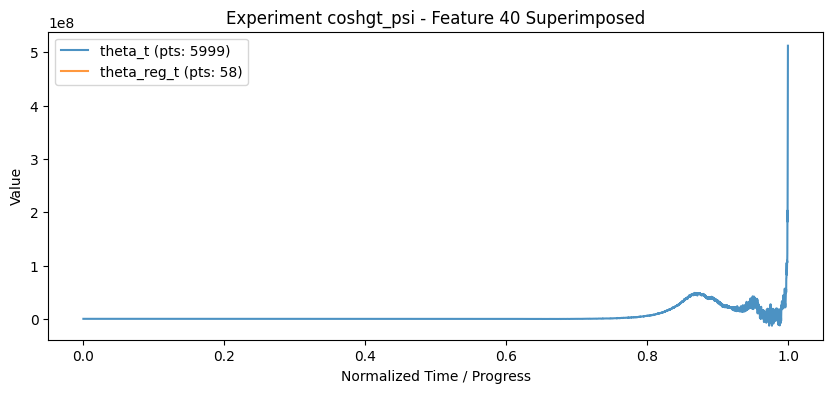

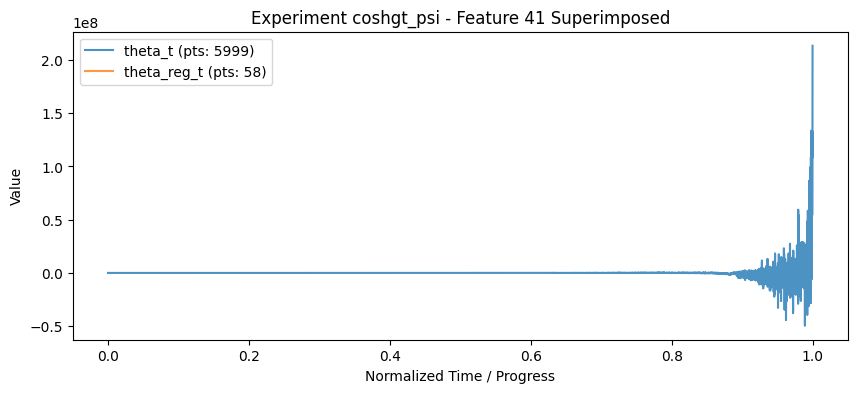

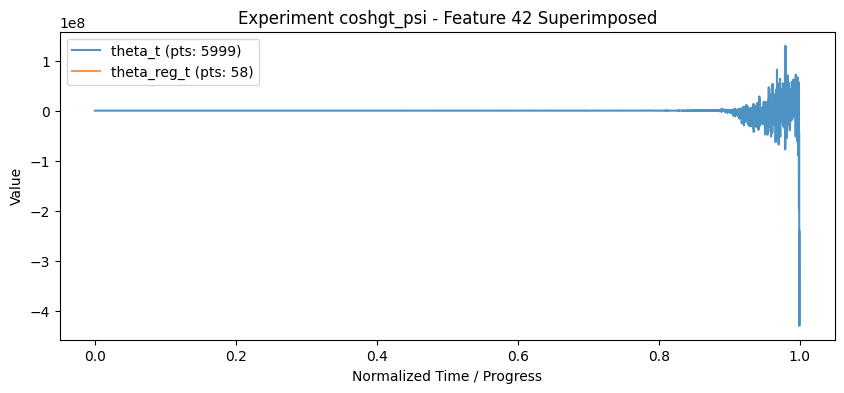

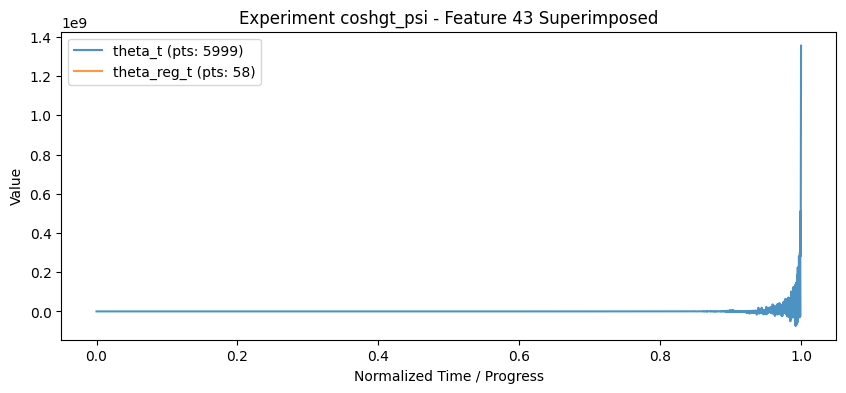

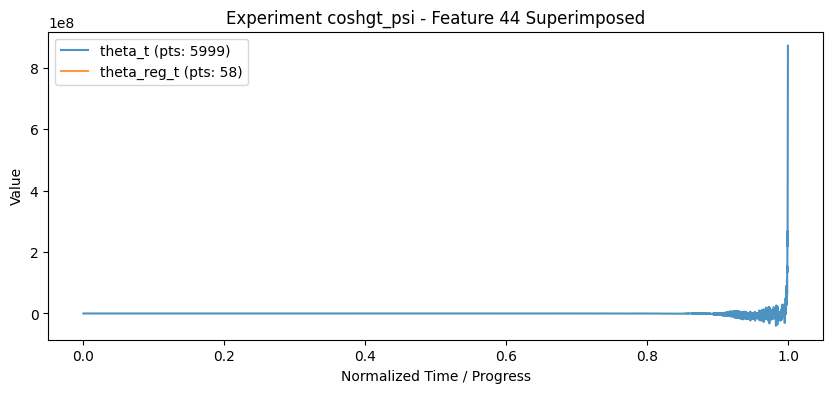

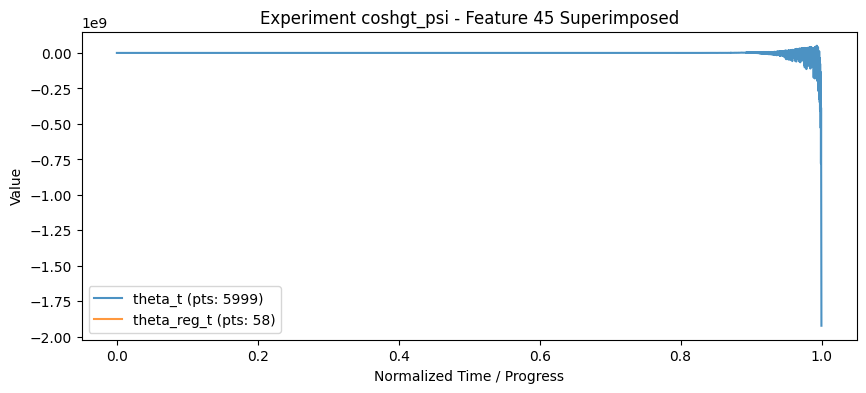

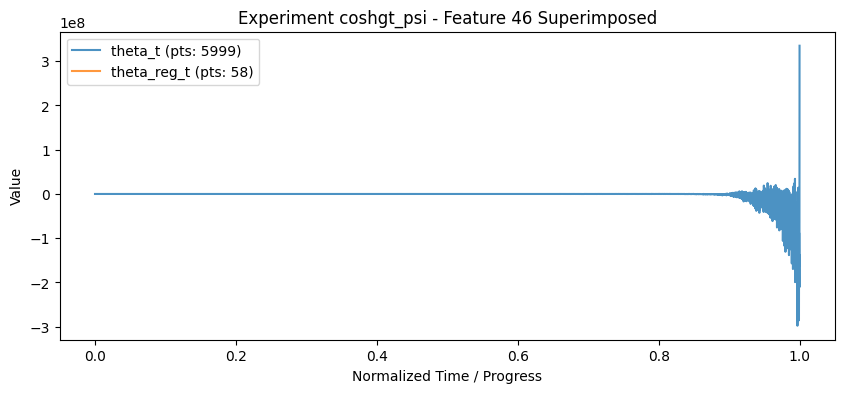

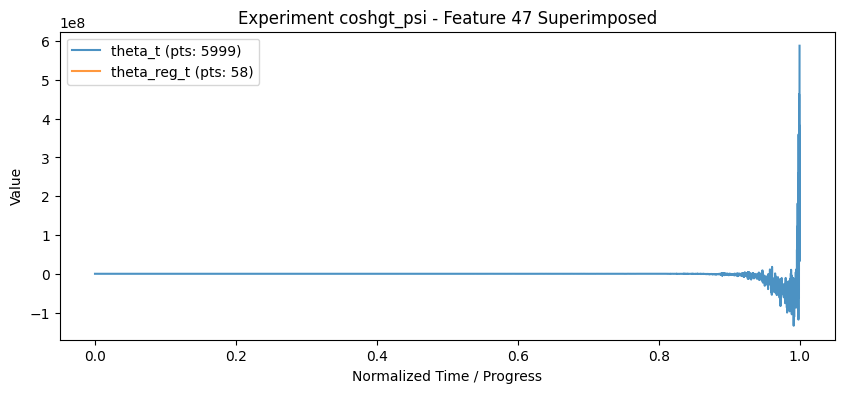

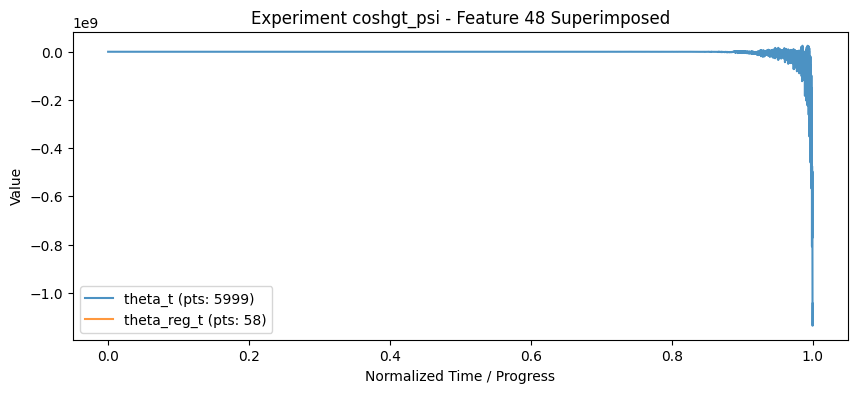

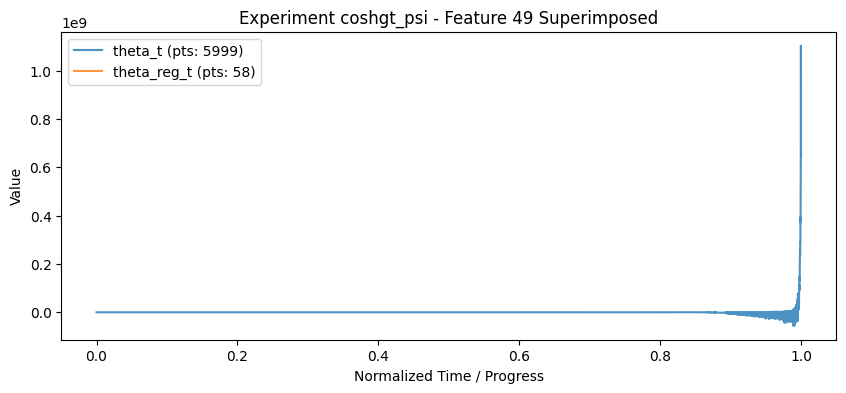

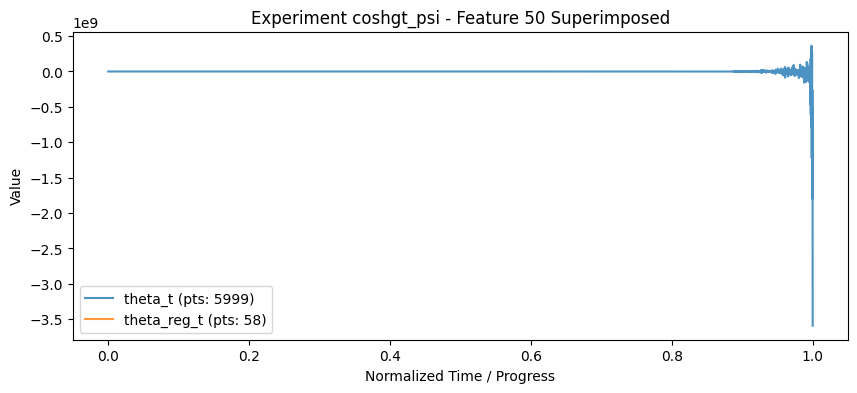

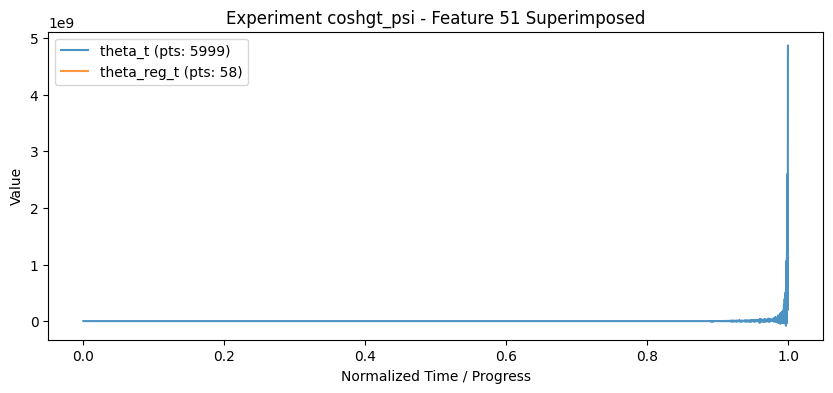

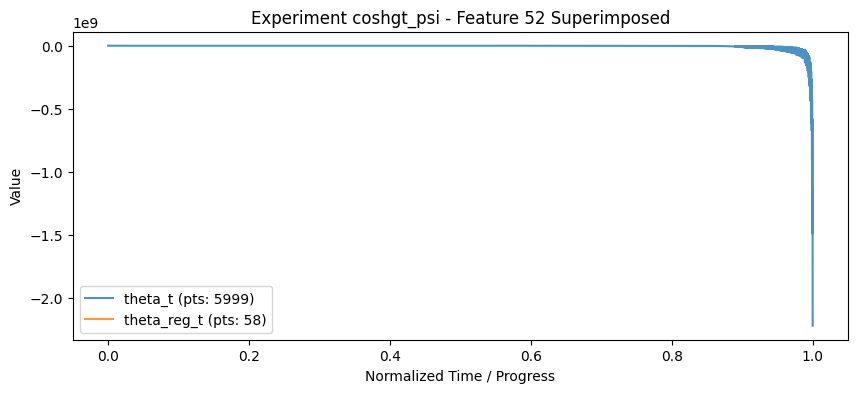

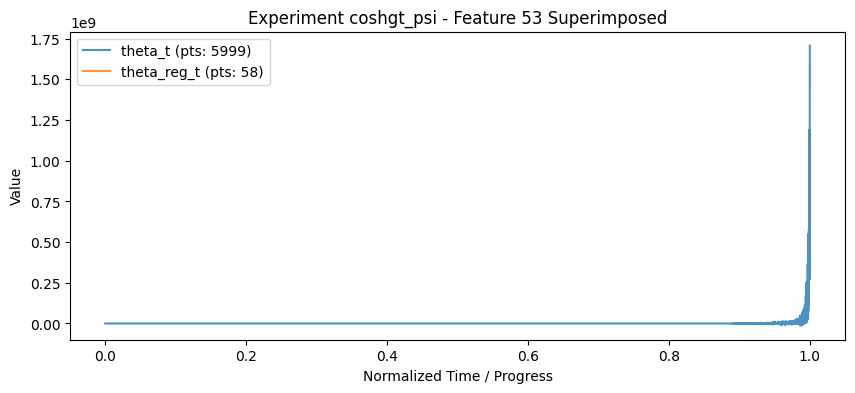

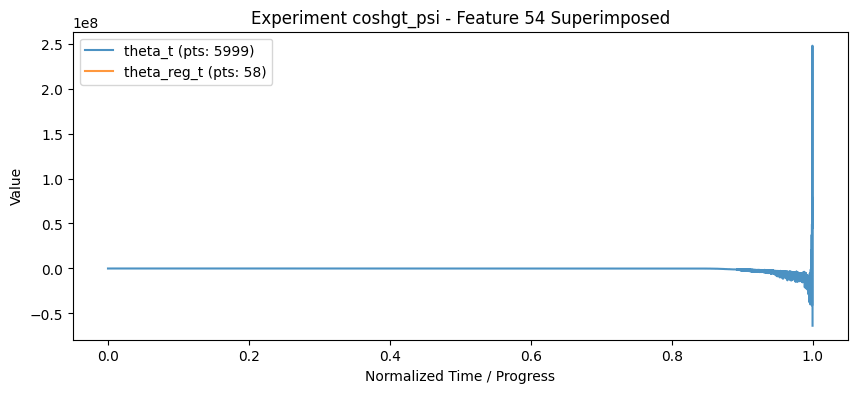

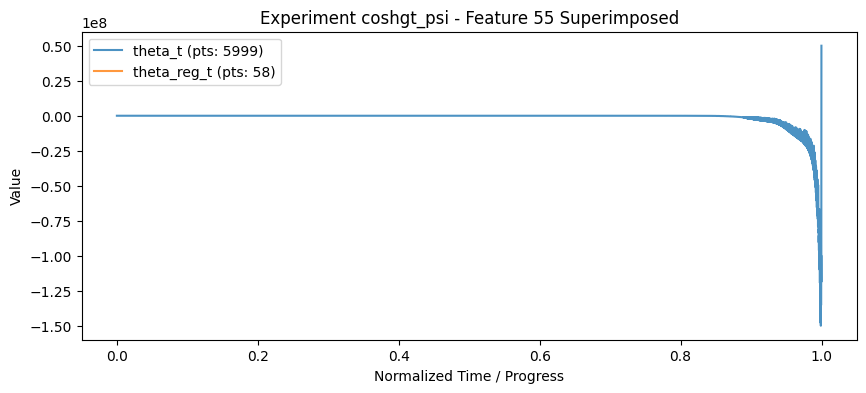

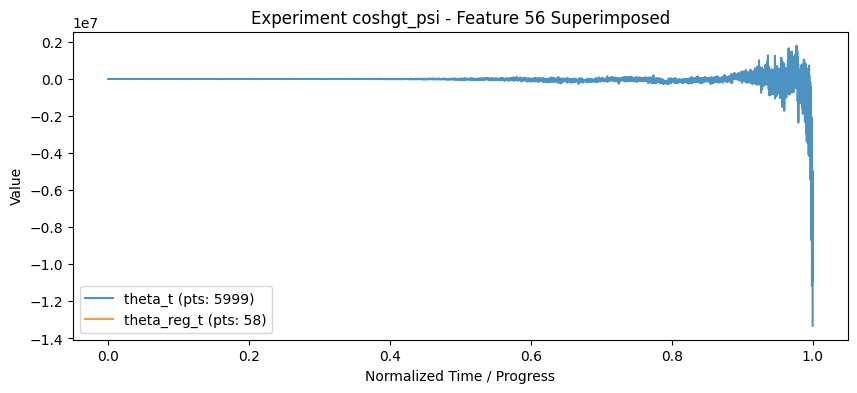

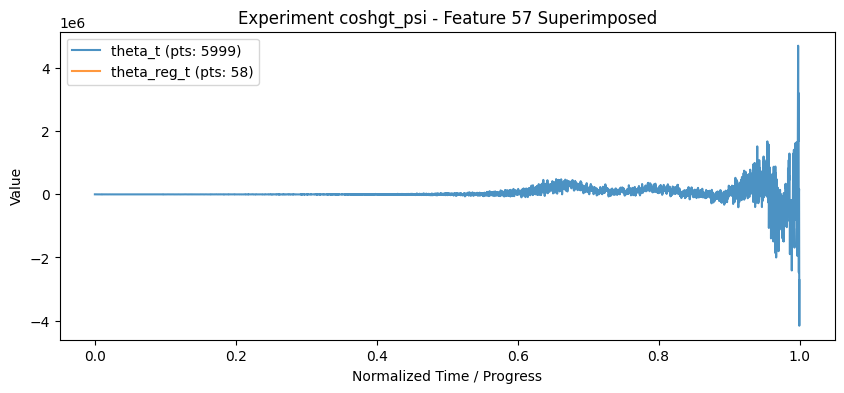

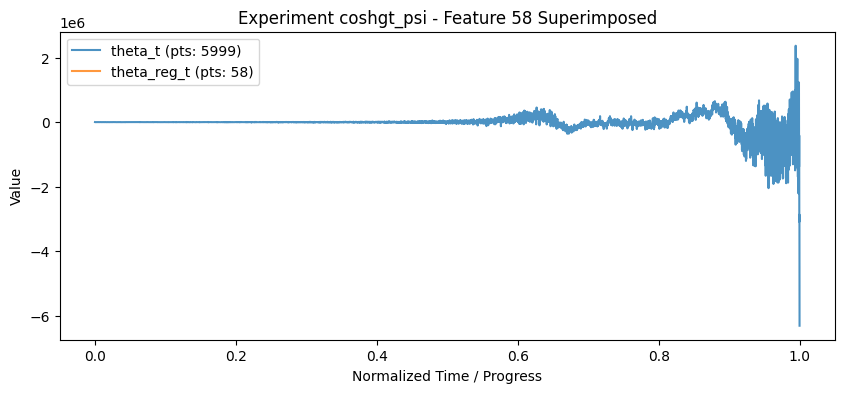

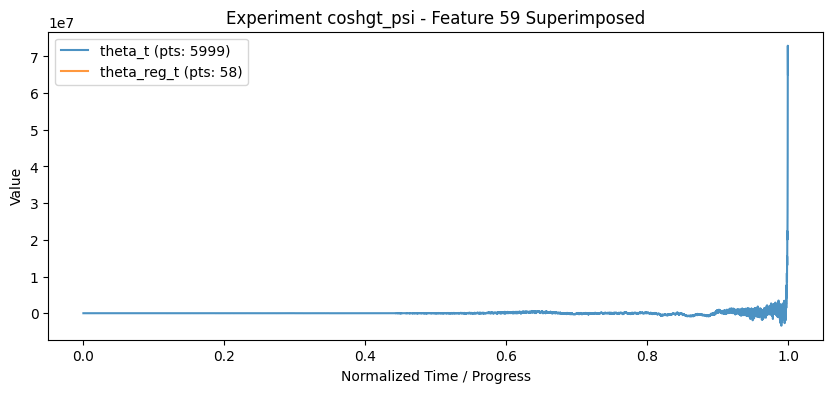

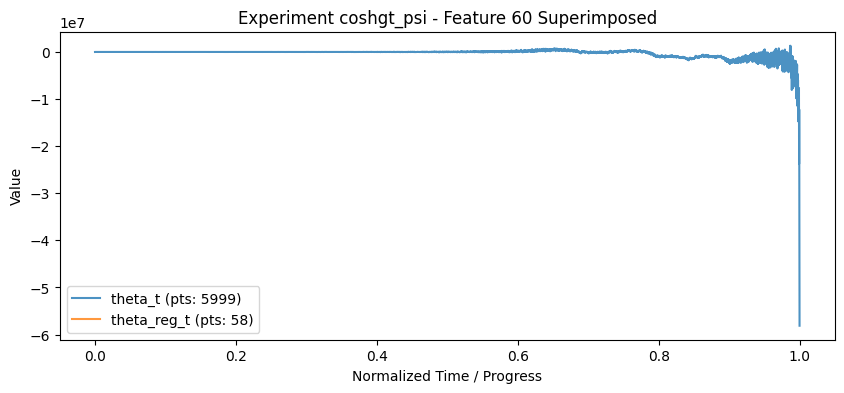

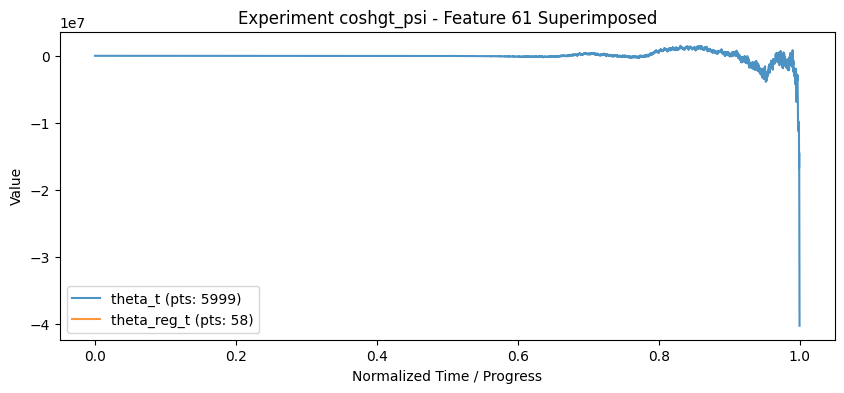

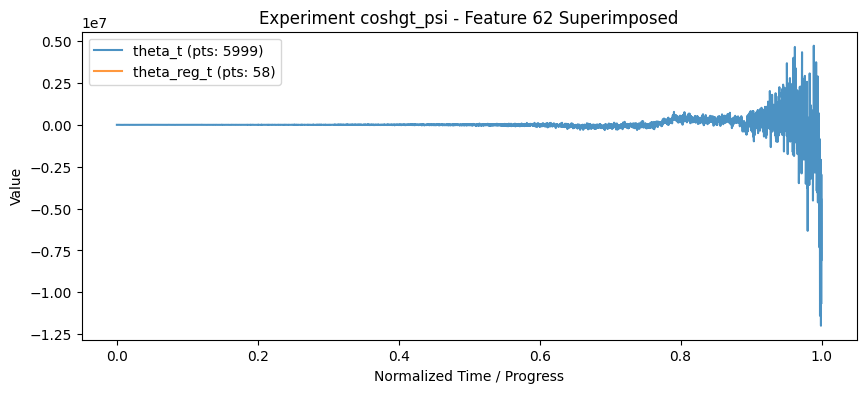

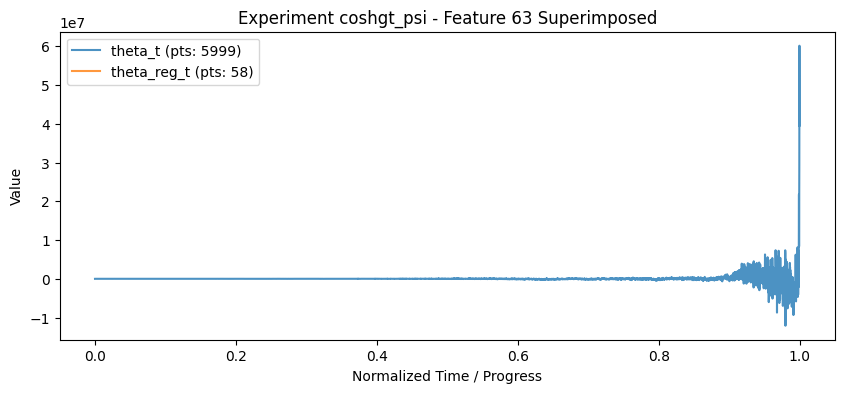

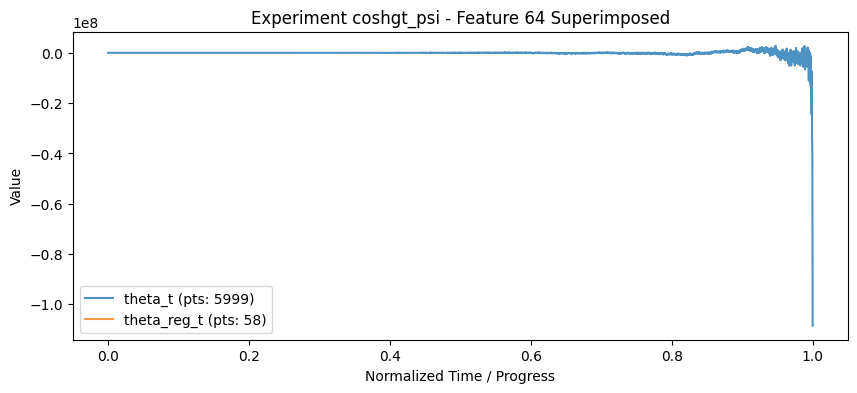

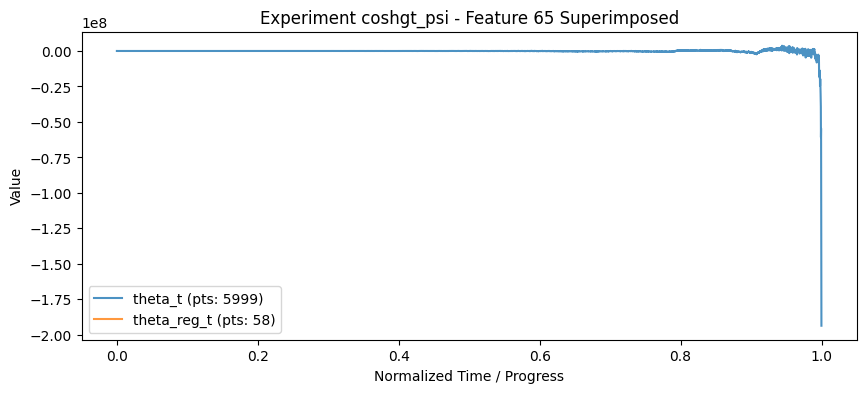

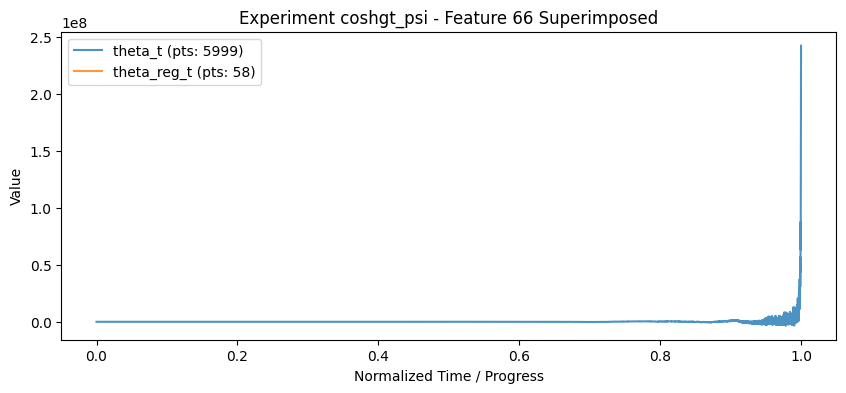

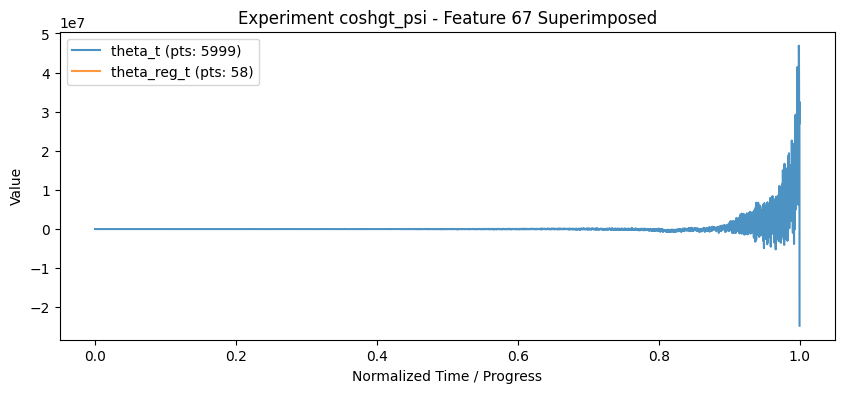

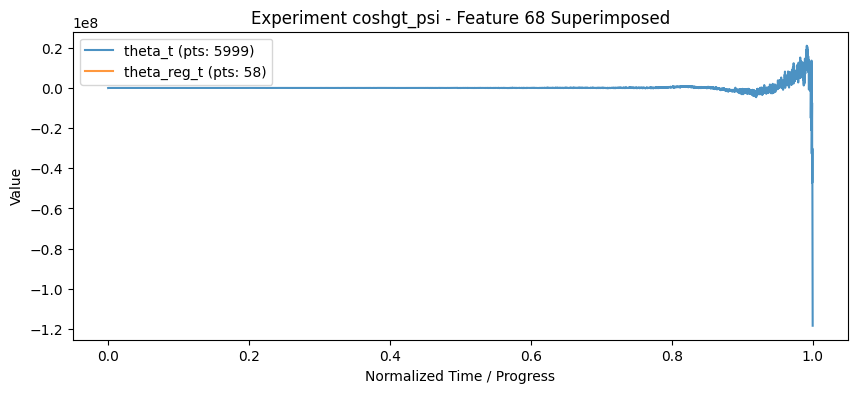

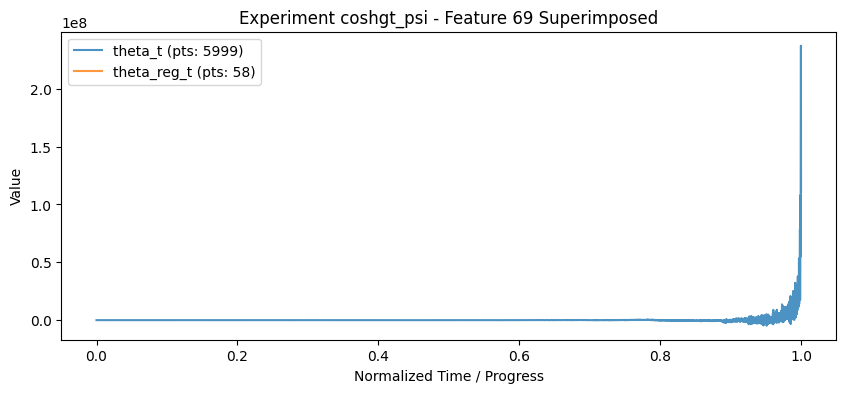

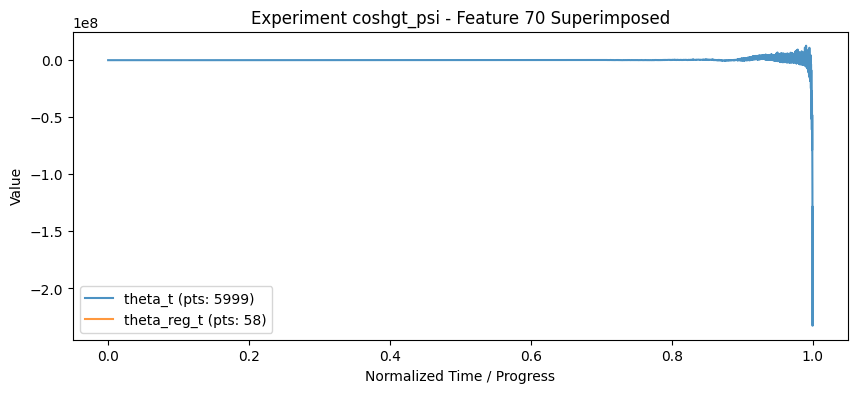

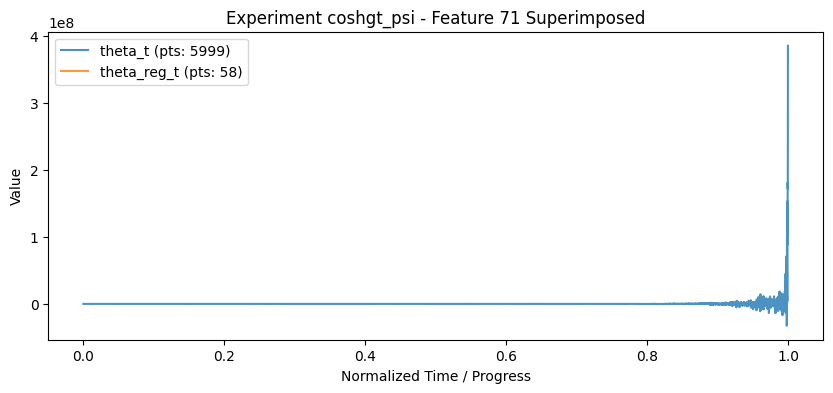

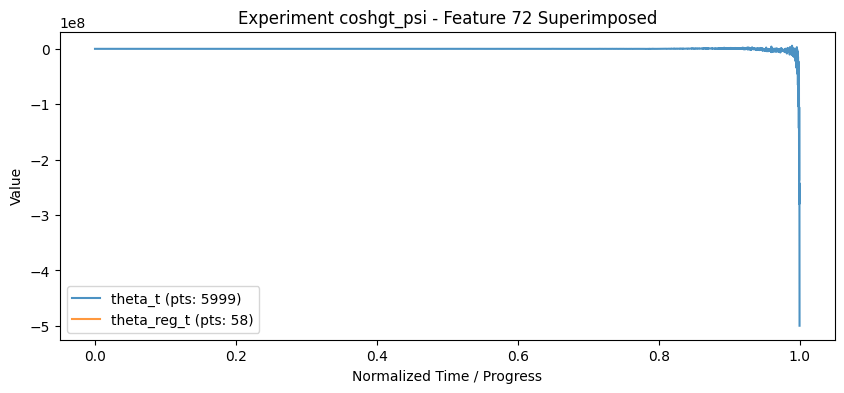

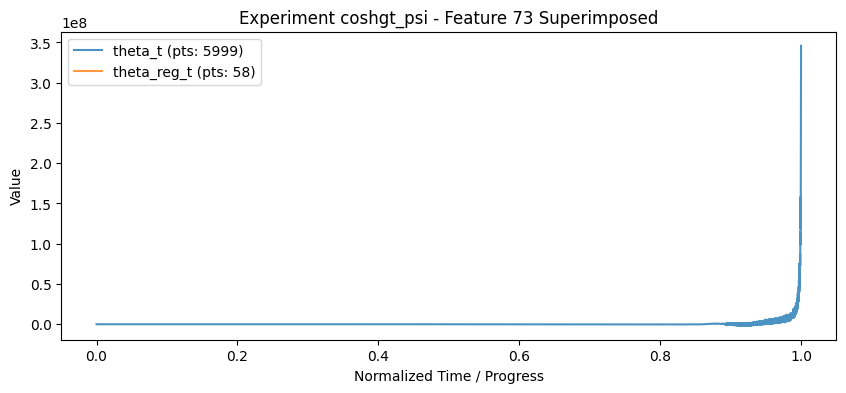

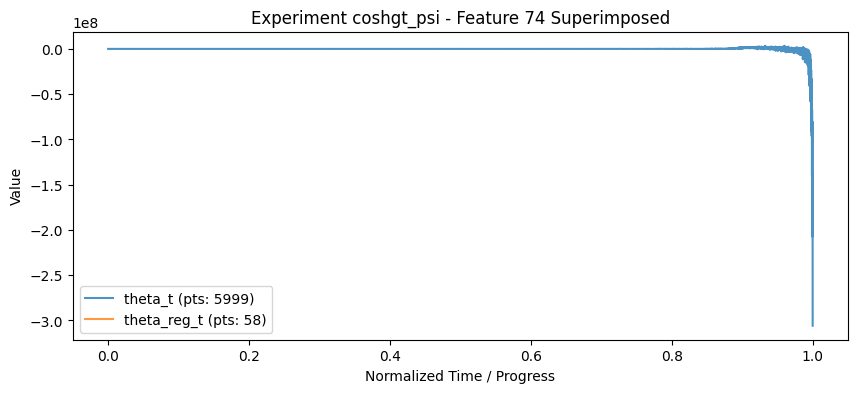

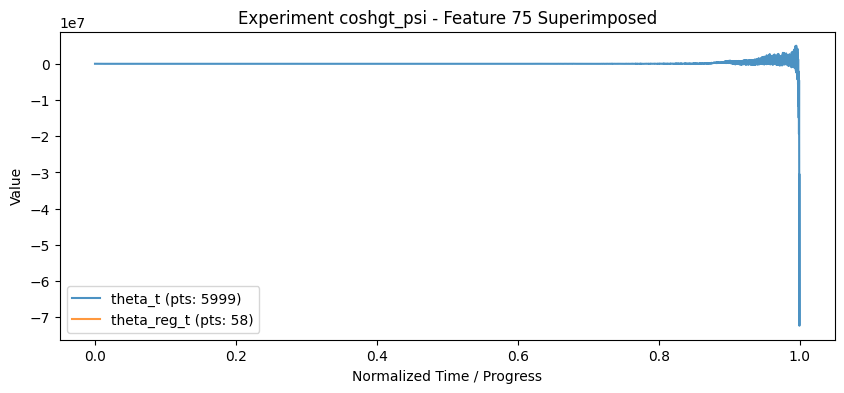

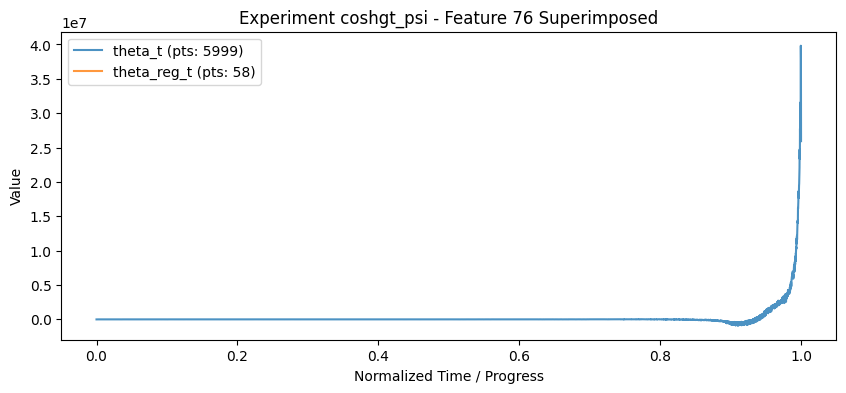

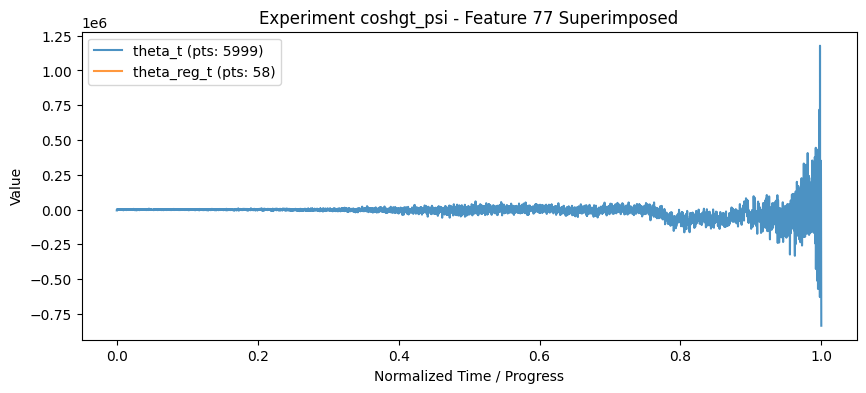

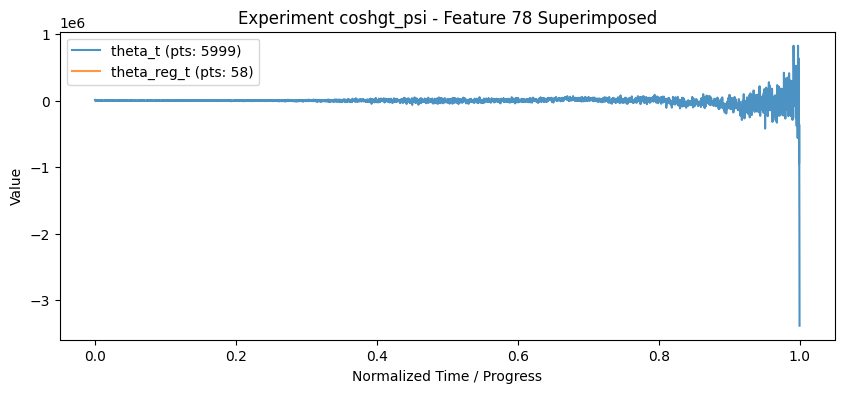

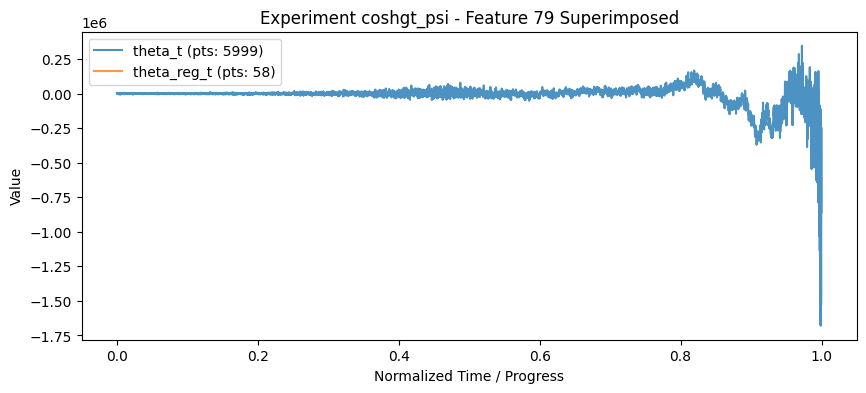

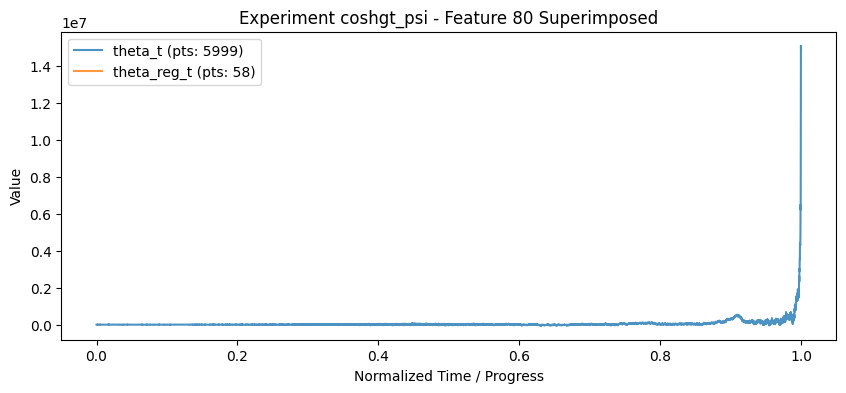

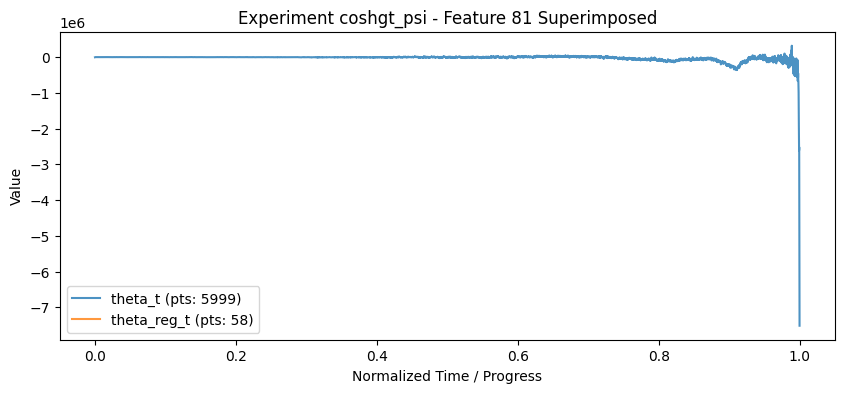

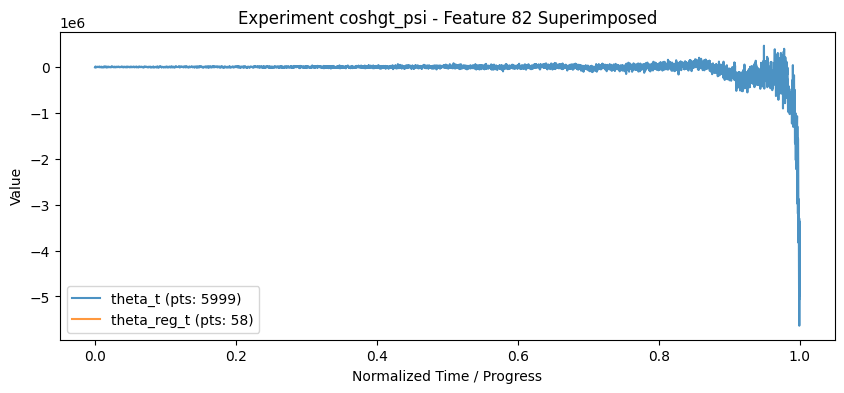

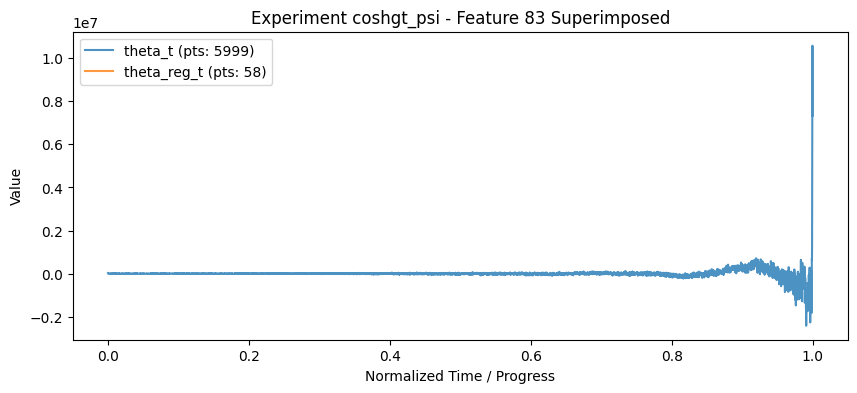

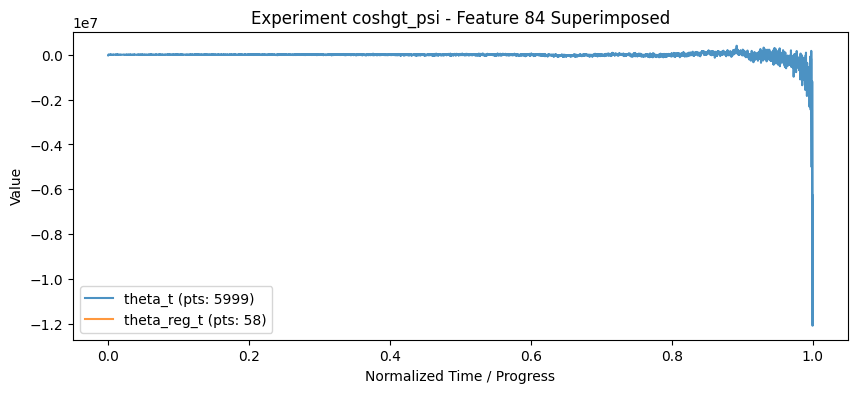

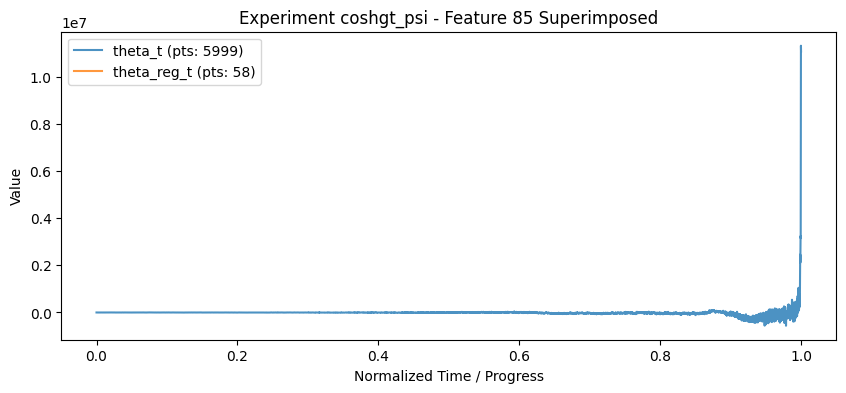

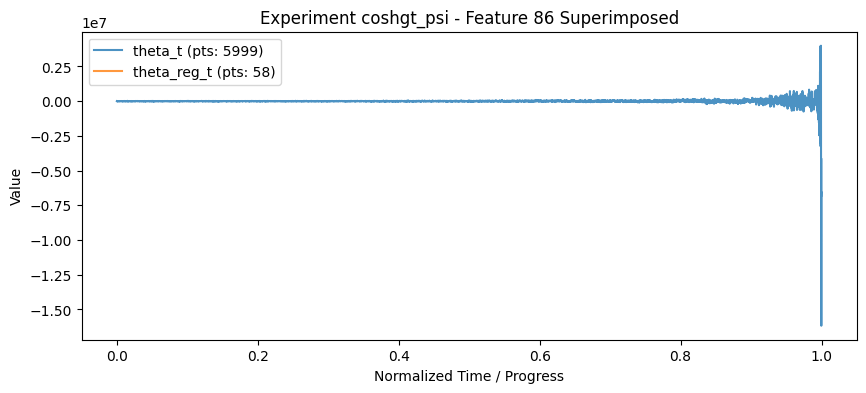

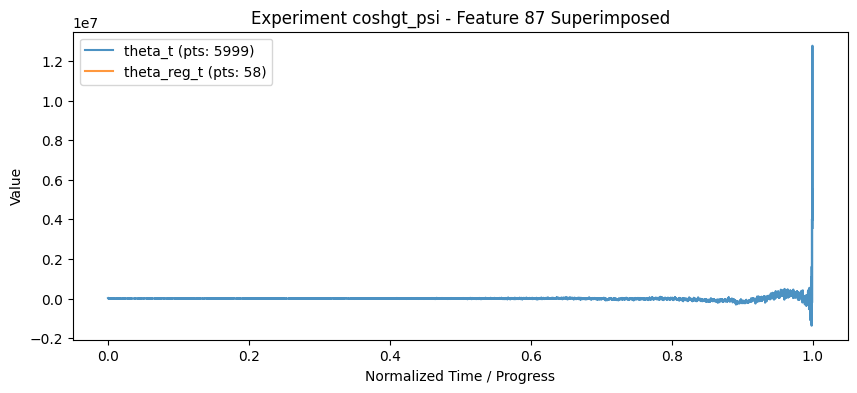

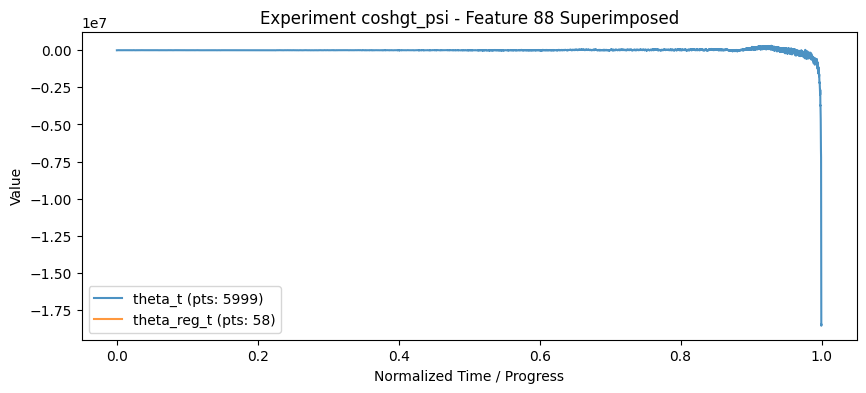

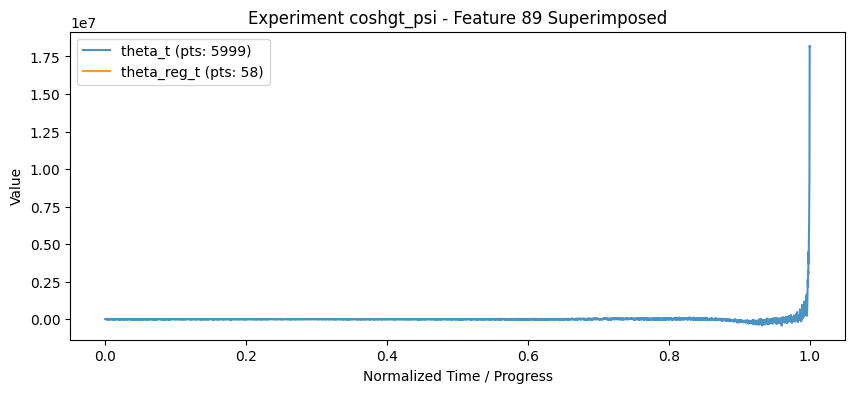

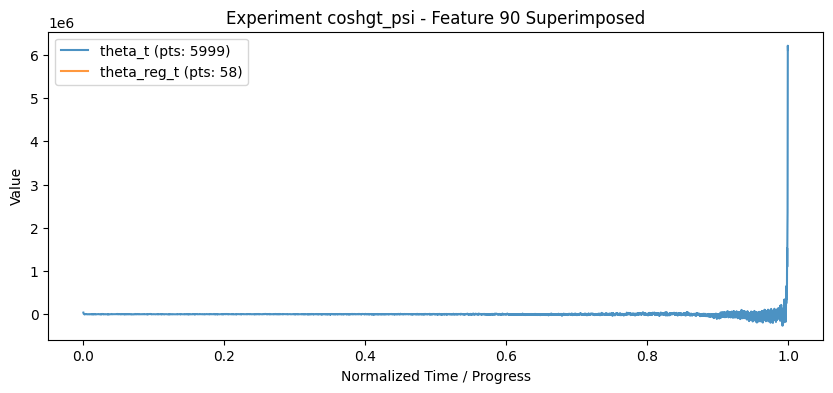

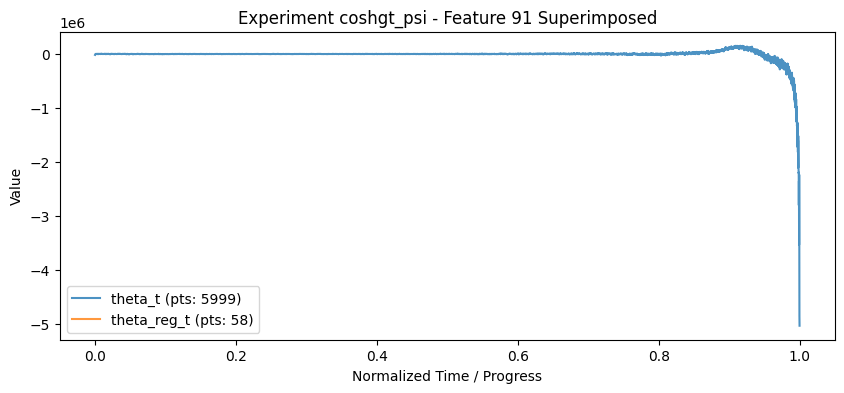

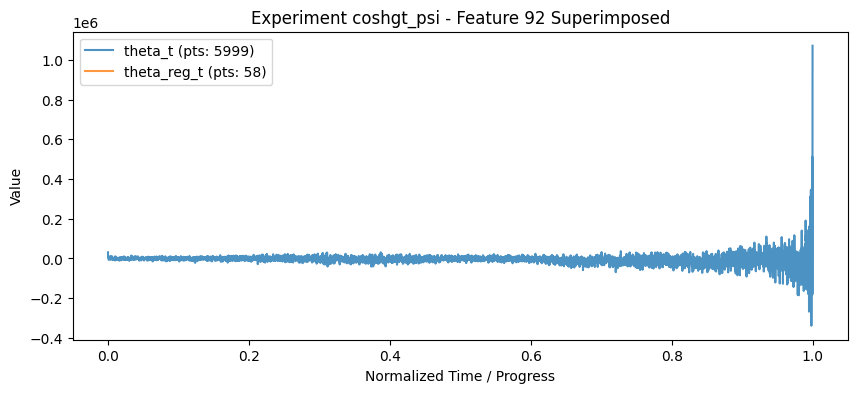

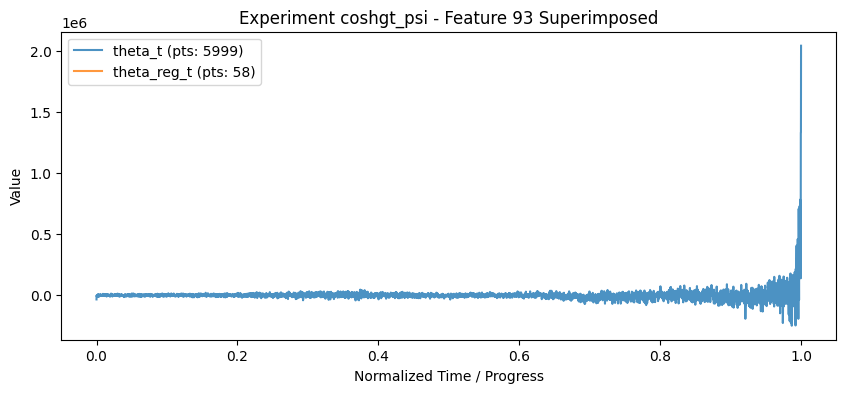

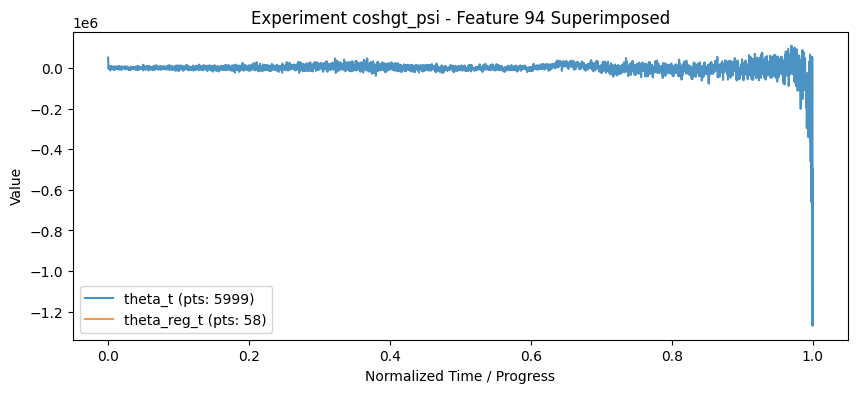

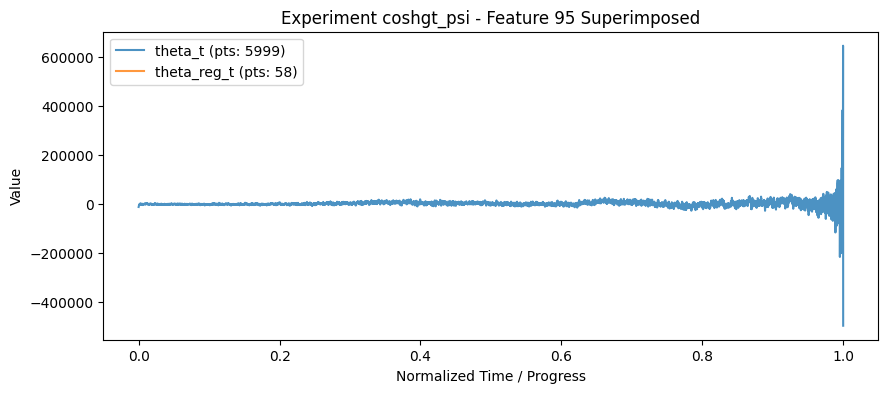

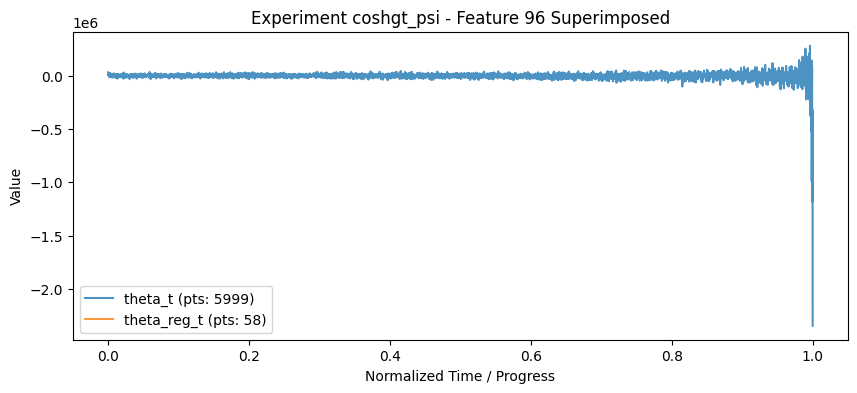

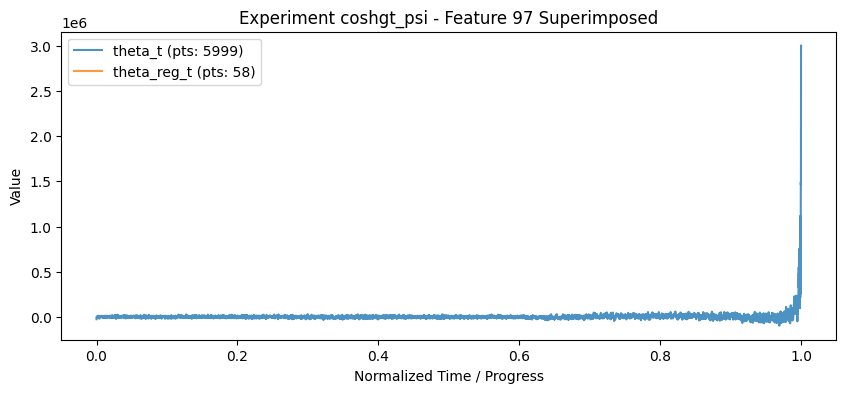

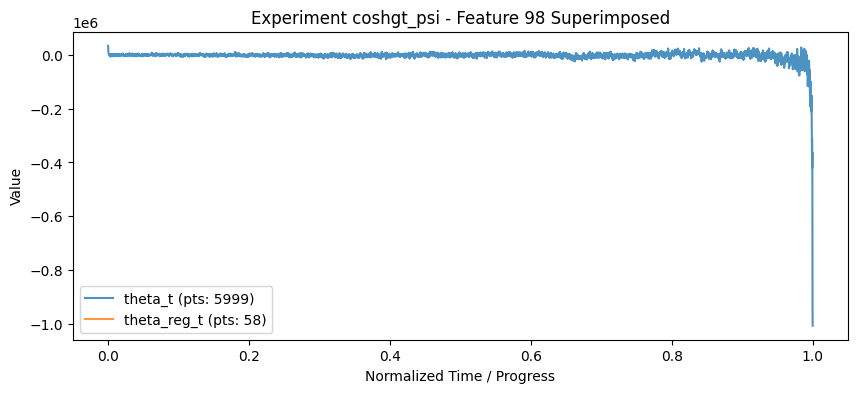

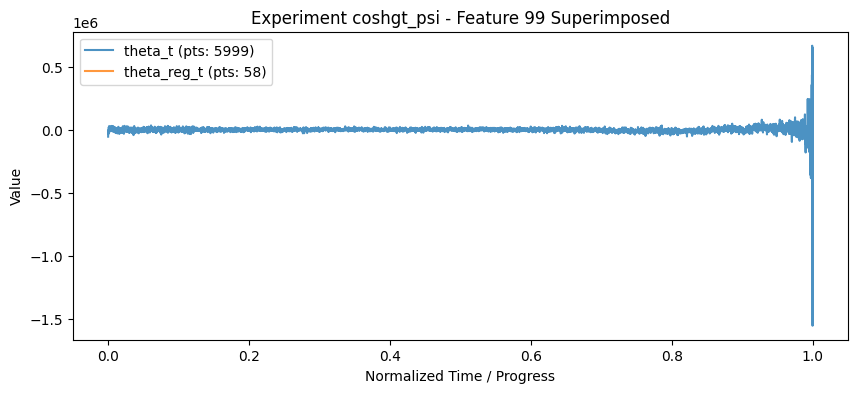

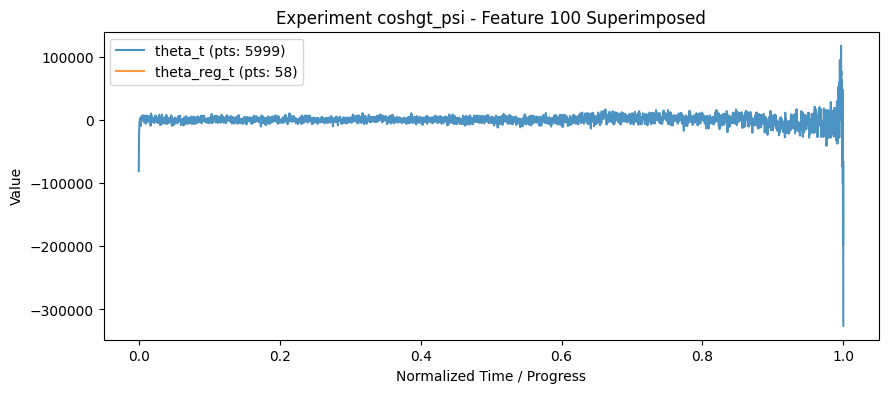

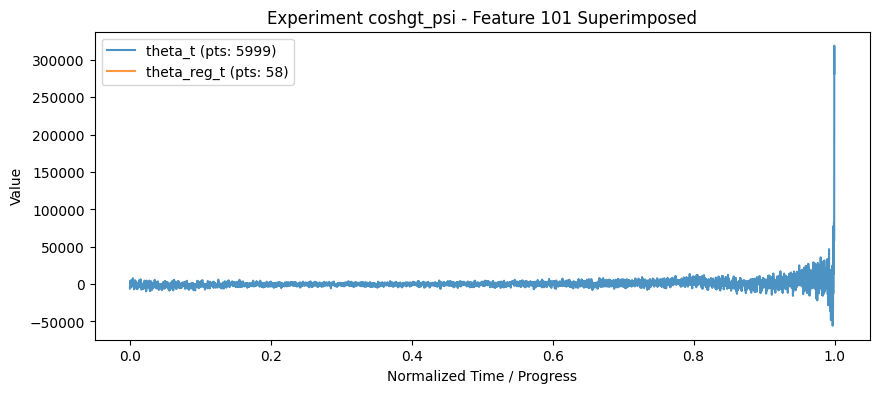

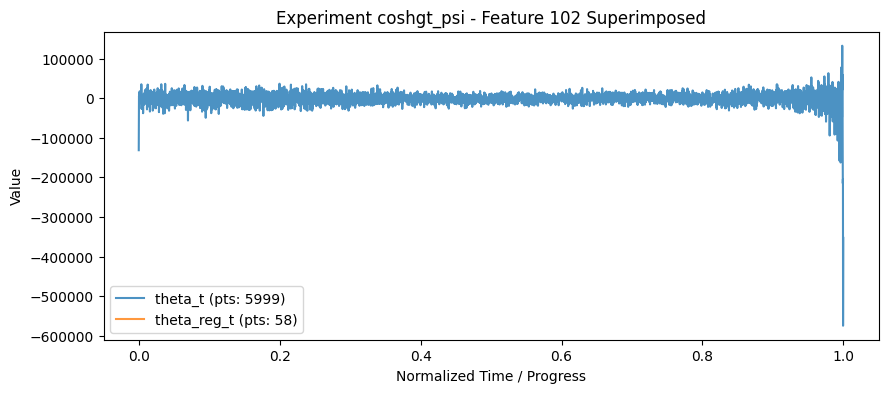

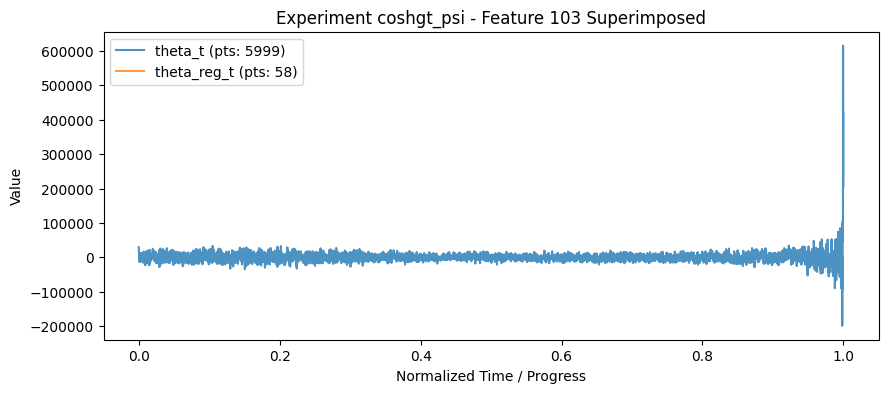

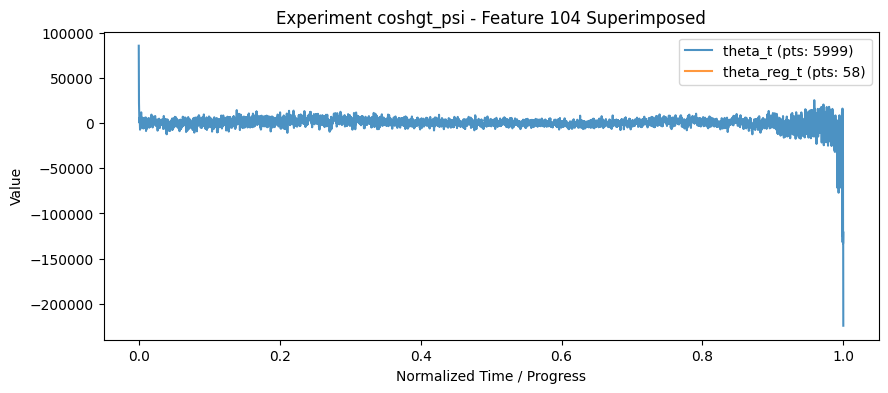

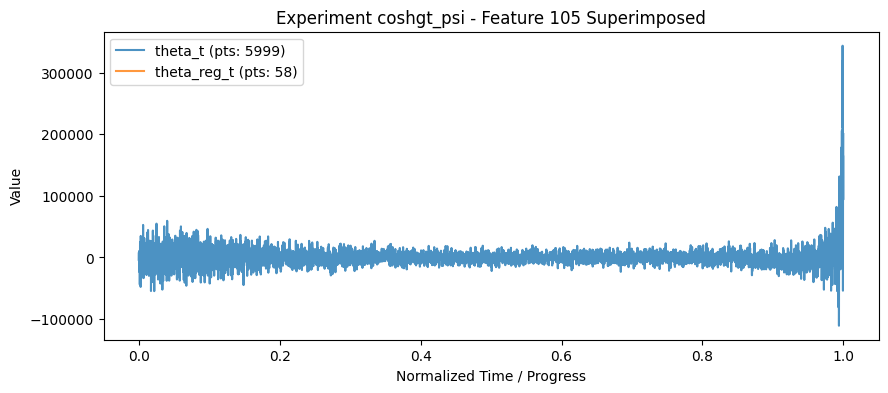

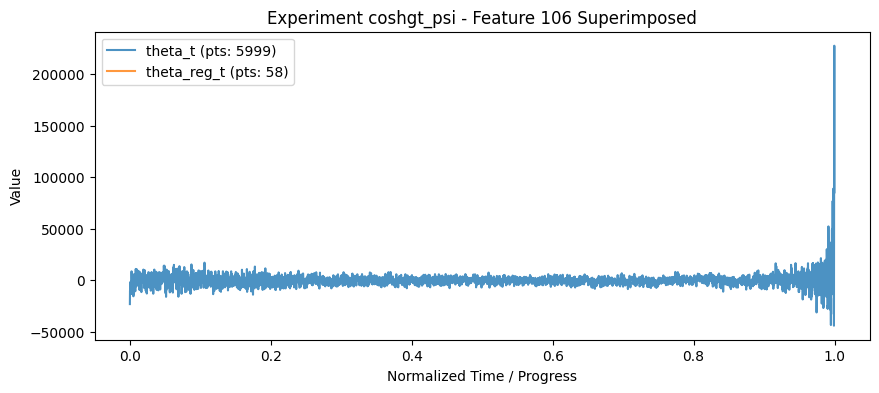

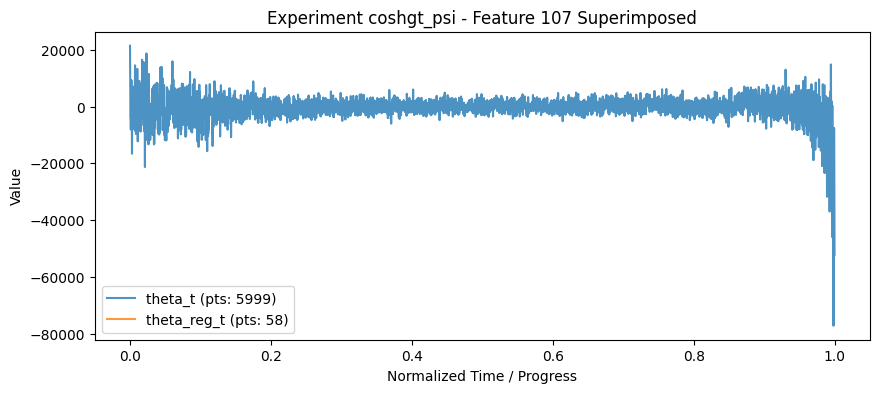

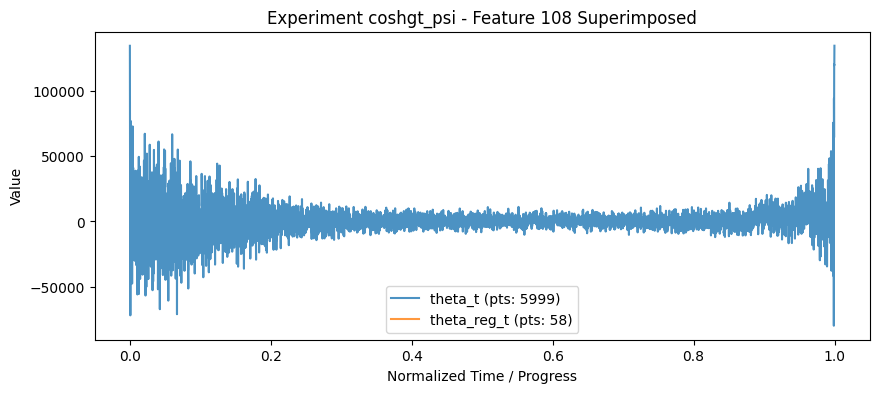

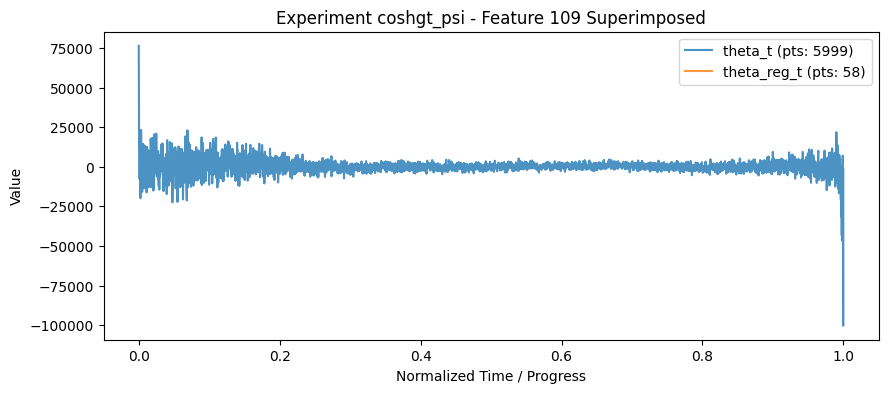

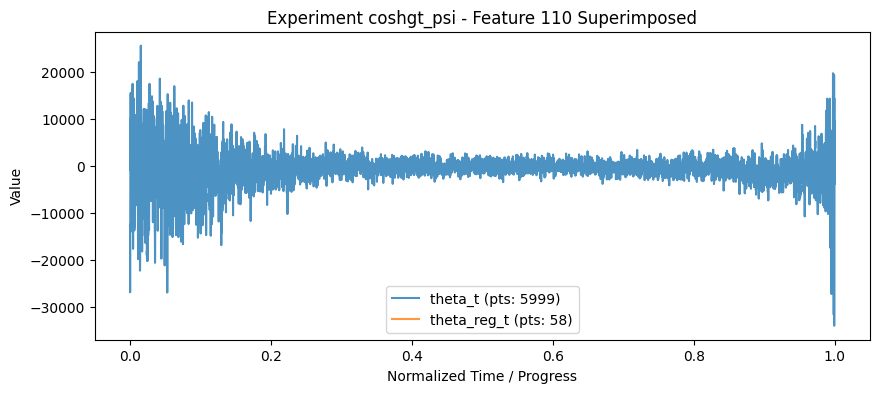

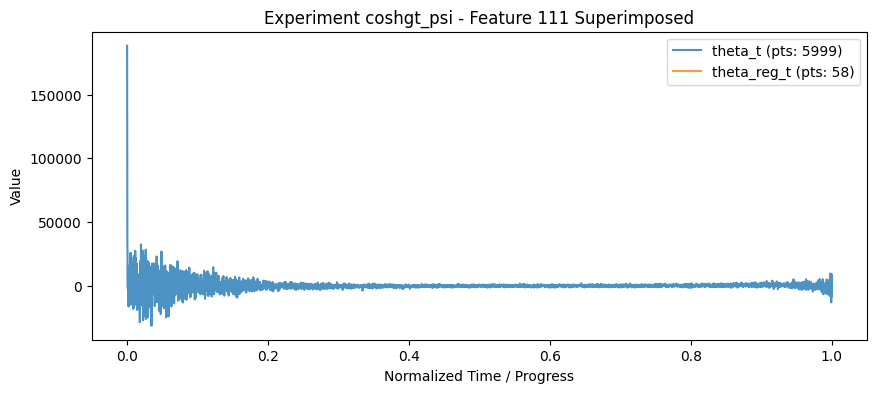

In [20]:
# Move to CPU and convert to numpy for easier plotting
theta_t = theta_t.cpu()
theta_reg_t = theta_reg_t.cpu()

# Get the number of time steps (rows) for each
len_t = theta_t.shape[0]
len_reg = theta_reg_t.shape[0]
print(len_t, len_reg) 

# Iterate through each feature/column
for i in range(theta_t.shape[1]): 
    # Create matching X-axes spanning from 0 to 1 (or 0 to len_t if preferred)
    x_t = np.linspace(0, 1, len_t)
    x_reg = np.linspace(0, 1, len_reg)
    
    plt.figure(figsize=(10, 4))
    
    # Plot both on the same axes
    plt.plot(x_t, theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_reg, theta_reg_t[:, i], label=f"theta_reg_t (pts: {len_reg})", alpha=0.8) 
    
    plt.title(f"Experiment {key} - Feature {i} Superimposed")
    plt.xlabel("Normalized Time / Progress")
    plt.ylabel("Value")
    plt.legend()
    plt.show()  # Show the combined plot

## Coarse grain signal 

In [25]:
for key, exp in experiments.items():
    xt = results[key]['xt']
    print(xt.shape) 
    print(x1.shape) 

    for j in range(1):
        xt_cg = W.decompose(xt)[1]
        x1_cg = W.decompose(x1)[1]
    print(xt_cg.shape) 
    print(x1_cg.shape) 

torch.Size([20000, 1, 256])
torch.Size([20000, 1, 256])
torch.Size([20000, 1, 128])
torch.Size([20000, 1, 128])


## Or don't

In [21]:
xt_cg = results[key]['xt']
x1_cg = x1 
print(xt_cg.shape, x1_cg.shape) 

torch.Size([20000, 1, 256]) torch.Size([20000, 1, 256])


## Moment matching diagnostics

CoshGt ψ


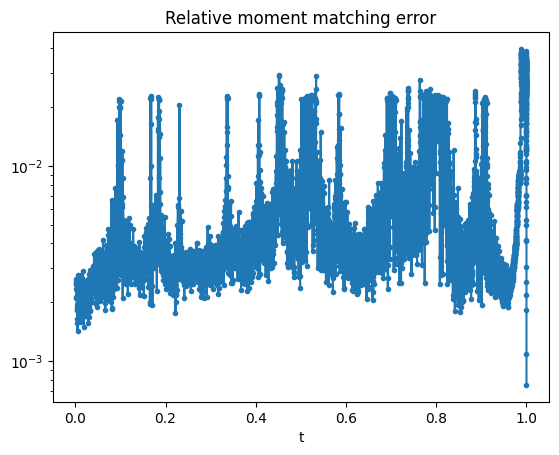

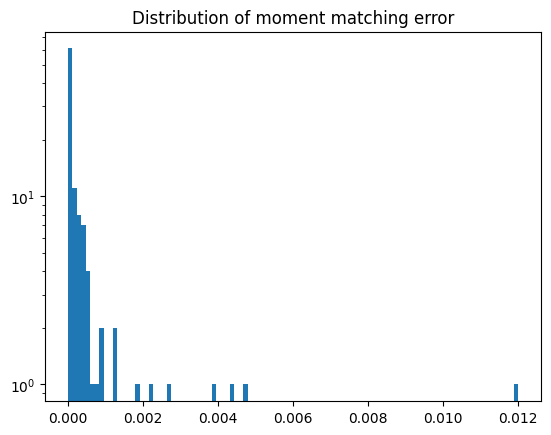

<Figure size 640x480 with 0 Axes>

In [22]:
threshold = 1e-8

for key, exp in experiments.items():
    res = results[key]
    print(exp['label'])
    if res.get('barphi_e') is None or res.get('barphi_p') is None:
        print('Moment matching arrays not available. Set FORCE_RERUN=True or make sure the auxiliary file exists.')
    else:
        plot_moment_matching(res['barphi_e'], res['barphi_p'], res['t'], threshold)
        plt.suptitle(exp['label'])
        plt.show()


## Visual comparison of samples

torch.Size([20000, 1, 256])
CoshGt ψ


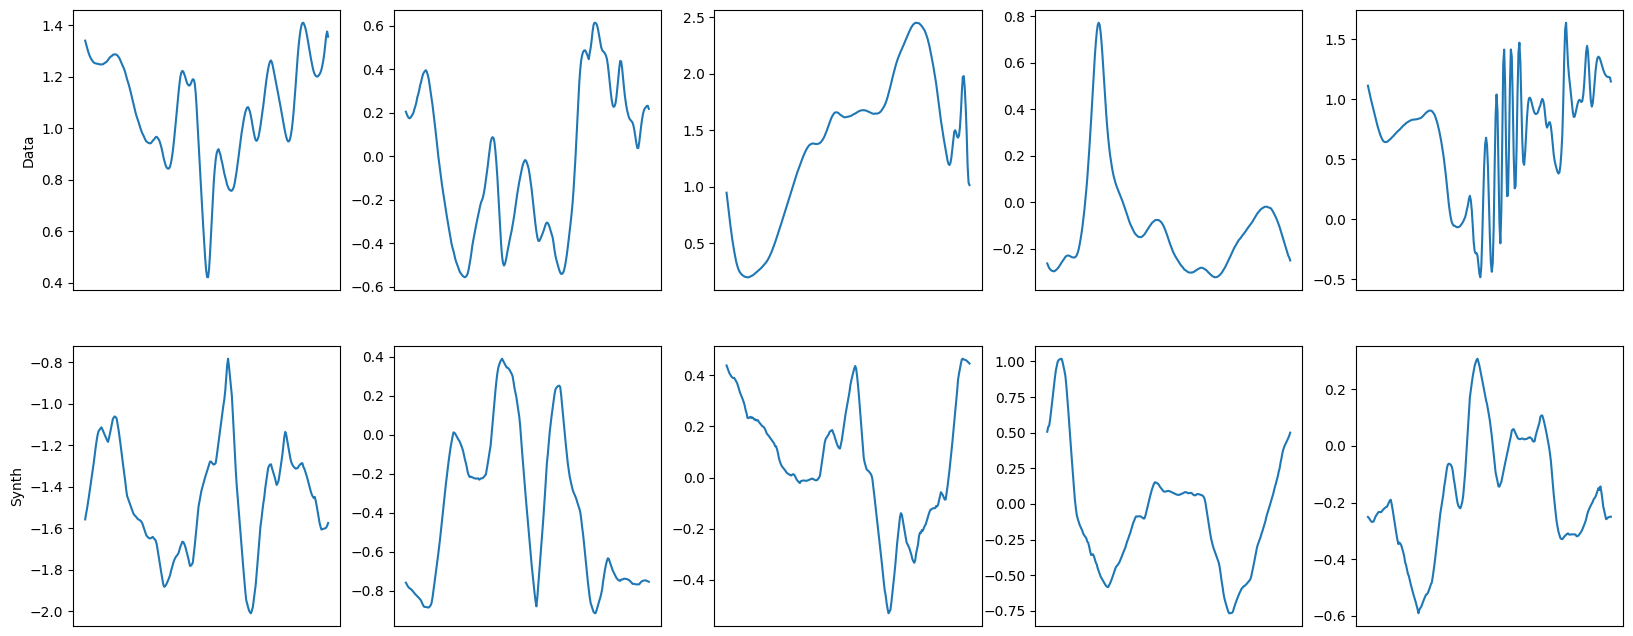

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


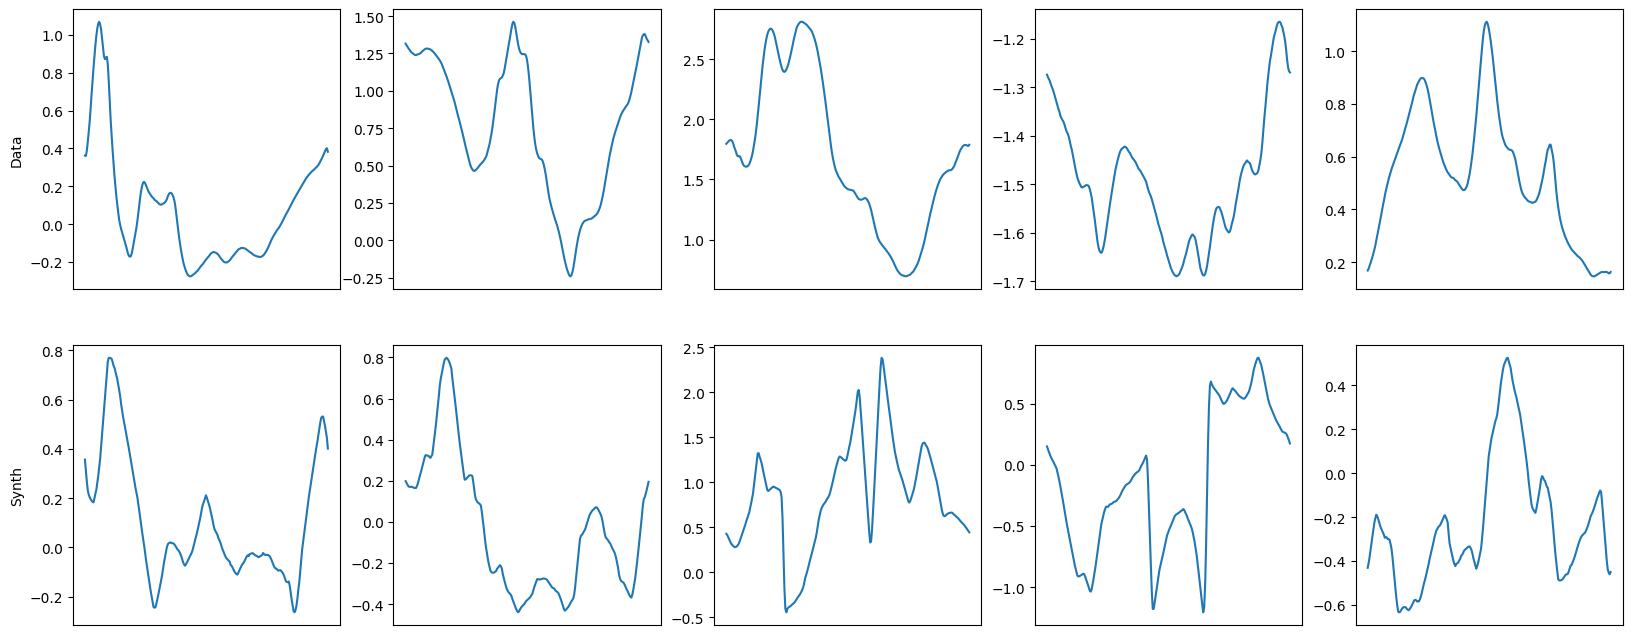

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


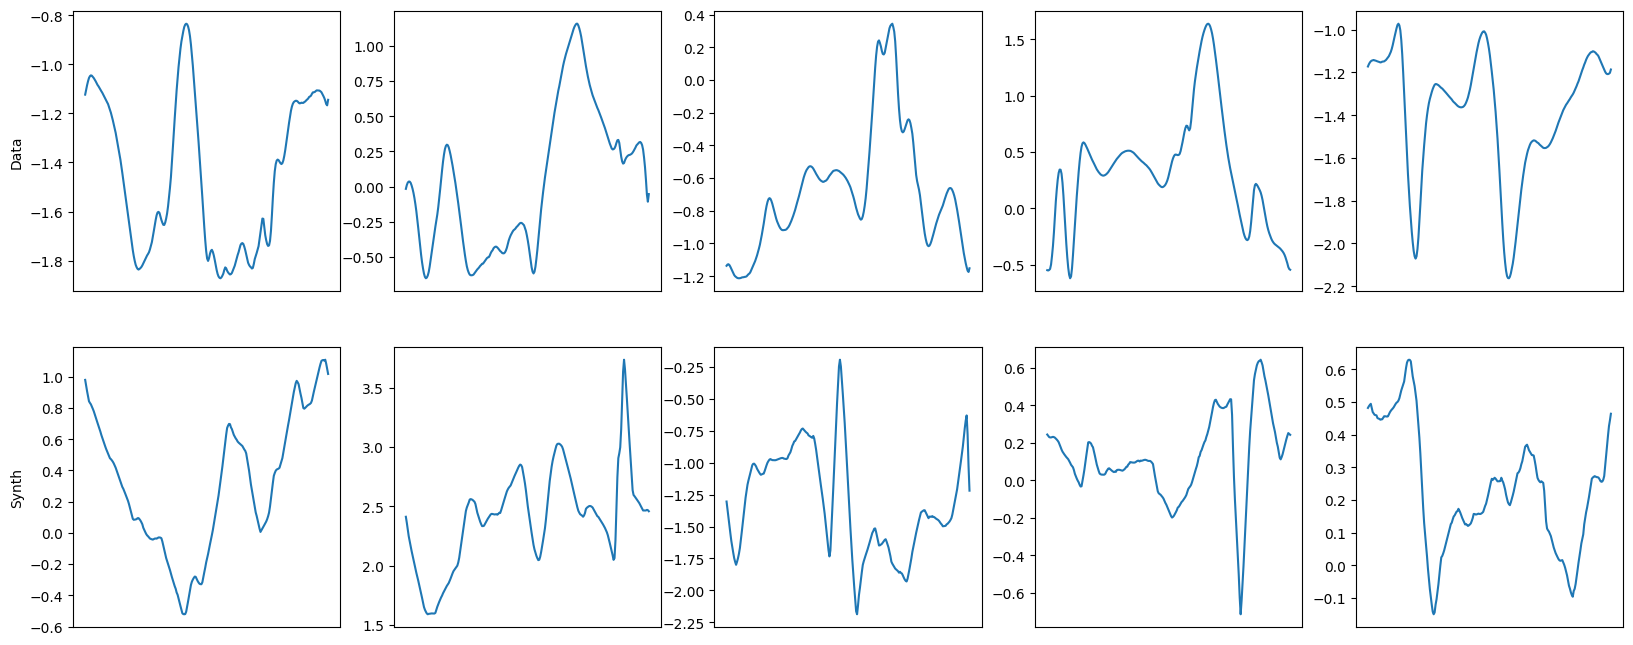

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


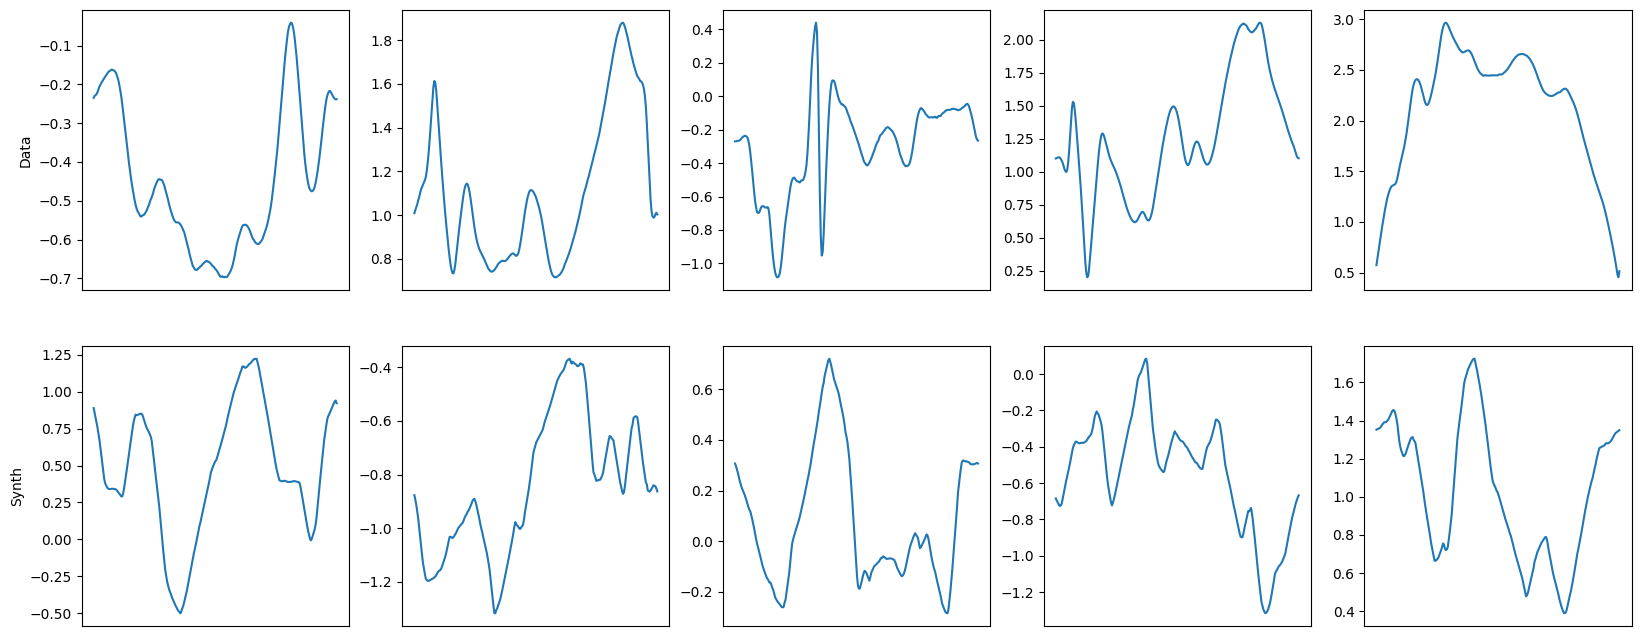

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


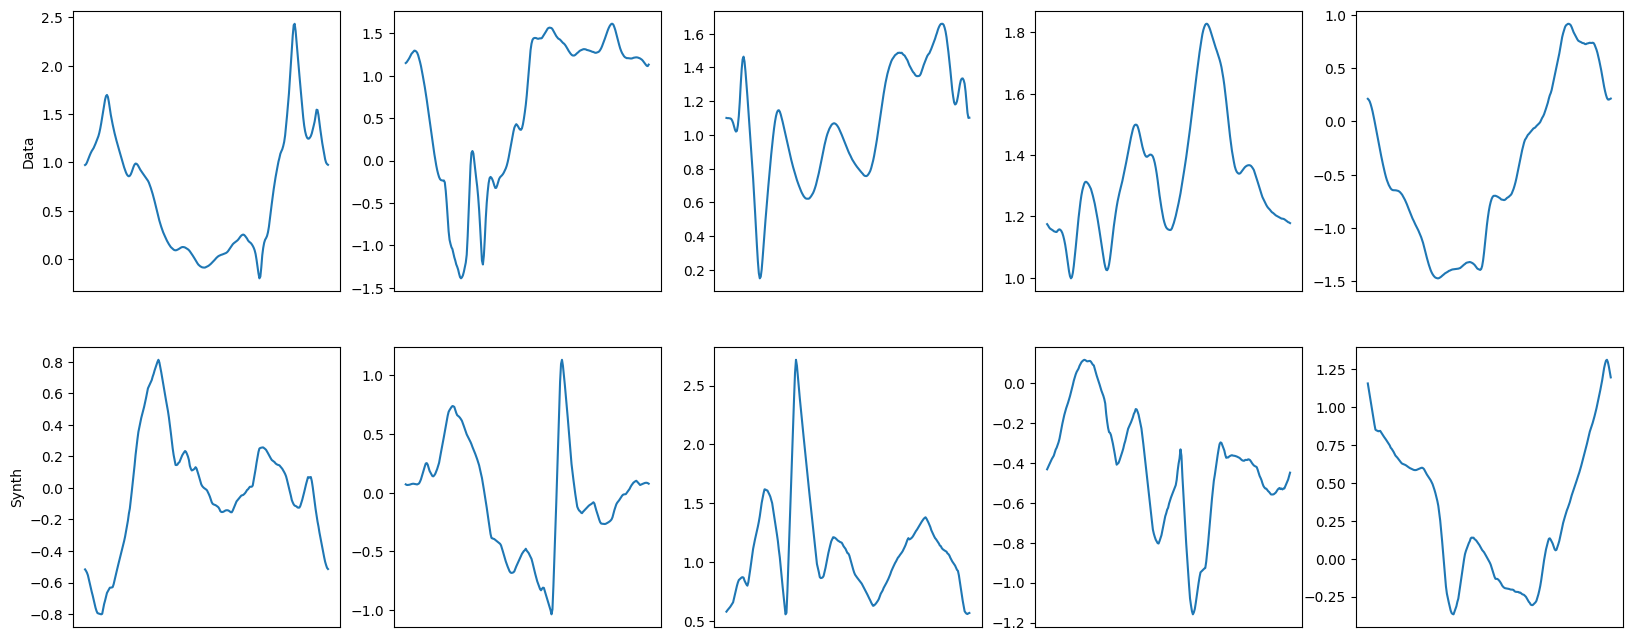

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


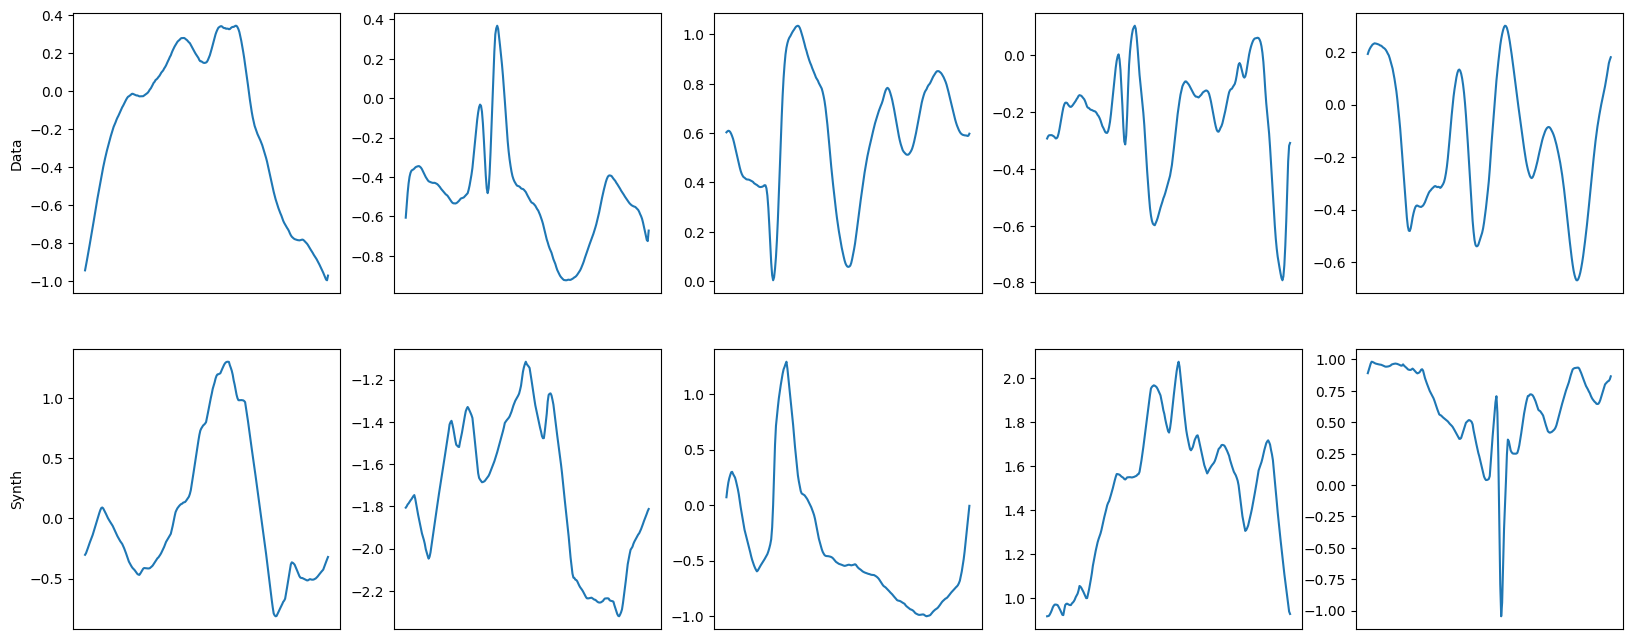

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


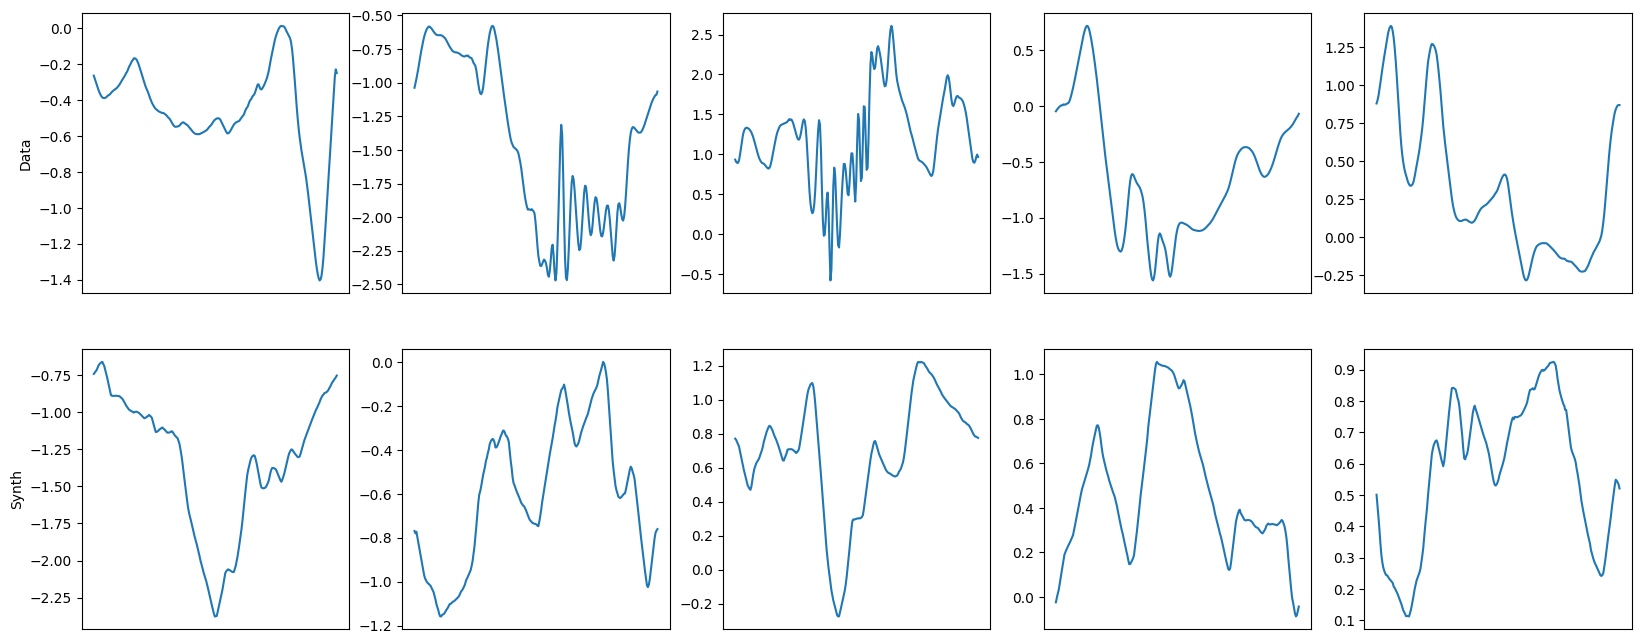

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


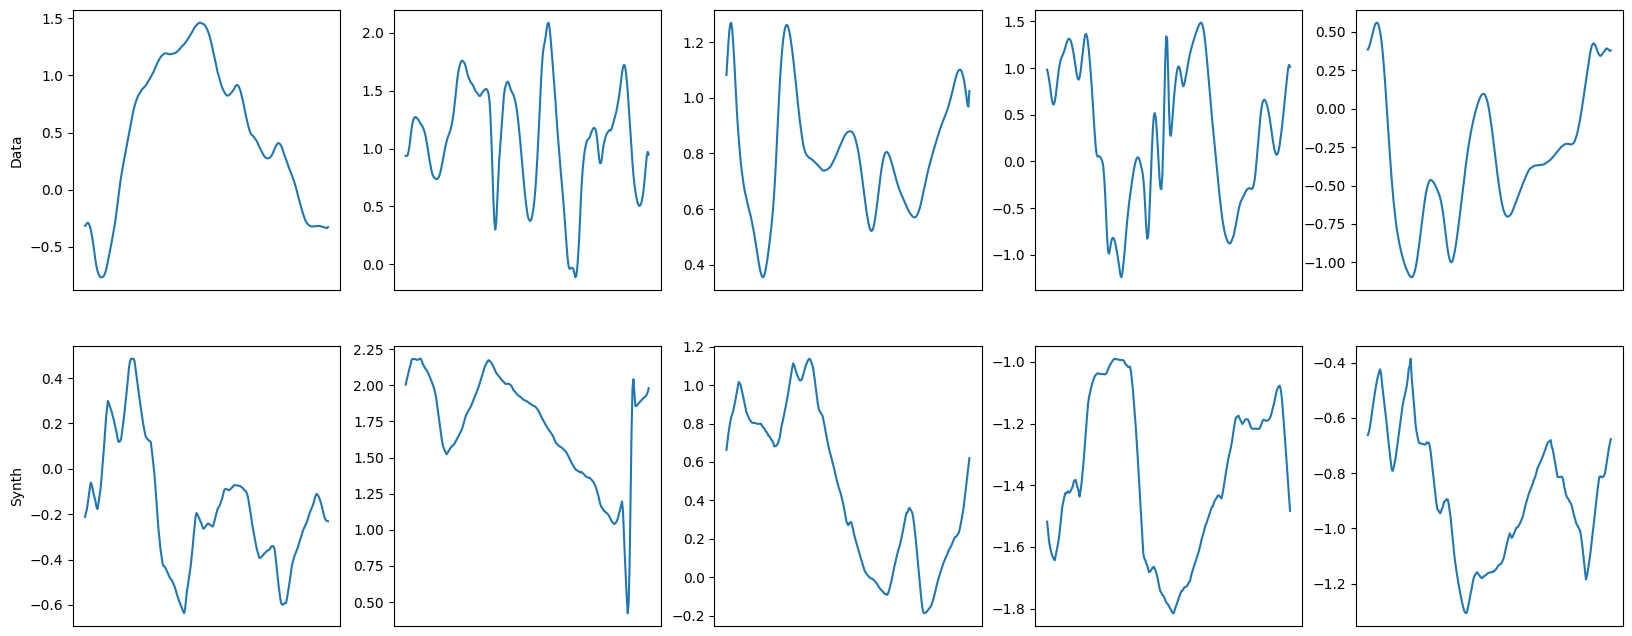

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


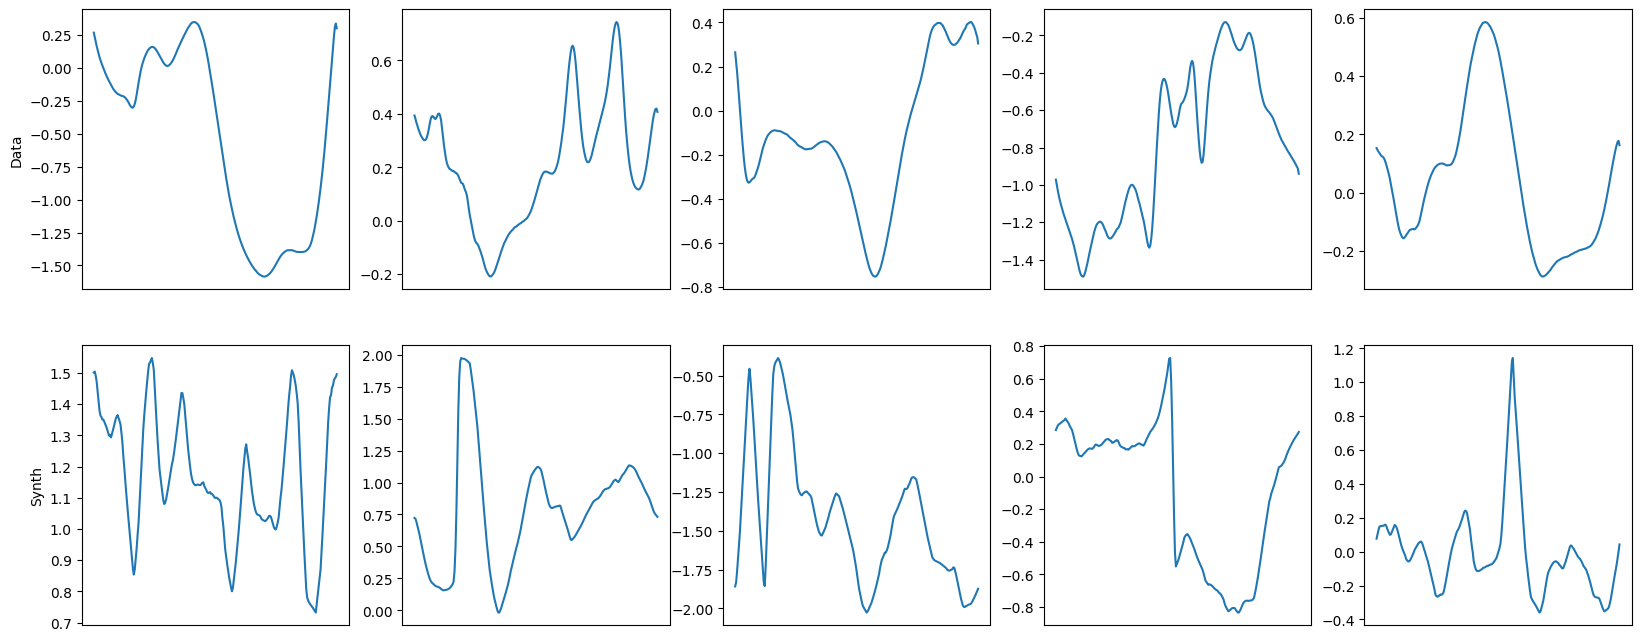

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


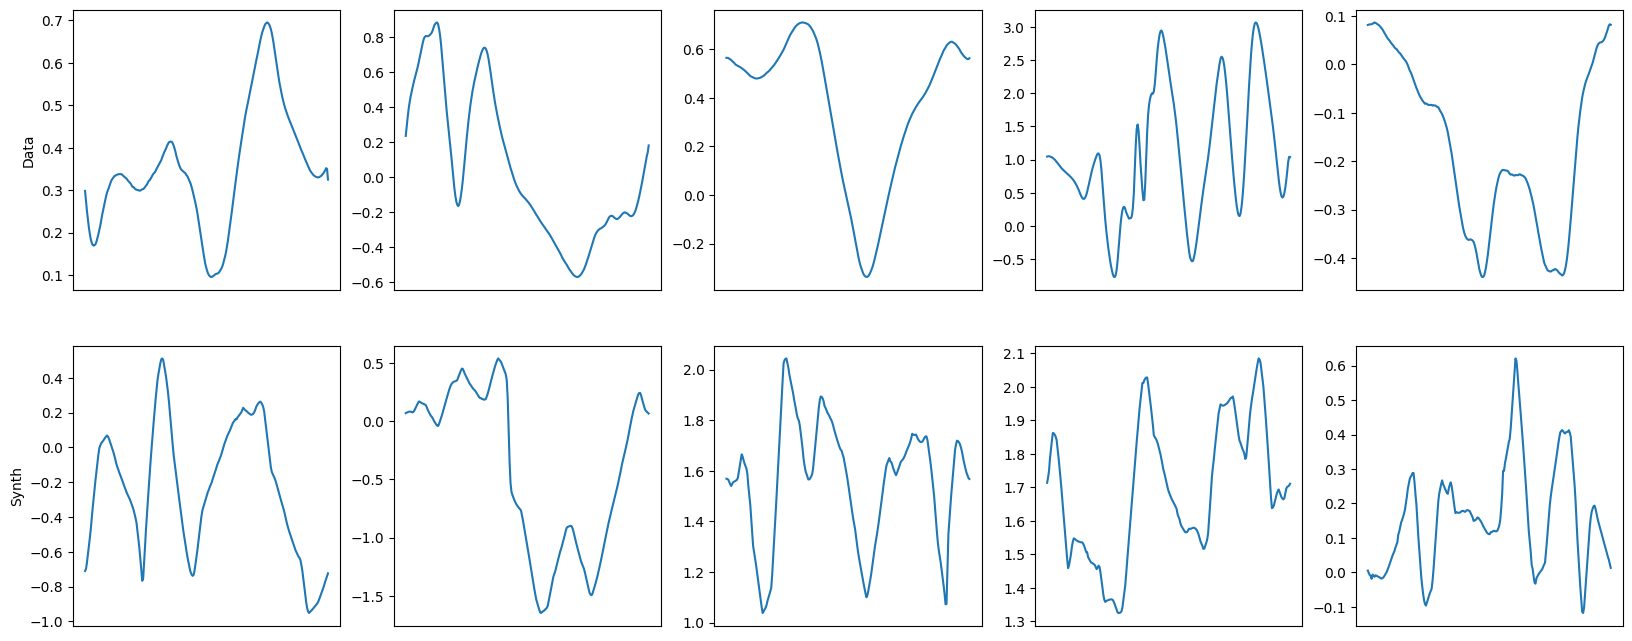

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


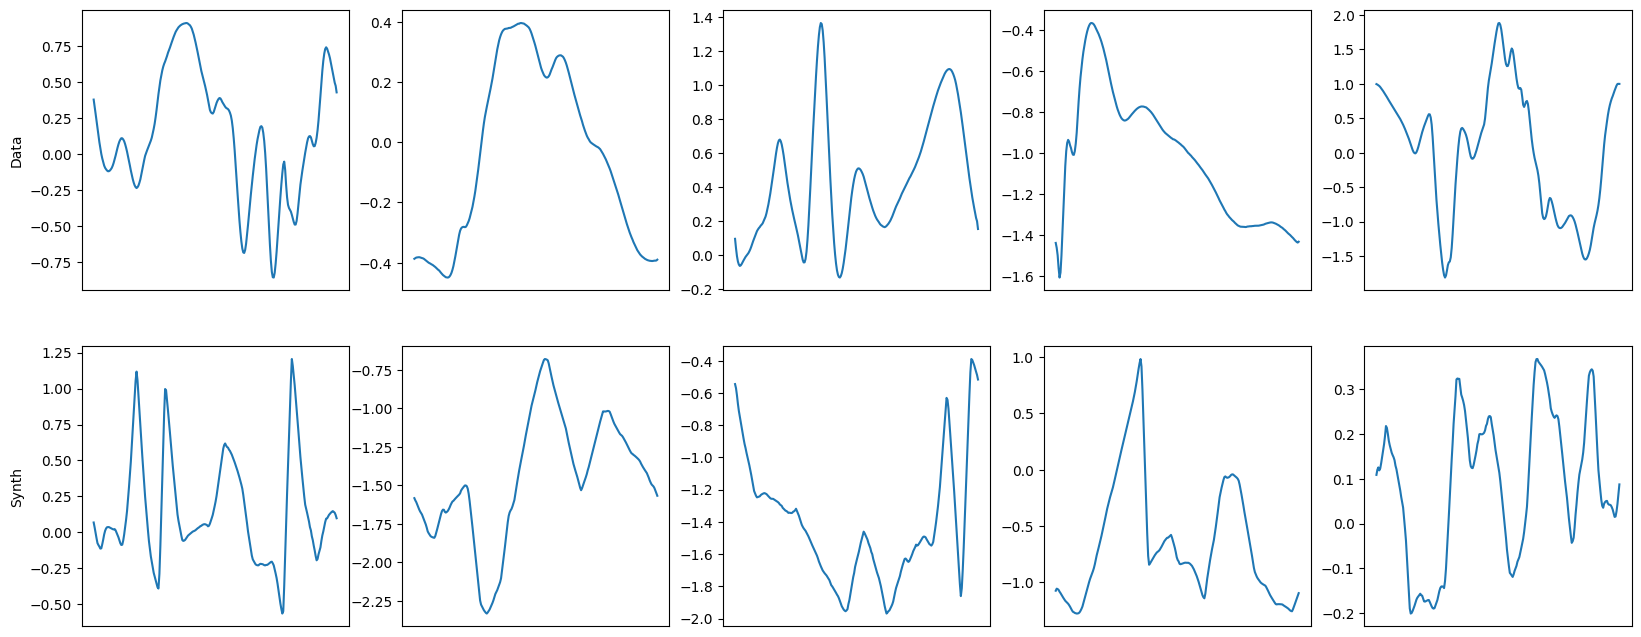

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


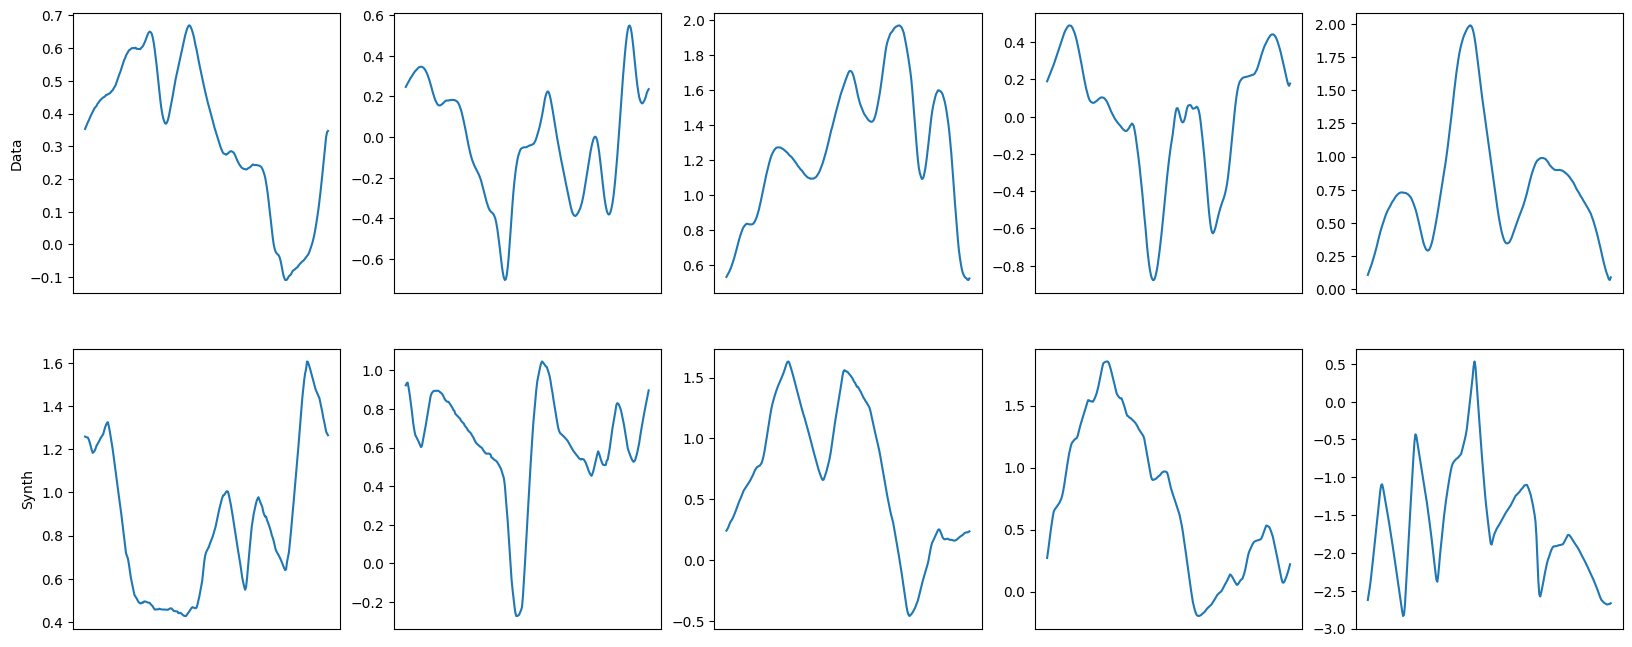

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


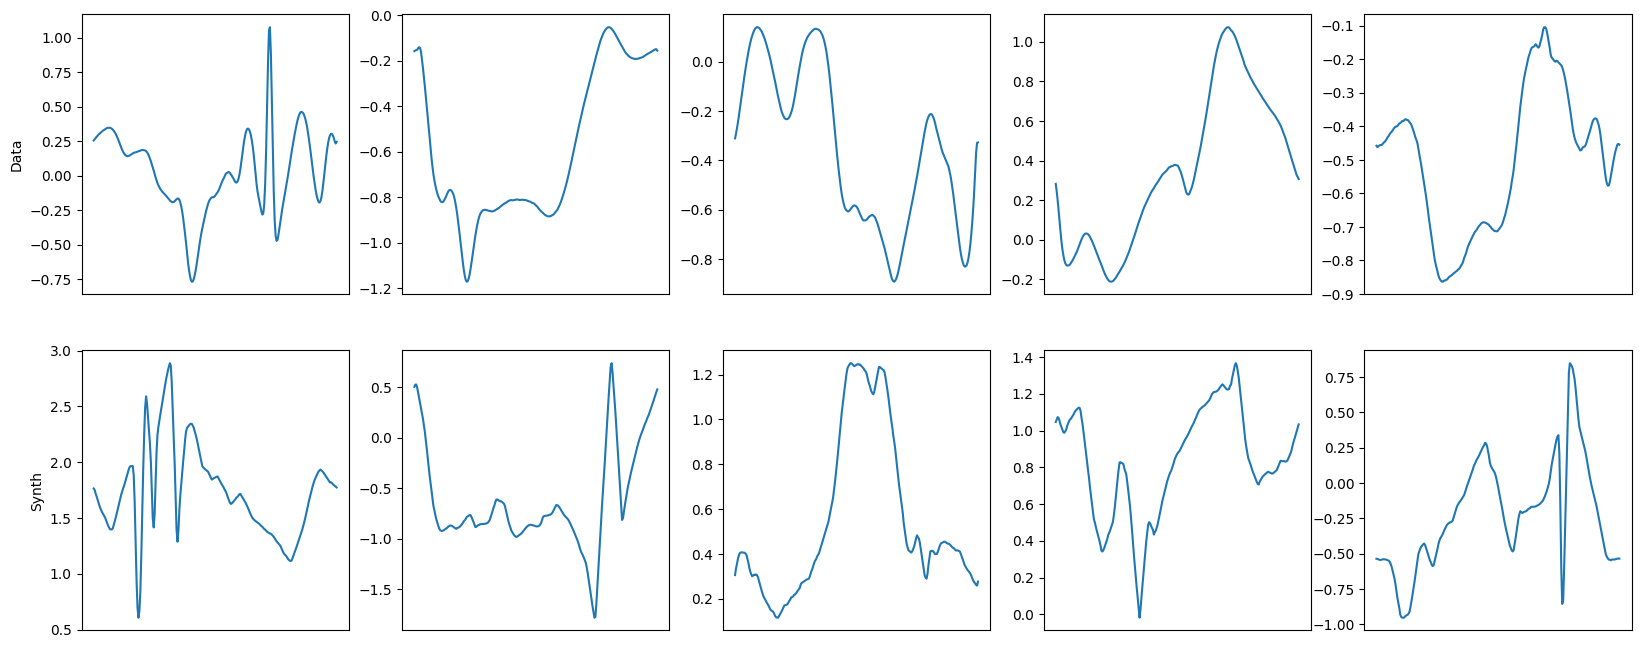

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


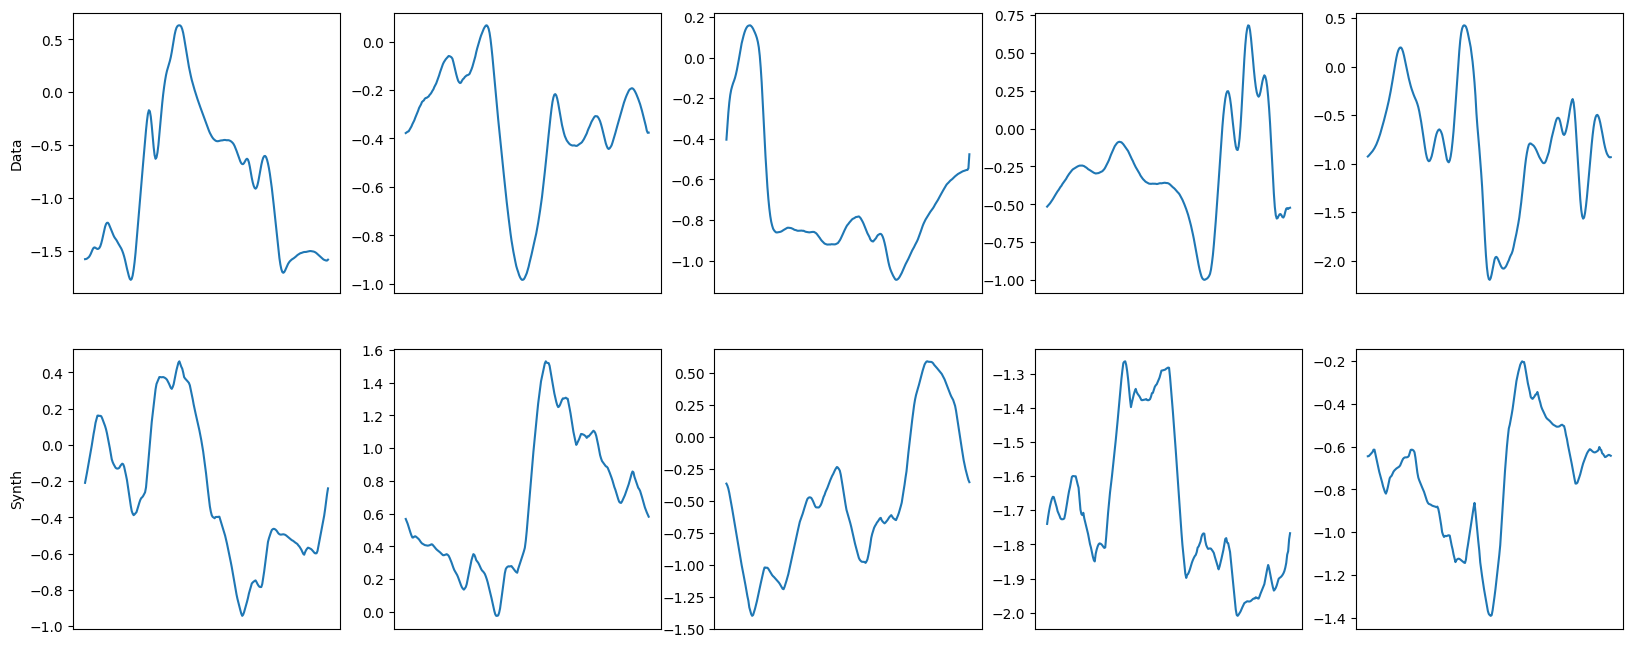

<Figure size 640x480 with 0 Axes>

torch.Size([20000, 1, 256])
CoshGt ψ


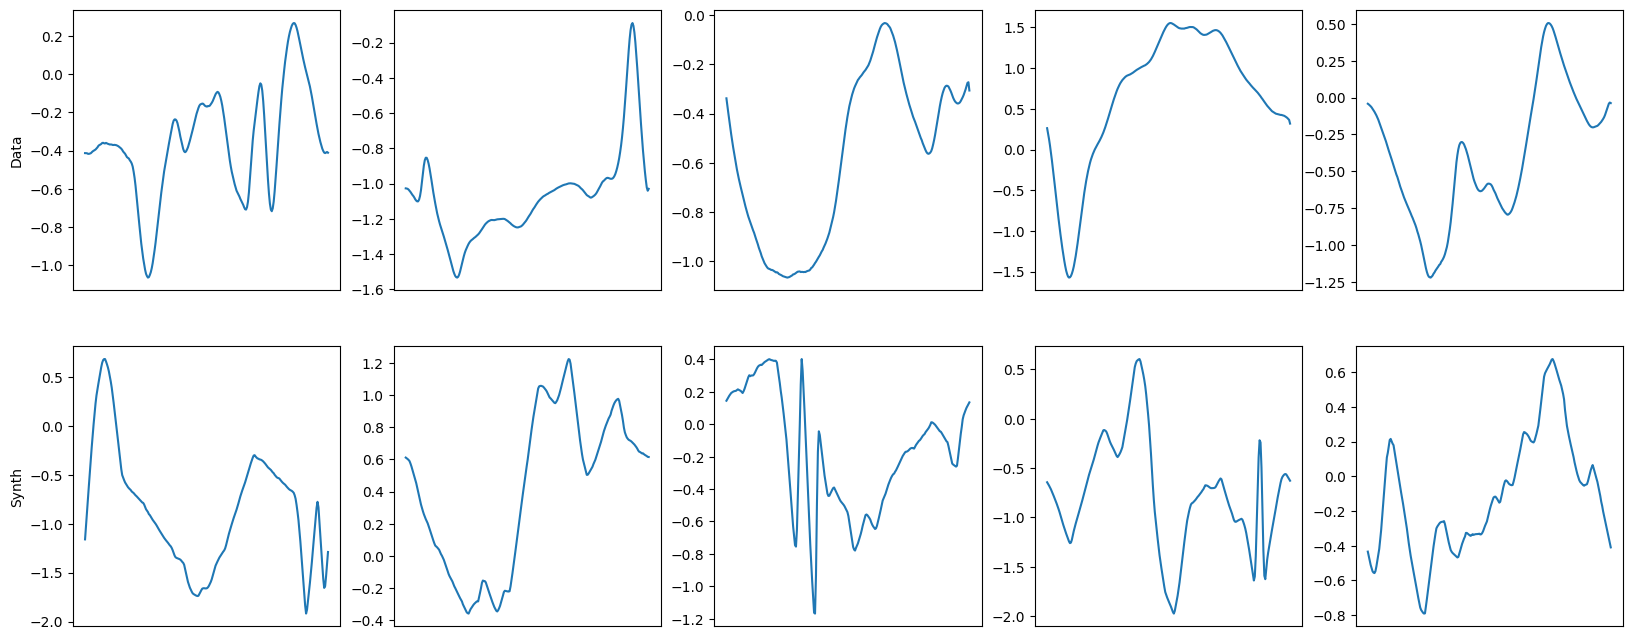

<Figure size 640x480 with 0 Axes>

In [23]:
for i in range(0,15): 
    for key, exp in experiments.items():
        print(xt_cg.shape) 
        print(exp['label'])
        Compare_time_series_row(x1_cg[i*5:i*5+5,:,:], xt_cg[i*5:i*5+5,:,:],5)
        plt.suptitle(exp['label'])
        plt.show()


## Existing project diagnostics, side by side by model

Spectrum
CoshGt ψ


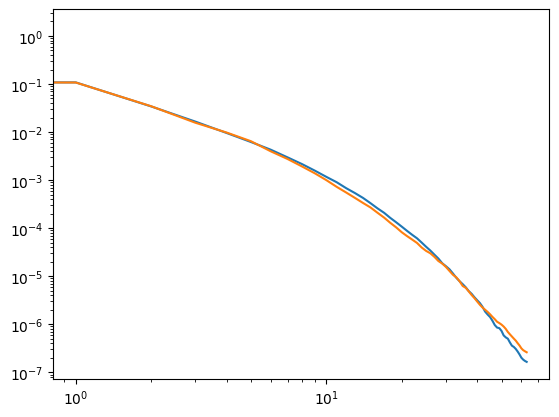

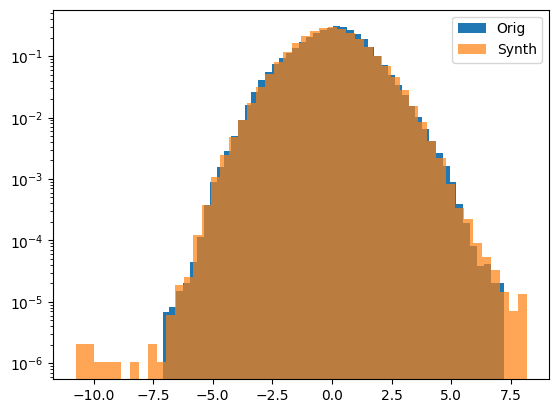

<Figure size 640x480 with 0 Axes>

Histogram
CoshGt ψ


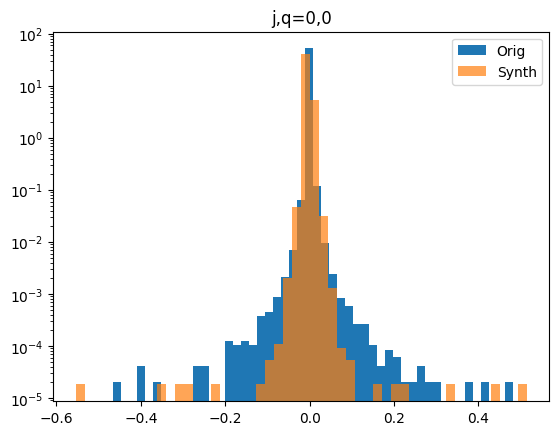

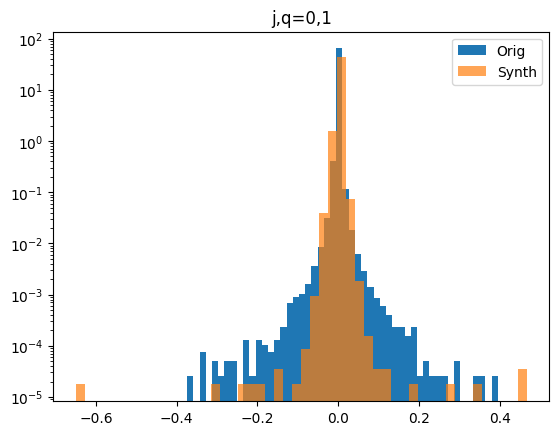

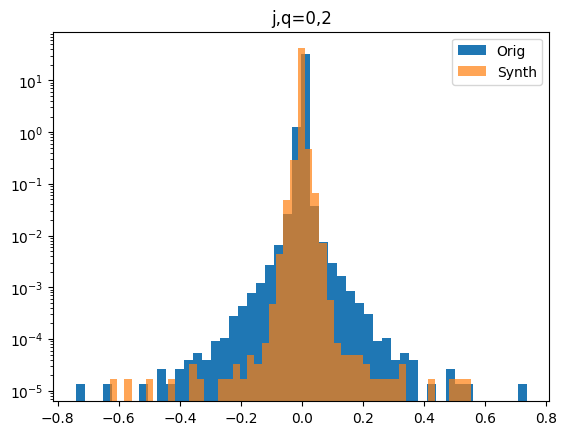

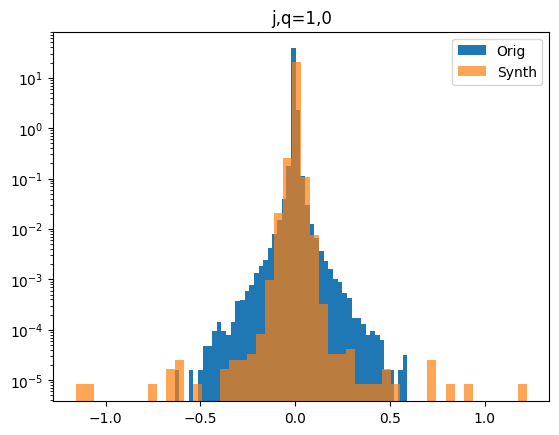

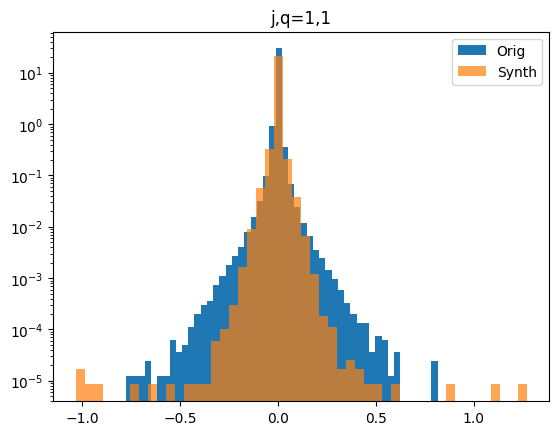

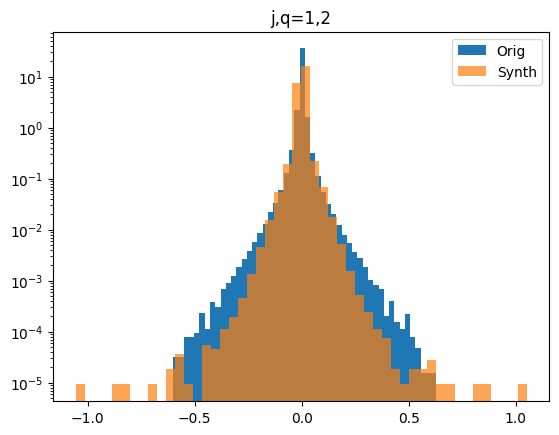

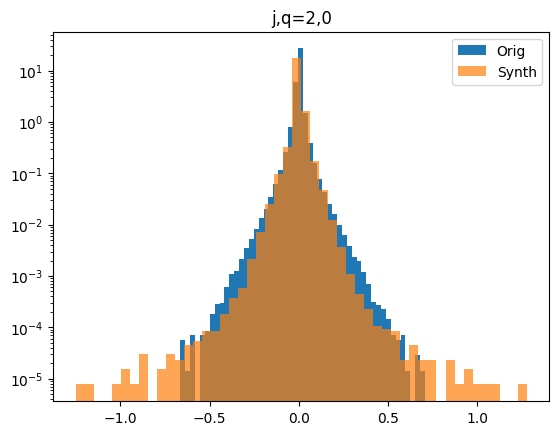

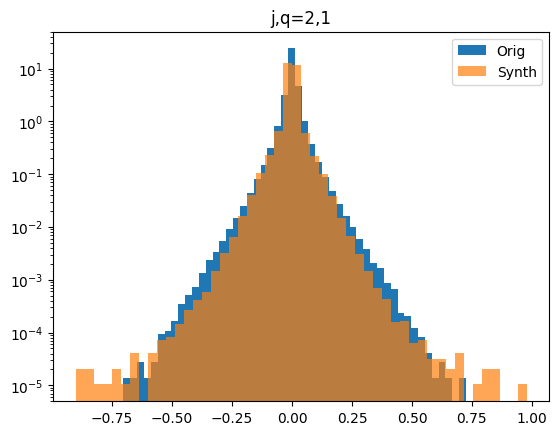

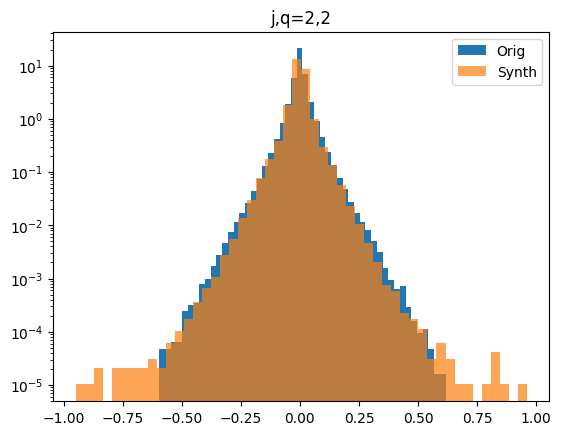

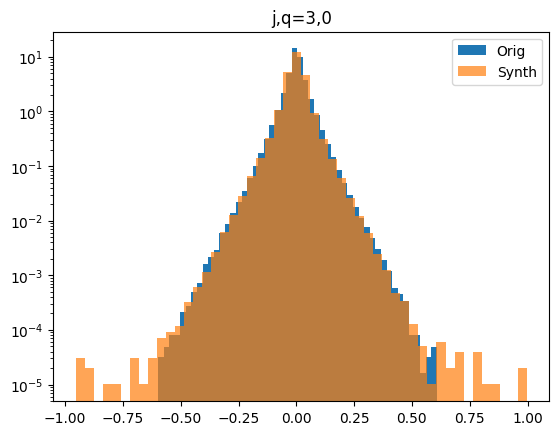

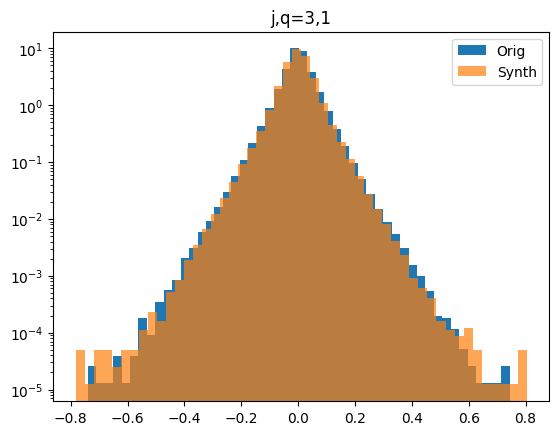

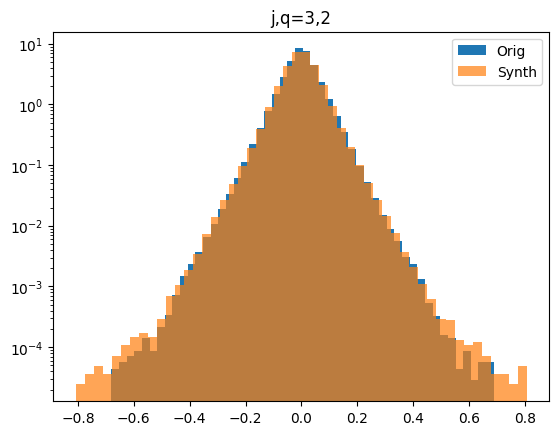

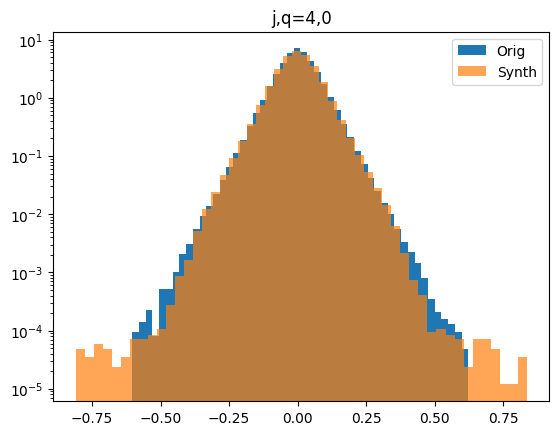

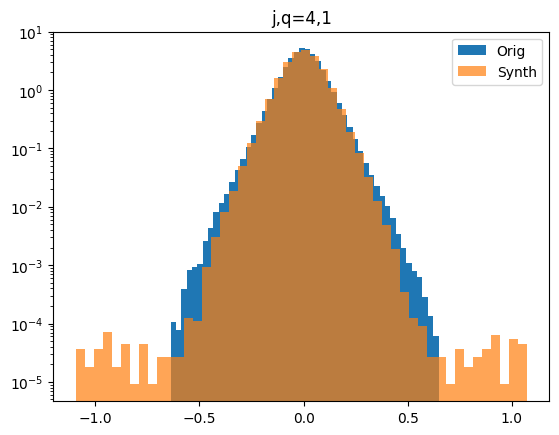

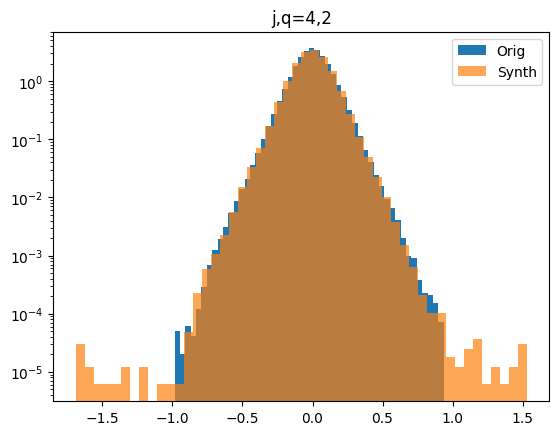

<Figure size 640x480 with 0 Axes>

Structure functions
CoshGt ψ


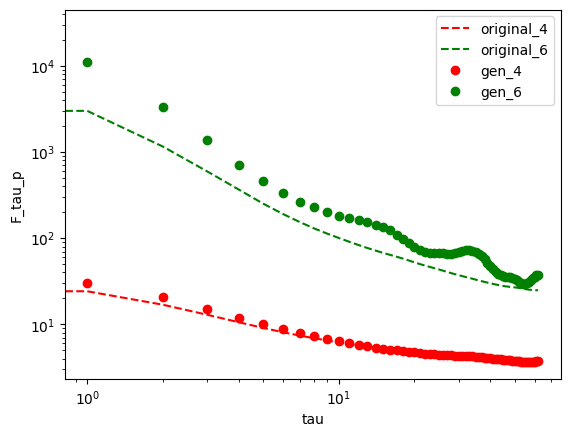

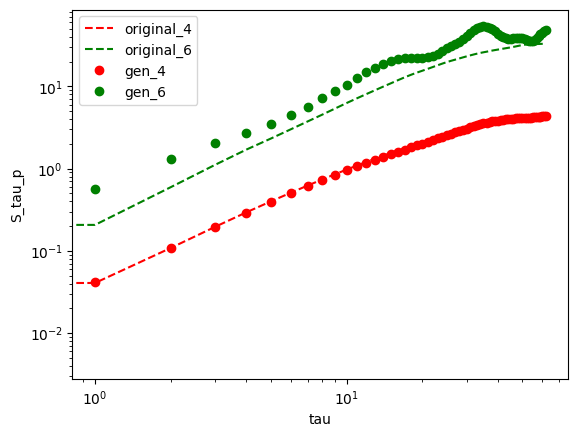

<Figure size 640x480 with 0 Axes>

Cross statistics
CoshGt ψ
(p,q)= (3, 1)


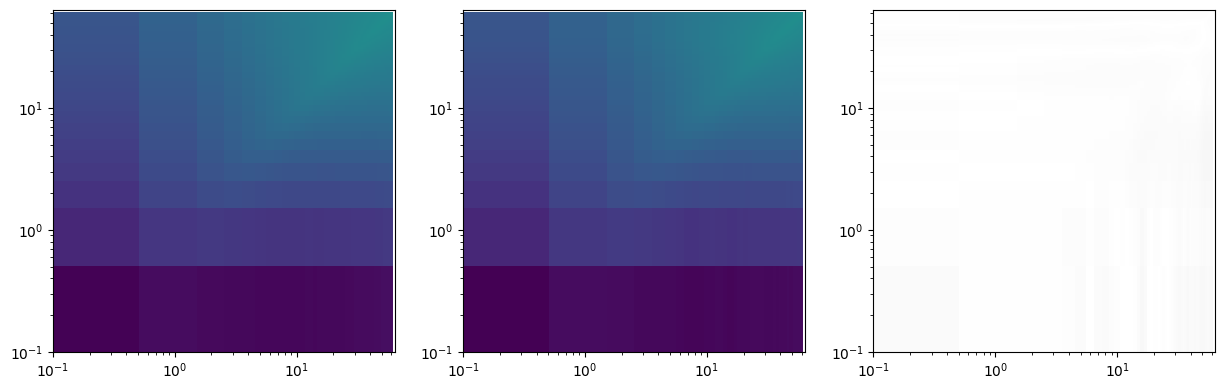

(p,q)= (3, 3)


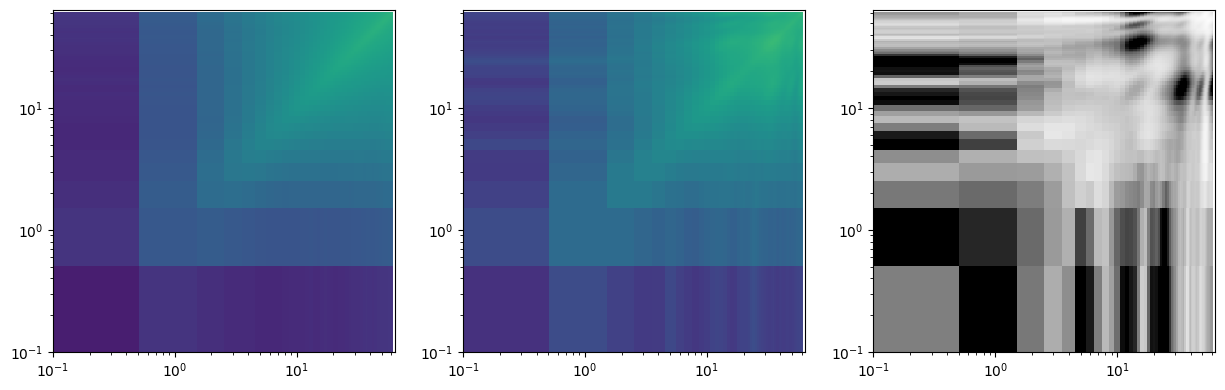

(p,q)= (4, 4)


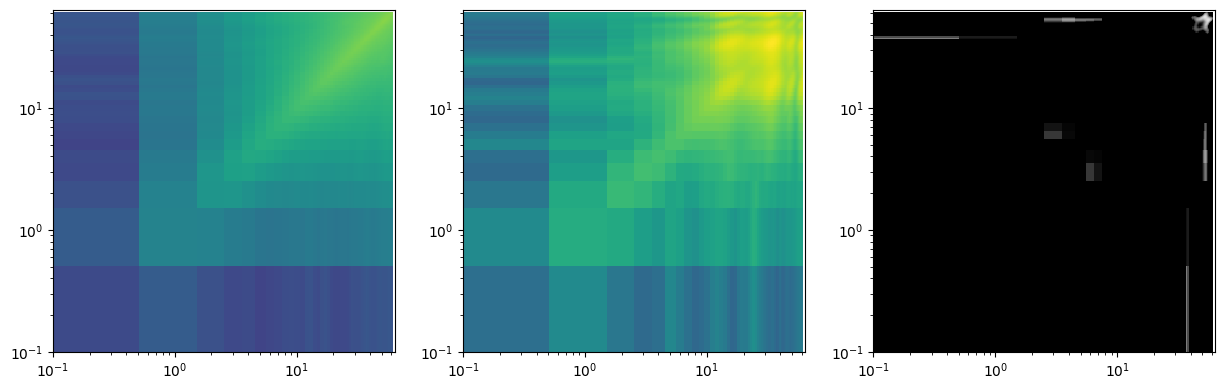

<Figure size 640x480 with 0 Axes>

In [26]:
def run_project_diagnostics(x_ref, results, experiments):
    """
    Uses the existing project plotting utilities. These functions usually create
    their own figures, so we call each diagnostic once per model and add titles.
    """
    diagnostic_functions = [
        ('Spectrum', spec_plot),
        ('Histogram', hist_plot),
        ('Structure functions', structure_plot),
    ]

    for diag_name, diag_fun in diagnostic_functions:
        print('' + '=' * 80)
        print(diag_name)
        print('=' * 80)
        for key, exp in experiments.items():
            print(exp['label'])
            diag_fun(x_ref, xt_cg)
            plt.suptitle(f"{diag_name}: {exp['label']}")
            plt.show()

    print('' + '=' * 80)
    print('Cross statistics')
    print('=' * 80)
    for key, exp in experiments.items():
        print(exp['label'])
        cross_plot(x_ref, xt_cg, pq=[(3, 1), (3, 3), (4, 4)])
        plt.suptitle(f"Cross statistics: {exp['label']}")
        plt.show()

run_project_diagnostics(x1_cg, results, experiments)


Marginal histograms


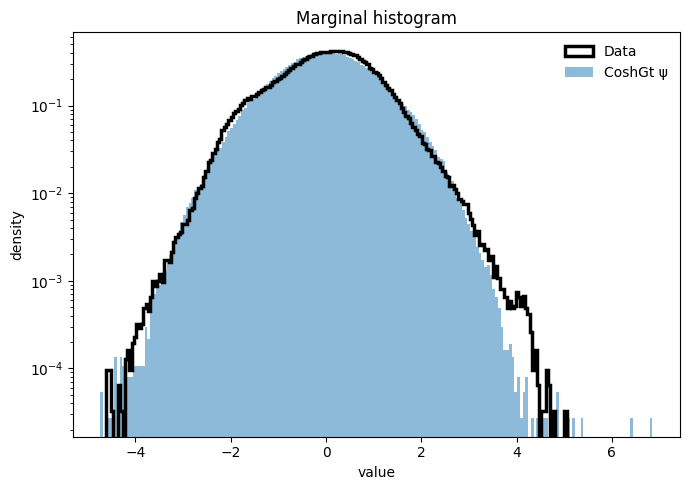

Per-band wavelet histograms  (one model at a time)


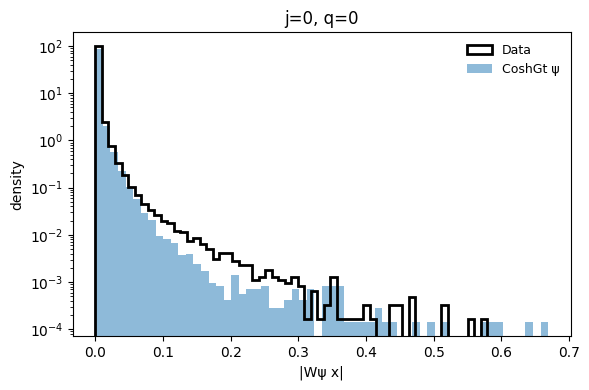

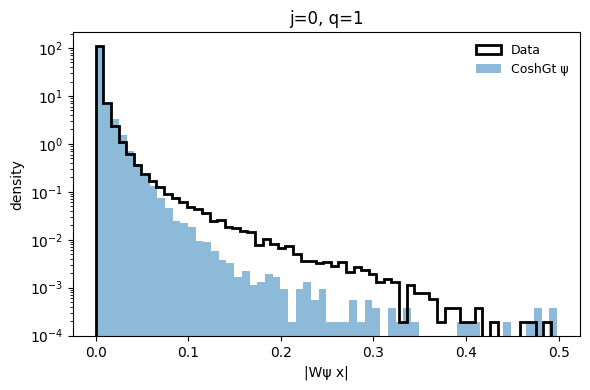

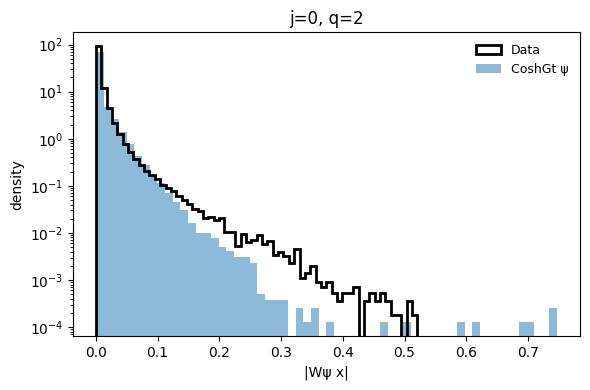

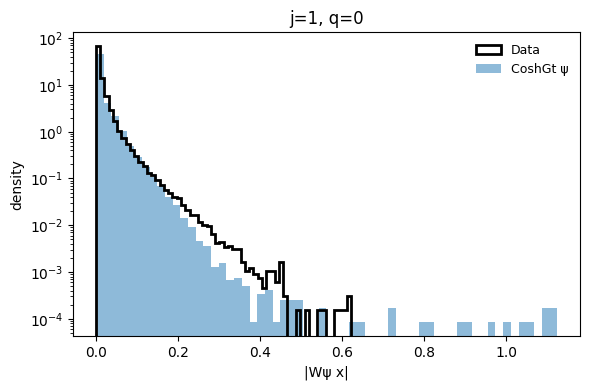

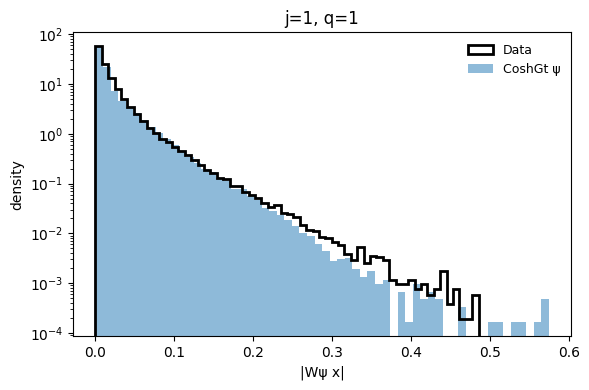

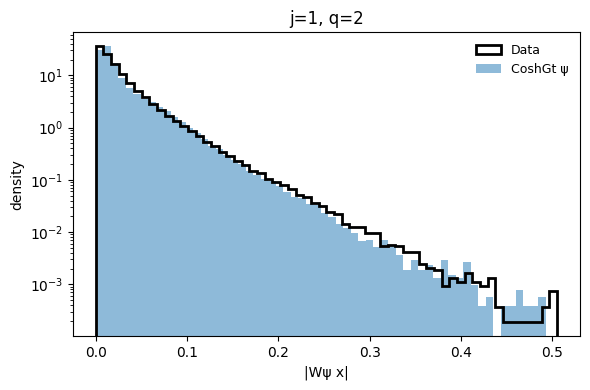

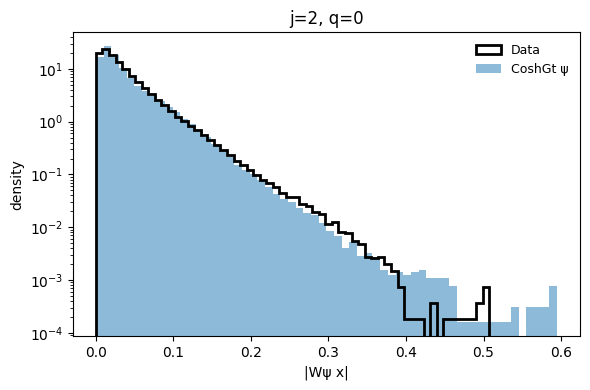

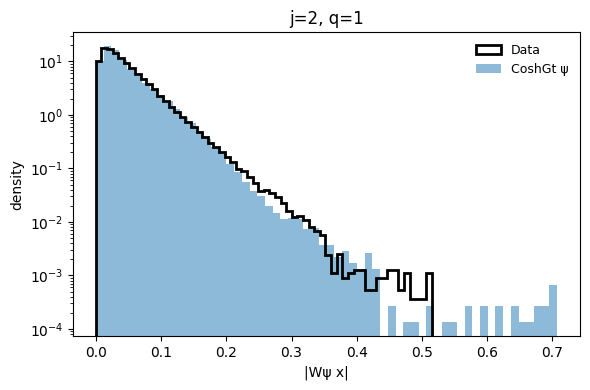

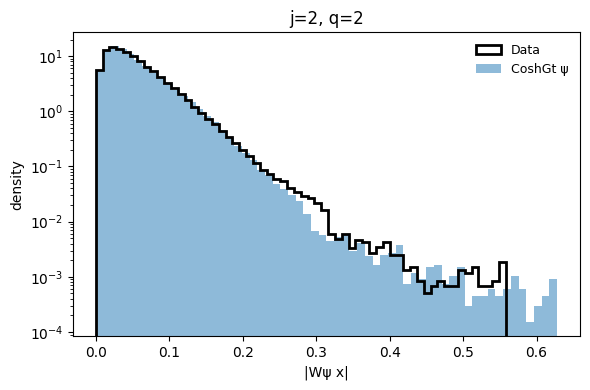

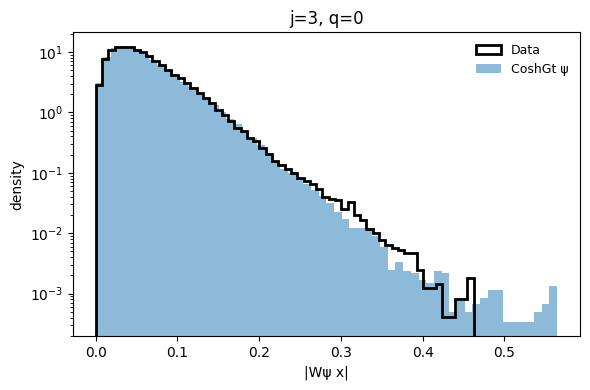

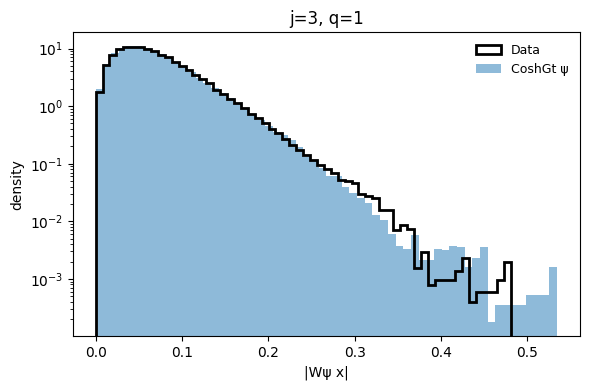

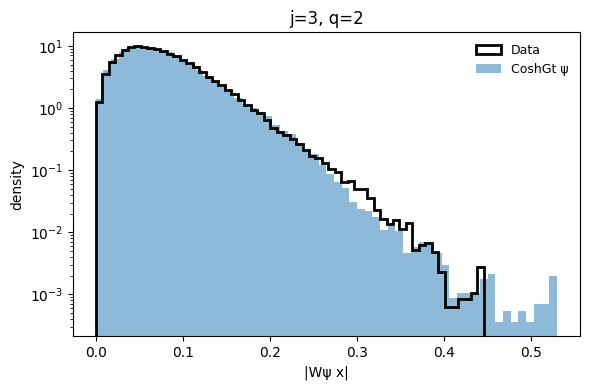

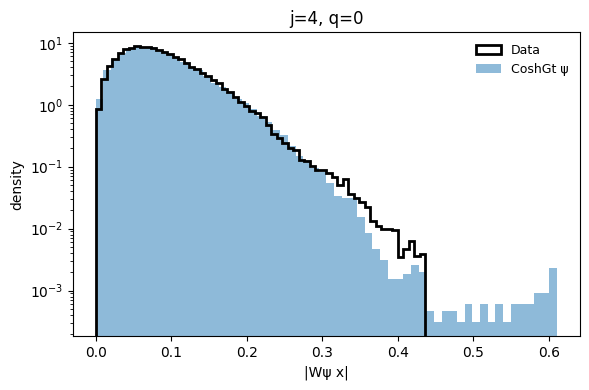

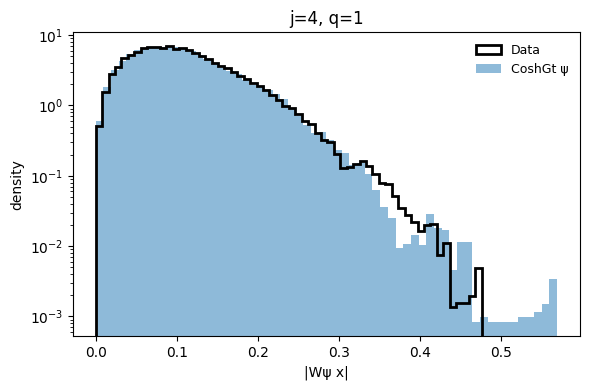

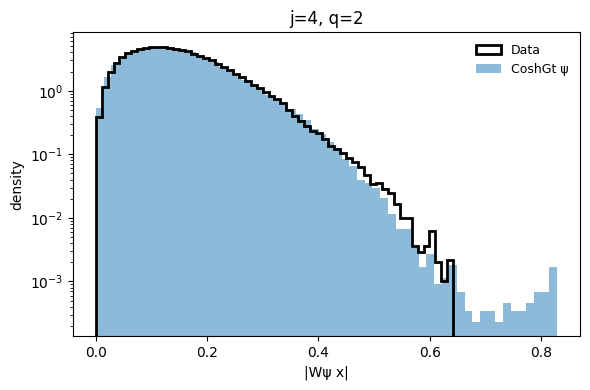

Visual comparison panels


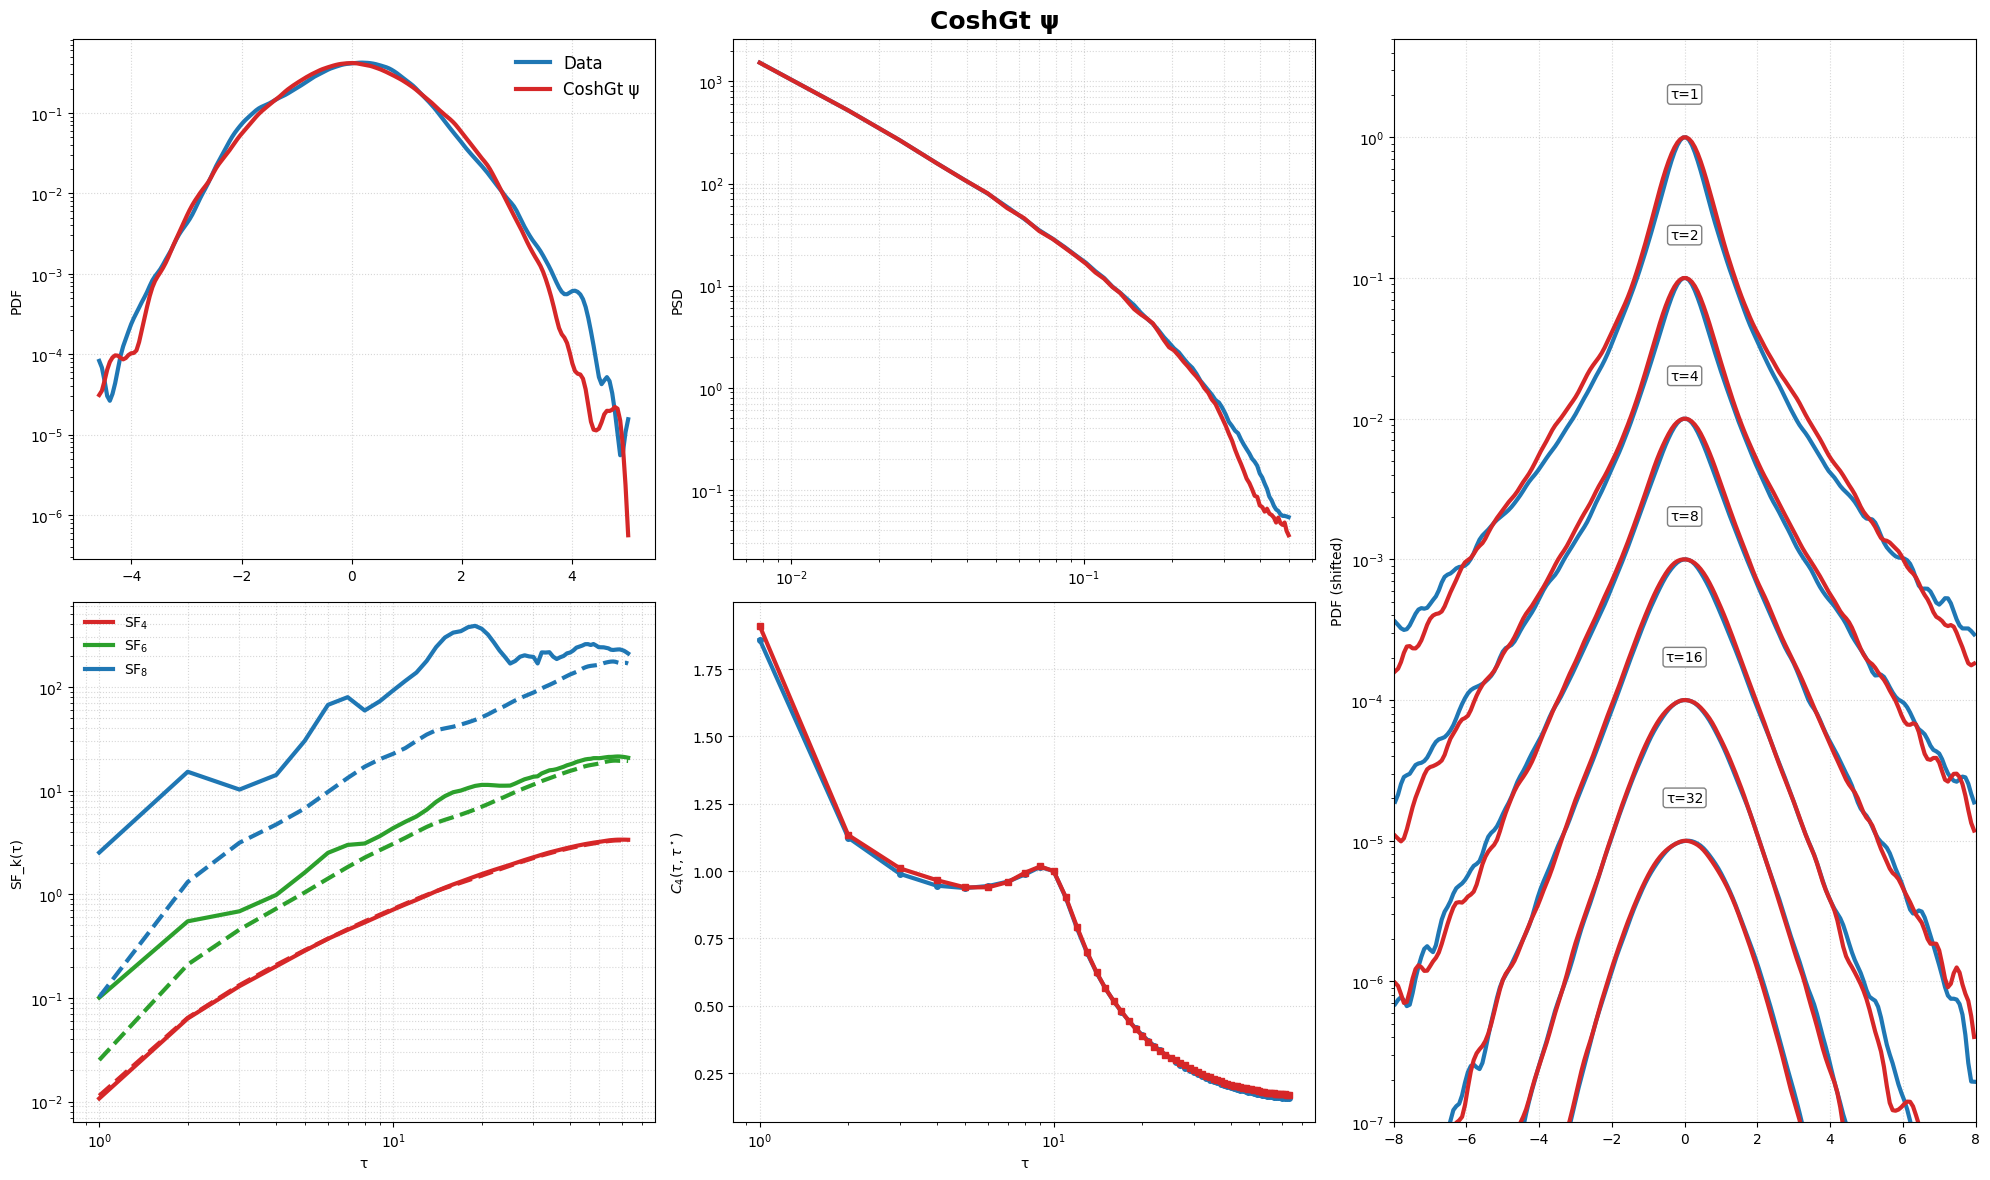

Scalar metrics
          mean_rel_error  std_rel_error  spectrum_rel_mse  wasserstein_mean  structure_rel_mse
CoshGt ψ   218930.015625       0.000654      1.194055e-07          0.042676           0.000296


,mean_rel_error,std_rel_error,spectrum_rel_mse,wasserstein_mean,structure_rel_mse
CoshGt ψ,218930.015625,0.000654,1.194055e-07,0.042676,0.000296


In [14]:
from diagnostics import * 
df = run_diagnostics(x1, results, experiments)
df  # displays the metrics table in Jupyter

## Quantitative comparison metrics

The following metrics are intentionally simple and independent from the plotting utilities:

- **Mean / std error:** relative mismatch of first two moments.
- **Spectrum relative MSE:** mismatch of the average Fourier power spectrum.
- **Histogram Wasserstein distance:** average 1D Wasserstein distance over channels.
- **Structure-function relative MSE:** mismatch of selected structure functions.


## Direct overlay plots for spectrum and structure functions

## Entropy bound comparison

## Project entropy plotting utility for each model